<a href="https://colab.research.google.com/github/INmais/PyPSA-Eur/blob/main/Copy_of_CEVE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [1]:
# 1. System-level dependencies first
!apt-get update -q
!apt-get install -y graphviz libgraphviz-dev pkg-config

# 2. Install Python packages
!pip install -q pygraphviz pydot diagrams networkx
!pip install -q pandapower["all"] scipy
!pip install -q plotly kaleido

# 3. Geospatial stack (Fiona/GDAL can be tricky)
# specific order helps resolve binary conflicts
!pip install -q fiona shapely pyproj rtree
!pip install -q geopandas contextily

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [83.6 kB]
Get:8 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,157 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,839 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-drivers/p

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
os.chdir("/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data")

In [5]:
# files in
!ls "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/DADOS SHAPE PT009"

'Apoio BT'	'Caixa de Visita'   'Posto de Transformacao'
'Braco IP'	'Coluna IP'	    'Rede PT009.dxf'
 Caixa_Armario	'Ponto de Entrega'  'Trocos BT_IP'


# new data excel

In [6]:
# files in
!ls "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/Dados PT_PTS09.zip (Unzipped Files)"

'Apoios BT.xlsx'	'Coluna IP.xlsx'
'Braco IP.xlsx'		'Ponto de Entrega de Energia_PEE.xlsx'
 Caixa_Armario.xlsx	'Posto de Transformacao_PT_PTS.xlsx'
'Caixa de Visita.xlsx'	'Troco BT PT09.xlsx'


In [7]:
import pandas as pd
import os

folder_path = "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/Dados PT_PTS09.zip (Unzipped Files)"

# 2. List of the Excel file names
file_names = [
    'Apoios BT.xlsx',
    'Coluna IP.xlsx',
    'Braco IP.xlsx',
    'Ponto de Entrega de Energia_PEE.xlsx',
    'Caixa_Armario.xlsx',
    'Posto de Transformacao_PT_PTS.xlsx',
    'Caixa de Visita.xlsx',
    'Troco BT PT09.xlsx'
]

# 3. Create a dictionary to hold the DataFrames
all_data = {}

print("--- Loading Excel Files ---")

# 4. Loop through the list, create the full path, and load each file
for file in file_names:
    # Create the full path by joining the folder path and the filename
    full_path = os.path.join(folder_path, file)

    try:
        key_name = os.path.splitext(file)[0]
        all_data[key_name] = pd.read_excel(full_path)
        print(f"✅ Successfully loaded '{file}'")

    except FileNotFoundError:
        # This error now means the file isn't even in that specific folder
        print(f"❌ ERROR: The file '{file}' was not found in the specified directory.")
    except Exception as e:
        print(f"❌ ERROR: Could not read '{file}'. Reason: {e}")

print("\n--- Loading Complete ---")

# Now you can access your data as before
if 'Apoios BT' in all_data:
    print("\nDisplaying first 5 rows of 'Apoios BT.xlsx':")
    print(all_data['Apoios BT'].head())

--- Loading Excel Files ---
✅ Successfully loaded 'Apoios BT.xlsx'
✅ Successfully loaded 'Coluna IP.xlsx'
✅ Successfully loaded 'Braco IP.xlsx'
✅ Successfully loaded 'Ponto de Entrega de Energia_PEE.xlsx'
✅ Successfully loaded 'Caixa_Armario.xlsx'
✅ Successfully loaded 'Posto de Transformacao_PT_PTS.xlsx'
✅ Successfully loaded 'Caixa de Visita.xlsx'
✅ Successfully loaded 'Troco BT PT09.xlsx'

--- Loading Complete ---

Displaying first 5 rows of 'Apoios BT.xlsx':
      Designação         Nº ID  Número de fabrico Ano de fabrico  \
0  9BP01-800-320  031223K90258                NaN           2003   
1  9BP00-400-220  031223K90260                NaN           2003   
2         8B-100  031223K90261                NaN           1981   
3         8B-100  031223K90262                NaN           1965   
4         8B-100  031223K90263                NaN           1965   

   Número do apoio   Tipo   Função  Altura                   Esforço à cabeça  \
0              NaN  Betão  BT e IP     9.0 

In [8]:
import pandas as pd
import geopandas
from shapely.geometry import Point, LineString
import os

# 1. Define the CRS
portugal_crs = 'EPSG:3763'

# 2. Create a new dictionary to hold your GeoDataFrames
all_geodata = {}

print("--- Processing each file with its own dedicated logic ---")

# 3. Loop through each file in your data
for name, df in all_data.items():
    try:
        # --- Logic for 'Apoios BT' ---
        if name == 'Apoios BT':
            geometry = geopandas.points_from_xy(df['X [m]/Long(º)'], df['Y [m]/Lat(º)'])
            gdf = geopandas.GeoDataFrame(df, geometry=geometry, crs=portugal_crs)
            all_geodata[name] = gdf
            print(f"✅ Processed '{name}' as POINTS.")

        # --- Logic for 'Coluna IP' ---
        elif name == 'Coluna IP':
            geometry = geopandas.points_from_xy(df['X [m]/Long(º)'], df['Y [m]/Lat(º)'])
            gdf = geopandas.GeoDataFrame(df, geometry=geometry, crs=portugal_crs)
            all_geodata[name] = gdf
            print(f"✅ Processed '{name}' as POINTS.")

        # --- Logic for 'Braco IP' ---
        elif name == 'Braco IP':
            geometry = geopandas.points_from_xy(df['X [m]/Long(º)'], df['Y [m]/Lat(º)'])
            gdf = geopandas.GeoDataFrame(df, geometry=geometry, crs=portugal_crs)
            all_geodata[name] = gdf
            print(f"✅ Processed '{name}' as POINTS.")

        # --- Logic for 'Ponto de Entrega de Energia_PEE' ---
        elif name == 'Ponto de Entrega de Energia_PEE':
            geometry = geopandas.points_from_xy(df['X [m]/Long(º)'], df['Y [m]/Lat(º)'])
            gdf = geopandas.GeoDataFrame(df, geometry=geometry, crs=portugal_crs)
            all_geodata[name] = gdf
            print(f"✅ Processed '{name}' as POINTS.")

        # --- Logic for 'Caixa_Armario' ---
        elif name == 'Caixa_Armario':
            geometry = geopandas.points_from_xy(df['X [m]/Long(º)'], df['Y [m]/Lat(º)'])
            gdf = geopandas.GeoDataFrame(df, geometry=geometry, crs=portugal_crs)
            all_geodata[name] = gdf
            print(f"✅ Processed '{name}' as POINTS.")

        # --- Logic for 'Posto de Transformacao_PT_PTS' ---
        elif name == 'Posto de Transformacao_PT_PTS':
            geometry = geopandas.points_from_xy(df['X [m]/Long(º)'], df['Y [m]/Lat(º)'])
            gdf = geopandas.GeoDataFrame(df, geometry=geometry, crs=portugal_crs)
            all_geodata[name] = gdf
            print(f"✅ Processed '{name}' as POINTS.")

        # --- Logic for 'Caixa de Visita' ---
        elif name == 'Caixa de Visita':
            geometry = geopandas.points_from_xy(df['X [m]/Long(º)'], df['Y [m]/Lat(º)'])
            gdf = geopandas.GeoDataFrame(df, geometry=geometry, crs=portugal_crs)
            all_geodata[name] = gdf
            print(f"✅ Processed '{name}' as POINTS.")

        # --- NEW LOGIC for 'Troco BT PT09' (Lines from Strings) ---
        elif name == 'Troco BT PT09':

            def create_line_from_strings(row):
                # 1. Get the coordinate strings from the row
                x_str = row['X [m]/Long(º)']
                y_str = row['Y [m]/Lat(º)']

                # Check for empty data
                if pd.isna(x_str) or pd.isna(y_str):
                    return None

                # 2. Split the strings by ';' and convert to numbers (floats)
                #    The 'if coord' part handles empty strings from trailing semicolons
                x_coords = [float(coord) for coord in x_str.split(';') if coord]
                y_coords = [float(coord) for coord in y_str.split(';') if coord]

                # 3. "Zip" the X and Y lists together to create pairs of (x, y) coordinates
                coordinates = list(zip(x_coords, y_coords))

                # 4. A line needs at least 2 points. If not, it's invalid.
                if len(coordinates) < 2:
                    return None

                # 5. Create the LineString geometry
                return LineString(coordinates)

            # Apply the function to every row to create the geometry
            geometry = df.apply(create_line_from_strings, axis=1)

            gdf = geopandas.GeoDataFrame(df, geometry=geometry, crs=portugal_crs)

            # Remove any rows where geometry could not be created
            gdf = gdf.dropna(subset=['geometry'])

            all_geodata[name] = gdf
            print(f"✅ Processed '{name}' as LINES from strings.")

        # --- Logic for any other file ---
        else:
            print(f"⚠️  Skipping '{name}': No logic defined for this file.")

    except Exception as e:
        print(f"❌ ERROR processing '{name}': {e}")

print("\n--- All files processed ---")

--- Processing each file with its own dedicated logic ---
✅ Processed 'Apoios BT' as POINTS.
✅ Processed 'Coluna IP' as POINTS.
✅ Processed 'Braco IP' as POINTS.
✅ Processed 'Ponto de Entrega de Energia_PEE' as POINTS.
✅ Processed 'Caixa_Armario' as POINTS.
✅ Processed 'Posto de Transformacao_PT_PTS' as POINTS.
✅ Processed 'Caixa de Visita' as POINTS.
✅ Processed 'Troco BT PT09' as LINES from strings.

--- All files processed ---


  Designação do cabo/condutor                  Tipo   Função  \
0               LXS 4x70 + 16         Aéreo apoiado  BT e IP   
1               LXS 4x70 + 16         Aéreo apoiado  BT e IP   
2                    VAV 4x10  Subterrâneo entubado       IP   
3               LXS 4x70 + 16         Aéreo apoiado  BT e IP   
4                    VV 4x2.5         Aéreo pousado       IP   

   Comprimento do sistema [m]  Comprimento real  [m] Número de fases  \
0                  198.599733                    NaN               3   
1                  387.923355                    NaN               3   
2                  339.281348                    NaN               3   
3                  631.822479                    NaN               3   
4                   24.611977                    NaN               3   

  Número de condutores por fase Número de condutores por neutro  \
0                             1                               1   
1                             1                 

<Axes: >

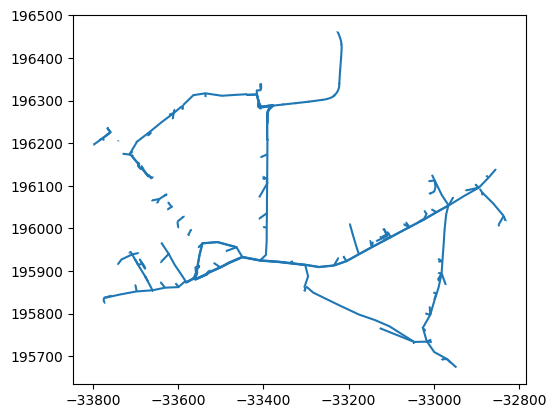

In [9]:
# Store the GeoDataFrame for 'Troco BT PT09' in a new variable
troco_bt_gdf = all_geodata['Troco BT PT09']
print(troco_bt_gdf.head())
troco_bt_gdf.plot()

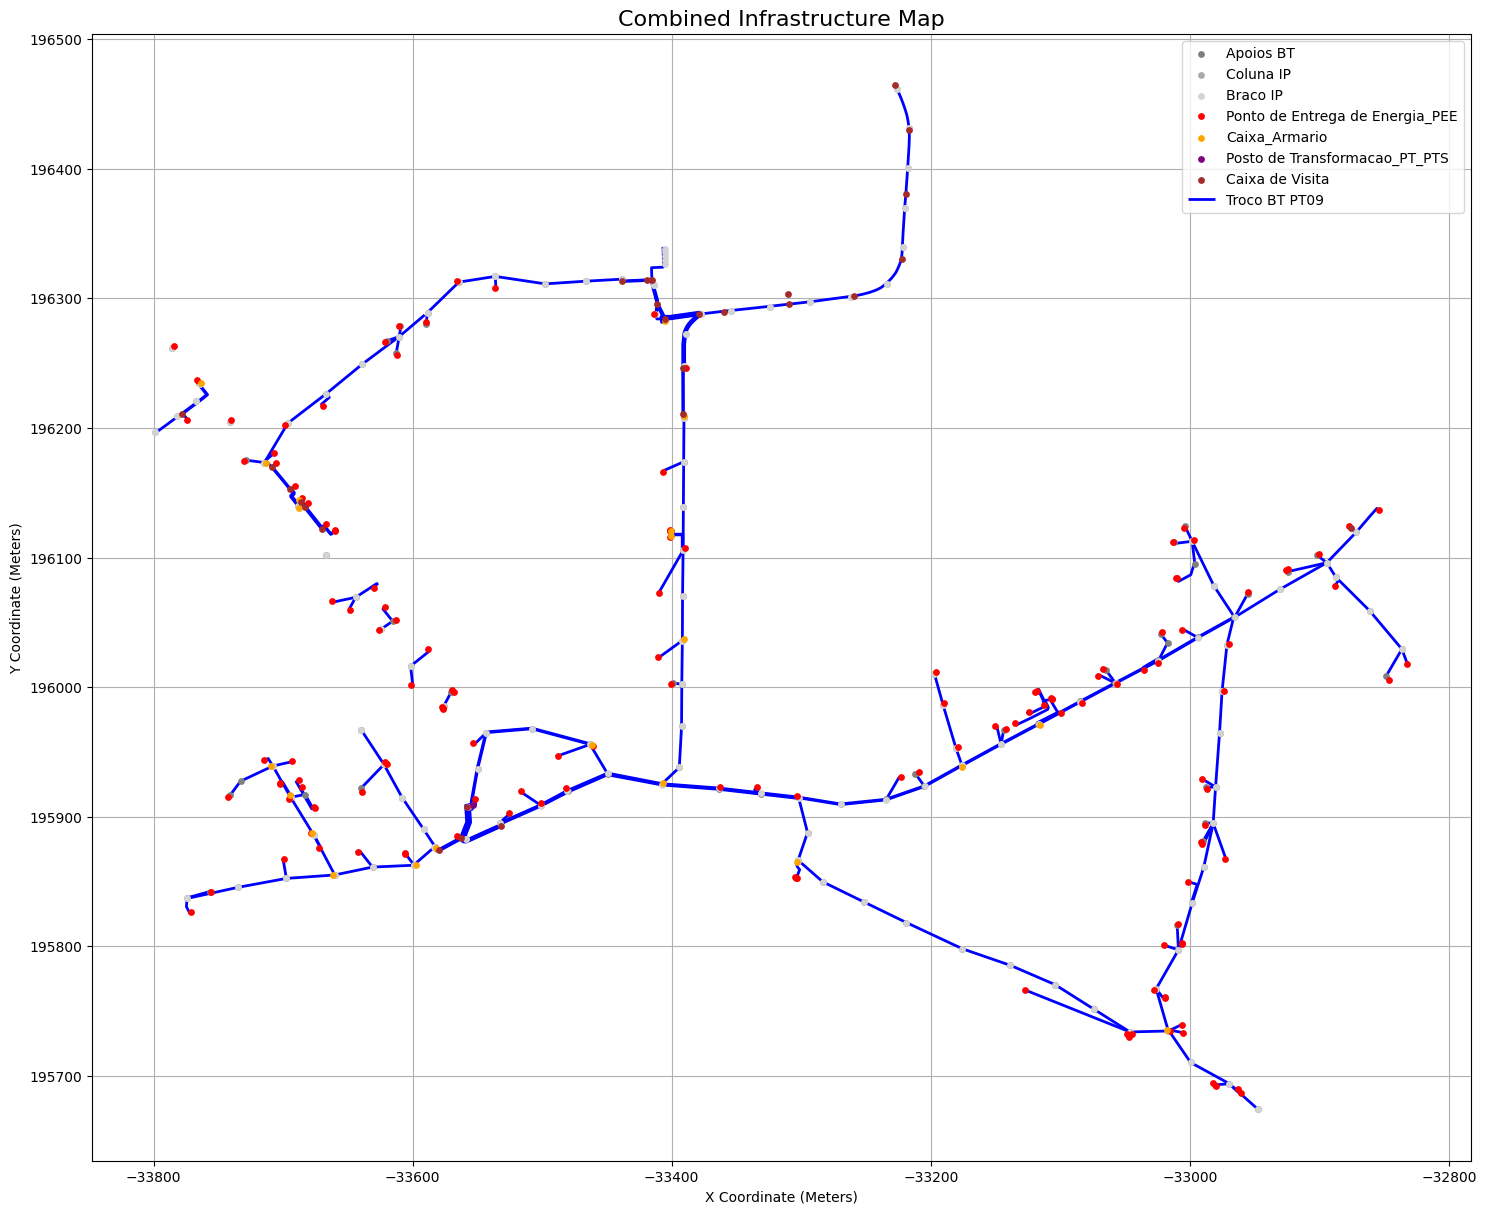

In [10]:
import geopandas
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# 2. Define colors for each layer
color_map = {
    'Apoios BT': 'gray',
    'Coluna IP': 'darkgray',
    'Braco IP': 'lightgray',
    'Ponto de Entrega de Energia_PEE': 'red',
    'Caixa_Armario': 'orange',
    'Posto de Transformacao_PT_PTS': 'purple',
    'Caixa de Visita': 'brown',
    'Troco BT PT09': 'blue'
}

#print("--- Plotting all layers onto a single map ---")

# 3. Loop through each GeoDataFrame to plot it
for name, gdf in all_geodata.items():
    # Use the color from our map, or a default color if not specified
    color = color_map.get(name, 'black')

    # Plot the layer on the pre-defined axes (ax)
    # We add a label for the legend
    if 'Point' in gdf.geom_type.unique():
        gdf.plot(ax=ax, color=color, label=name, markersize=15, zorder=3) # zorder brings points to the front
    else: # For lines
        gdf.plot(ax=ax, color=color, label=name, linewidth=2, zorder=2)

# 4. Customize and show the final map
ax.set_title('Combined Infrastructure Map', fontsize=16)
ax.set_xlabel('X Coordinate (Meters)')
ax.set_ylabel('Y Coordinate (Meters)')
ax.grid(True)
ax.legend() # Display the legend using the labels we provided

plt.tight_layout()
plt.show()

In [11]:
troco_bt_gdf['Designação do cabo/condutor'].unique()

array(['LXS 4x70 + 16', 'VAV 4x10', 'VV 4x2.5', 'VV 4x4', 'LXS 4x25+16',
       'XS 4x6', 'LXS 5x16', 'LXS 4x16', 'VAV 4x6', 'LXS 16',
       'LXS 4x95+16', 'LSVAV 4x95', 'LXS 4x70', 'VAV 3x16 + 10',
       'VAV 3x35+16', 'LXS 4x50', 'LXS 2x16', 'LXS 4x50 + 16', 'V 10',
       'LSVAV 4x50', 'VAV 4x16', 'VAV 3x25 + 16', 'LXS 4x25', 'VV 2x4',
       'XS 2x6', 'XV 4x6', 'XV 4x10', 'w_cabo-PEEs-NAV', 'XV 2x10'],
      dtype=object)

# Fixing missing line

In [12]:
import geopandas as gpd
import plotly.graph_objects as go
from shapely.geometry import Point, LineString

fig = go.Figure()

# 1. Define colors for each layer
color_map = {
    'Apoios BT': 'gray',
    'Coluna IP': 'darkgray',
    'Braco IP': 'lightgray',
    'Ponto de Entrega de Energia_PEE': 'red',
    'Caixa_Armario': 'orange',
    'Posto de Transformacao_PT_PTS': 'purple',
    'Caixa de Visita': 'brown',
    'Troco BT PT09': 'blue'
}

print("--- Creating interactive plot with Plotly ---")

# 2. Loop through each GeoDataFrame to create and add a Plotly "trace"
for name, gdf in all_geodata.items():
    if gdf.empty:
        continue

    color = color_map.get(name, 'black')

    # --- Logic for Line Geometries ---
    if any(gdf.geom_type.isin(['LineString', 'MultiLineString'])):
        all_x, all_y = [], []
        for geom in gdf.geometry:
            lines = [geom] if geom.geom_type == 'LineString' else geom.geoms
            for line in lines:
                x, y = line.xy
                all_x.extend(list(x))
                all_y.extend(list(y))
                all_x.append(None)
                all_y.append(None)

        fig.add_trace(go.Scatter(
            x=all_x,
            y=all_y,
            mode='lines',
            name=name,
            line=dict(color=color, width=3),
            hoverinfo='name'
        ))

    # --- Logic for Point Geometries ---
    elif any(gdf.geom_type.isin(['Point', 'MultiPoint'])):
        x_coords = [p.x for p in gdf.geometry]
        y_coords = [p.y for p in gdf.geometry]

        # Get labels for each point from the 'ID' column or the index
        if 'ID' in gdf.columns:
            labels = list(gdf['ID'])
        else:
            labels = list(gdf.index.astype(str))

        # --- custom hover text for each point ---
        hover_texts = [f"Layer: {name}<br>ID: {label}<br>Coords: ({x:.2f}, {y:.2f})" for label, x, y in zip(labels, x_coords, y_coords)]

        fig.add_trace(go.Scatter(
            x=x_coords,
            y=y_coords,
            mode='markers', # Display only markers, not permanent text
            name=name,
            marker=dict(color=color, size=10, symbol='circle'),
            hovertext=hover_texts, # Assign the custom hover texts
            hoverinfo='text' # Tell Plotly to display the 'hovertext' content
        ))

fig.update_layout(
    title_text='Combined Infrastructure Map (Interactive Viewer)',
    xaxis_title='X Coordinate (Meters)',
    yaxis_title='Y Coordinate (Meters)',
    legend_title_text='Layers',
    template='plotly_white',
    showlegend=True,
    yaxis_scaleanchor="x",
    yaxis_scaleratio=1
)


fig.show()

# fig.write_html("interactive_map.html")
# print("--- Interactive map saved to interactive_map.html ---")


--- Creating interactive plot with Plotly ---


apoios ip

ID
80
78
51
48
49
47
46
45
36
104
103

In [13]:
all_geodata['Apoios BT']

,Designação,Nº ID,Número de fabrico,Ano de fabrico,Número do apoio,Tipo,Função,Altura,Esforço à cabeça,Eléctrodo de terra,...,Situação,Observações,Data de entrada em serviço,id,X [m]/Long(º),Y [m]/Lat(º),Freguesia,Concelho,PT/PTS,geometry
0,9BP01-800-320,031223K90258,NaN,2003,NaN,Betão,BT e IP,9.0,800.000000000 / 320.000000000 / -,Não,...,Em exploração,NaN,unset,754987,-33438.181,196314.909,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33438.181 196314.909)
1,9BP00-400-220,031223K90260,NaN,2003,NaN,Betão,BT e IP,9.0,400.000000000 / 220.000000000 / -,Não,...,Em exploração,NaN,unset,754978,-33466.454,196313.327,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33466.454 196313.327)
2,8B-100,031223K90261,NaN,1981,NaN,Betão,BT e IP,8.0,100.000000000 / - / -,Não,...,Em exploração,NaN,unset,707719,-33497.621,196311.262,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33497.621 196311.262)
3,8B-100,031223K90262,NaN,1965,NaN,Betão,BT e IP,8.0,100.000000000 / - / -,Não,...,Em exploração,NaN,unset,754933,-33536.211,196317.033,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33536.211 196317.033)
4,8B-100,031223K90263,NaN,1965,NaN,Betão,BT e IP,8.0,100.000000000 / - / -,Não,...,Em exploração,NaN,unset,754924,-33564.345,196312.610,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33564.345 196312.61)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,8BP00-200-80,031226K90927,NaN,2016,NaN,Betão,BT ramal,8.0,200.000000000 / 80.0000000000 / -,Não,...,Em exploração,NaN,unset,6152497,-33143.732,195966.789,MOUQUIM,Vila Nova de Famalicão,031223D20009,POINT (-33143.732 195966.789)
126,8B-100,031223K90564,NaN,unset,NaN,Betão,BT ramal,8.0,100.000000000 / - / -,Não,...,Em exploração,|LEV:N/DISPONIVEL|,unset,1455817,-33639.935,195921.788,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33639.935 195921.788)
127,9BP00-400-220,031223K90565,NaN,2002,NaN,Betão,BT ramal,9.0,400.000000000 / 220.000000000 / -,Não,...,Em exploração,NaN,unset,712633,-33732.911,195927.280,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33732.911 195927.28)
128,9BF00-200-80,031223K90566,NaN,2002,NaN,Betão,BT ramal,9.0,200.000000000 / 80.0000000000 / -,Não,...,Em exploração,NaN,unset,712624,-33741.005,195916.341,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33741.005 195916.341)


In [14]:
positions_to_select = [
80,
78,
51,
48,
49,
47,
46,
45,
36,
104,
103]


# Create a new GeoDataFrame with only the selected rows
selected_apoios = all_geodata['Apoios BT'].iloc[positions_to_select].copy()

In [15]:
len(all_geodata['Apoios BT'])

130

In [16]:
selected_apoios

,Designação,Nº ID,Número de fabrico,Ano de fabrico,Número do apoio,Tipo,Função,Altura,Esforço à cabeça,Eléctrodo de terra,...,Situação,Observações,Data de entrada em serviço,id,X [m]/Long(º),Y [m]/Lat(º),Freguesia,Concelho,PT/PTS,geometry
80,9BF00-600-260,031223K90299,NaN,2001,NaN,Betão,BT e IP,9.0,600.000000000 / 260.000000000 / -,Não,...,Em exploração,NaN,unset,752557,-33542.996,195964.827,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33542.996 195964.827)
78,8B-100,031223K90297,NaN,1989,NaN,Betão,BT,8.0,100.000000000 / - / -,Não,...,Em exploração,NaN,unset,1452032,-33570.175,195996.331,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33570.175 195996.331)
51,9B-100,031223K90285,NaN,1985,NaN,Betão,BT e IP,9.0,100.000000000 / - / -,Não,...,Em exploração,NaN,unset,752548,-33601.574,196016.147,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33601.574 196016.147)
48,8B-100,031223K90282,NaN,1988,NaN,Betão,BT,8.0,100.000000000 / - / -,Não,...,Em exploração,NaN,unset,1452131,-33614.823,196051.285,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33614.823 196051.285)
49,8UB-200,031223K90283,NaN,1983,NaN,Betão,BT e IP,8.0,200.000000000 / - / -,Não,...,Em exploração,NaN,unset,752584,-33643.989,196069.269,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33643.989 196069.269)
47,9B-300,031223K90281,NaN,1987,NaN,Betão,BT e IP,9.0,300.000000000 / - / -,Não,...,Em exploração,NaN,unset,752593,-33666.832,196102.274,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33666.832 196102.274)
46,9B-300,031223K90280,NaN,1987,NaN,Betão,BT e IP,9.0,300.000000000 / - / -,Não,...,Em exploração,NaN,unset,752602,-33688.789,196139.731,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33688.789 196139.731)
45,9B-200,031223K90279,NaN,1997,NaN,Betão,BT e IP,9.0,200.000000000 / - / -,Não,...,Em exploração,NaN,unset,752629,-33714.459,196173.320,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33714.459 196173.32)
36,9B-100,031223K90268,NaN,1985,NaN,Betão,BT e IP,9.0,100.000000000 / - / -,Não,...,Em exploração,NaN,unset,752638,-33740.837,196204.592,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33740.837 196204.592)
104,9B-100,031223K90431,NaN,1985,NaN,Betão,BT e IP,9.0,100.000000000 / - / -,Não,...,Em exploração,NaN,unset,752647,-33765.233,196235.079,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33765.233 196235.079)


In [17]:
from shapely.geometry import LineString

# Extract the Point objects from the geometry column
points_list = selected_apoios['geometry'].tolist()

# Create a LineString geometry from the list of points
new_line = LineString(points_list)

print("New LineString created:")
print(new_line)

New LineString created:
LINESTRING (-33542.996 195964.827, -33570.175 195996.331, -33601.574 196016.147, -33614.823 196051.285, -33643.989 196069.269, -33666.832 196102.274, -33688.789 196139.731, -33714.459 196173.32, -33740.837 196204.592, -33765.233 196235.079, -33785.962 196261.573)


In [18]:
import pandas as pd
import geopandas as gpd
import numpy as np

new_row_data = {'geometry': new_line}

for col in troco_bt_gdf.columns:
    if col != 'geometry':
        new_row_data[col] = None


new_line_gdf = gpd.GeoDataFrame([new_row_data], crs=troco_bt_gdf.crs)

troco_bt_gdf_updated = pd.concat([troco_bt_gdf, new_line_gdf], ignore_index=True)

print("Última linha do GeoDataFrame atualizado:")
print(troco_bt_gdf_updated.tail(1))

Última linha do GeoDataFrame atualizado:
    Designação do cabo/condutor  Tipo Função  Comprimento do sistema [m]  \
257                        None  None   None                         NaN   

     Comprimento real  [m] Número de fases Número de condutores por fase  \
257                    NaN            None                          None   

    Número de condutores por neutro Situação Fabricante  ...  \
257                            None     None       None  ...   

     Circuito Powerline Anotacao Esquema Unifilar Bts Origem    id  \
257                None                          None   None  None   

    X [m]/Long(º) Y [m]/Lat(º) Freguesia Concelho PT/PTS  \
257          None         None      None     None   None   

                                              geometry  
257  LINESTRING (-33542.996 195964.827, -33570.175 ...  

[1 rows x 30 columns]


/tmp/ipython-input-1403437842.py:14: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [19]:

idx = troco_bt_gdf_updated.index[-1]

# se ainda tens a variável new_line:
length_m = new_line.length
# (ou, se preferires, ler da própria linha)
# length_m = troco_bt_gdf_updated.loc[idx, "geometry"].length

troco_bt_gdf_updated.loc[idx, "Designação do cabo/condutor"] = "LSVAV 4x95"
troco_bt_gdf_updated.loc[idx, "Tipo"] = "Subterrâneo"
troco_bt_gdf_updated.loc[idx, "Função"] = "BT rede"          # ou "BT ramal"

troco_bt_gdf_updated.loc[idx, "Comprimento do sistema [m]"] = length_m
troco_bt_gdf_updated.loc[idx, "Comprimento real  [m]"] = length_m

troco_bt_gdf_updated.loc[idx, "Número de fases"] = 3
troco_bt_gdf_updated.loc[idx, "Número de condutores por fase"] = 1
troco_bt_gdf_updated.loc[idx, "Número de condutores por neutro"] = 1

troco_bt_gdf_updated.loc[idx, "Situação"] = "Em exploração"

print(troco_bt_gdf_updated.tail(1))


    Designação do cabo/condutor         Tipo   Função  \
257                  LSVAV 4x95  Subterrâneo  BT rede   

     Comprimento do sistema [m]  Comprimento real  [m] Número de fases  \
257                  389.983842             389.983842               3   

    Número de condutores por fase Número de condutores por neutro  \
257                             1                               1   

          Situação Fabricante  ...  Circuito Powerline  \
257  Em exploração       None  ...                None   

    Anotacao Esquema Unifilar Bts Origem    id X [m]/Long(º) Y [m]/Lat(º)  \
257                          None   None  None          None         None   

    Freguesia Concelho PT/PTS  \
257      None     None   None   

                                              geometry  
257  LINESTRING (-33542.996 195964.827, -33570.175 ...  

[1 rows x 30 columns]


In [20]:
troco_bt_gdf_updated.tail(1)

,Designação do cabo/condutor,Tipo,Função,Comprimento do sistema [m],Comprimento real [m],Número de fases,Número de condutores por fase,Número de condutores por neutro,Situação,Fabricante,...,Circuito Powerline,Anotacao Esquema Unifilar Bts,Origem,id,X [m]/Long(º),Y [m]/Lat(º),Freguesia,Concelho,PT/PTS,geometry
257,LSVAV 4x95,Subterrâneo,BT rede,389.983842,389.983842,3,1,1,Em exploração,None,...,None,None,None,None,None,None,None,None,None,"LINESTRING (-33542.996 195964.827, -33570.175 ..."


In [21]:
print(all_geodata['Troco BT PT09'].crs)


EPSG:3763


In [22]:
import pandas as pd
import geopandas as gpd
import numpy as np


target_gdf = all_geodata['Troco BT PT09']


new_row_data = {'geometry': new_line}


for col in target_gdf.columns:
    if col != 'geometry':
        new_row_data[col] = None

new_line_gdf = gpd.GeoDataFrame([new_row_data], crs=target_gdf.crs)

all_geodata['Troco BT PT09'] = pd.concat(
    [target_gdf, new_line_gdf],
    ignore_index=True
)

print("Nova linha integrada em 'all_geodata['Troco BT PT09']'.")
print("Última linha do GeoDataFrame atualizado:")
print(all_geodata['Troco BT PT09'].tail(1))

Nova linha integrada em 'all_geodata['Troco BT PT09']'.
Última linha do GeoDataFrame atualizado:
    Designação do cabo/condutor  Tipo Função  Comprimento do sistema [m]  \
257                        None  None   None                         NaN   

     Comprimento real  [m] Número de fases Número de condutores por fase  \
257                    NaN            None                          None   

    Número de condutores por neutro Situação Fabricante  ...  \
257                            None     None       None  ...   

     Circuito Powerline Anotacao Esquema Unifilar Bts Origem    id  \
257                None                          None   None  None   

    X [m]/Long(º) Y [m]/Lat(º) Freguesia Concelho PT/PTS  \
257          None         None      None     None   None   

                                              geometry  
257  LINESTRING (-33542.996 195964.827, -33570.175 ...  

[1 rows x 30 columns]


/tmp/ipython-input-3111987149.py:18: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



In [23]:
# The GeoDataFrame you want to save
gdf_to_save = all_geodata['Troco BT PT09']

# Save to a GeoPackage file by changing the filename and driver
gdf_to_save.to_file("troco_bt_pt09_corrected.gpkg", driver="GPKG")

print("GeoDataFrame saved as a GeoPackage file.")

GeoDataFrame saved as a GeoPackage file.


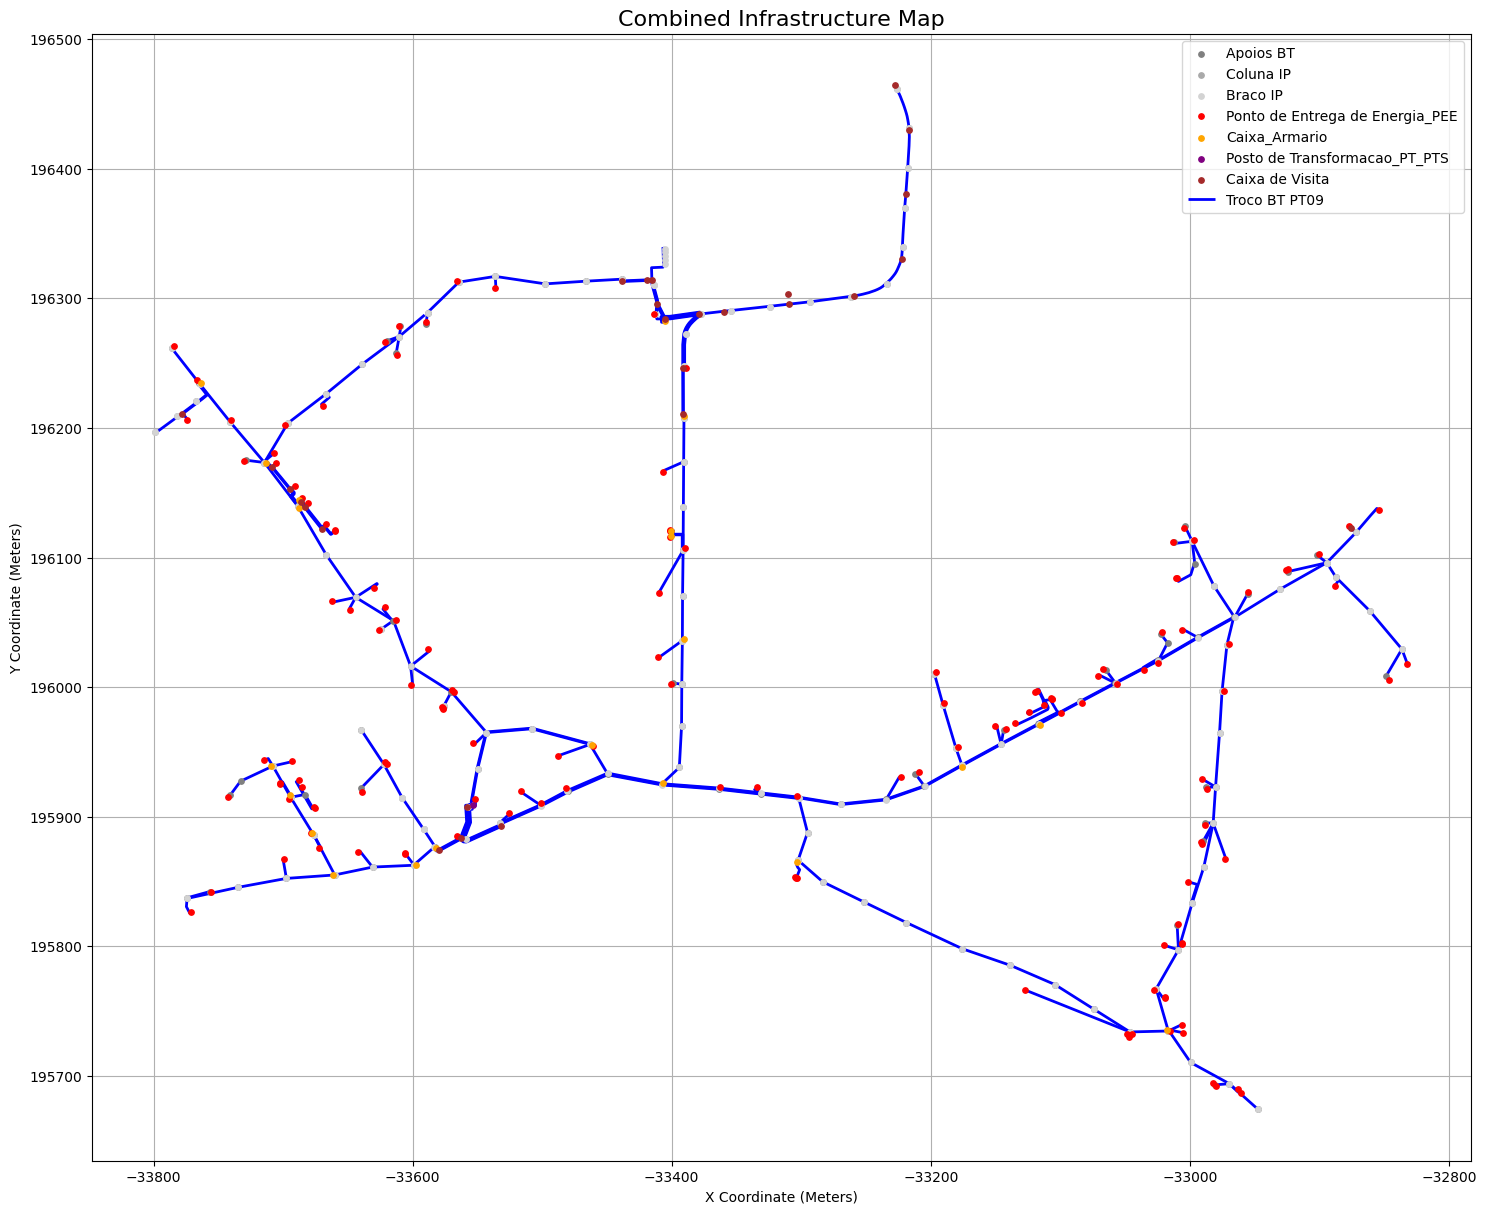

In [24]:
import geopandas
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 1, figsize=(15, 15))


color_map = {
    'Apoios BT': 'gray',
    'Coluna IP': 'darkgray',
    'Braco IP': 'lightgray',
    'Ponto de Entrega de Energia_PEE': 'red',
    'Caixa_Armario': 'orange',
    'Posto de Transformacao_PT_PTS': 'purple',
    'Caixa de Visita': 'brown',
    'Troco BT PT09': 'blue'
}

#print("--- Plotting all layers onto a single map ---")

for name, gdf in all_geodata.items():
    color = color_map.get(name, 'black')

    if 'Point' in gdf.geom_type.unique():
        gdf.plot(ax=ax, color=color, label=name, markersize=15, zorder=3) # zorder brings points to the front
    else: # For lines
        gdf.plot(ax=ax, color=color, label=name, linewidth=2, zorder=2)

ax.set_title('Combined Infrastructure Map', fontsize=16)
ax.set_xlabel('X Coordinate (Meters)')
ax.set_ylabel('Y Coordinate (Meters)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


In [25]:
import geopandas as gpd
import plotly.graph_objects as go
import pandas as pd

# --- 1. Use the same color map ---
color_map = {
    'Apoios BT': 'gray',
    'Coluna IP': 'darkgray',
    'Braco IP': 'lightgray',
    'Ponto de Entrega de Energia_PEE': 'red',
    'Caixa_Armario': 'orange',
    'Posto de Transformacao_PT_PTS': 'purple',
    'Caixa de Visita': 'brown',
    'Troco BT PT09': 'blue'
}

# --- 2. Create an empty Plotly figure ---
fig = go.Figure()

# --- 3. Loop through layers and add them as "traces" ---
all_lons = []
all_lats = []

for name, gdf in all_geodata.items():
    if gdf.empty or 'LineString' not in gdf.geom_type.unique():
        continue

    color = color_map.get(name, 'black')
    gdf_4326 = gdf.to_crs("EPSG:4326")


    lons, lats, hover_texts = [], [], []

    for index, row in gdf_4326.iterrows():

        label_for_this_line = name
        if name == 'Troco BT PT09':
            if 'id' in row and pd.notna(row['id']):
                label_for_this_line = f"Troço ID: {row['id']}"
            else:
                label_for_this_line = 'Troço BT (ID não disponível)'


        line = row.geometry
        x, y = line.xy

        lons.extend(list(x))
        lats.extend(list(y))

        hover_texts.extend([label_for_this_line] * len(x))

        lons.append(None)
        lats.append(None)
        hover_texts.append(None)

    all_lons.extend(lons)
    all_lats.extend(lats)

    fig.add_trace(go.Scattermap(
        lat=lats,
        lon=lons,
        mode='lines',
        line=dict(width=2.5, color=color),
        name=name,
        hoverinfo='text',
        hovertext=hover_texts
    ))


for name, gdf in all_geodata.items():
    if gdf.empty or 'Point' not in gdf.geom_type.unique():
        continue

    color = color_map.get(name, 'black')
    gdf_4326 = gdf.to_crs("EPSG:4326")

    hover_label = name
    if 'Id' in gdf_4326.columns:
        hover_label = "ID: " + gdf_4326['Id'].astype(str)
    elif 'Código da instalação' in gdf_4326.columns:
        hover_label = "Código: " + gdf_4326['Código da instalação'].astype(str)
    elif 'Nº ID' in gdf_4326.columns:
        hover_label = "Nº ID: " + gdf_4326['Nº ID'].astype(str)

    all_lons.extend(gdf_4326.geometry.x)
    all_lats.extend(gdf_4326.geometry.y)

    fig.add_trace(go.Scattermap(
        lat=gdf_4326.geometry.y,
        lon=gdf_4326.geometry.x,
        mode='markers',
        marker=dict(size=9, color=color),
        name=name,
        hoverinfo='text',
        hovertext=hover_label
    ))

# --- 4. Customize the map layout ---
center_lat = pd.Series(all_lats).mean()
center_lon = pd.Series(all_lons).mean()

fig.update_layout(
    title='Combined Infrastructure Interactive Map',
    map_style="open-street-map",
    map=dict(
        center=go.layout.map.Center(
            lat=center_lat,
            lon=center_lon
        ),
        zoom=16
    ),
    legend_title_text='Layers',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    margin={"r":0,"t":40,"l":0,"b":0}
)

# --- 5. Show the interactive map ---
fig.show()

--- Gerando mapa interativo Plotly com etiquetas nas linhas ---


In [26]:
#lines
1451923

2450710

1452455


#444453

##Fixes
#connect 1455034 to 1455152
#connect 1451863 to 1452747

#connec PT to
# 5937175 (LXS 2x16)
#1451863 (LXS 4x70 + 16), 474274 (LXS 4x70 + 16)
#591194 (VAV 4x10), 526478 (LSVAV 4x95), 591185 (VAV 4x10)
#591203 (VAV 4x10),526514 (LSVAV 4x95),526469 (LSVAV 4x95), 526505 (LSVAV 4x95)

1452455

In [27]:
all_geodata['Ponto de Entrega de Energia_PEE']
#use "id"

,Designação,Tipo,Número de clientes alimentados,Gerador de emergência,Microprodução?,Situação,Data de entrada em serviço,Observações,Tensão de Serviço,Blocos,...,Id,Produtor Central,Subestacao Cliente,Subestacao Cliente.1,X [m]/Long(º),Y [m]/Lat(º),Freguesia,Concelho,PT/PTS,geometry
0,NaN,Contador,unset,Não,unset,Em exploração,unset,009-048,BT,(1),...,1251855,NaN,NaN,unset,-33536.176,196308.309,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33536.176 196308.309)
1,NaN,Contador,unset,Não,unset,Em exploração,unset,009-047,BT,(1),...,1251862,NaN,NaN,unset,-33565.752,196313.506,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33565.752 196313.506)
2,NaN,Contador,unset,Não,unset,Em exploração,unset,009-126,BT,(1),...,1251344,NaN,NaN,unset,-32832.221,196017.767,MOUQUIM,Vila Nova de Famalicão,031223D20009,POINT (-32832.221 196017.767)
3,NaN,Contador,unset,Não,unset,Em exploração,unset,009-161,BT,(1),...,1455173,NaN,NaN,unset,-32846.090,196005.625,MOUQUIM,Vila Nova de Famalicão,031223D20009,POINT (-32846.09 196005.625)
4,NaN,Contador,unset,Não,unset,Em exploração,unset,009-163,BT,(1),...,1251162,NaN,NaN,unset,-33004.793,196122.439,MOUQUIM,Vila Nova de Famalicão,031223D20009,POINT (-33004.793 196122.439)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,NaN,Contador,unset,Não,unset,Em exploração,unset,009-038,BT,(1),...,1251904,NaN,NaN,unset,-33784.403,196263.124,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33784.403 196263.124)
141,NaN,Contador,unset,Não,unset,Em exploração,unset,009-174,BT,(1),...,5535042,NaN,NaN,unset,-33766.512,196237.046,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33766.512 196237.046)
142,NaN,Contador,unset,Não,unset,Em exploração,unset,009-162,BT,(1),...,1238450,NaN,NaN,unset,-33773.907,196206.399,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33773.907 196206.399)
143,NaN,Contador,unset,Não,unset,Em exploração,unset,009-079,BT,(1),...,1251631,NaN,NaN,unset,-33756.053,195841.888,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33756.053 195841.888)


In [28]:
all_geodata['Troco BT PT09'] # by id

,Designação do cabo/condutor,Tipo,Função,Comprimento do sistema [m],Comprimento real [m],Número de fases,Número de condutores por fase,Número de condutores por neutro,Situação,Fabricante,...,Circuito Powerline,Anotacao Esquema Unifilar Bts,Origem,id,X [m]/Long(º),Y [m]/Lat(º),Freguesia,Concelho,PT/PTS,geometry
0,LXS 4x70 + 16,Aéreo apoiado,BT e IP,198.599733,NaN,3,1,1,Em exploração,NaN,...,unset,NaN,SIT,1455669,-33583.1700000;-33599.3440000;-33630.9910000;-...,195876.499000;195862.397000;195860.993000;1958...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33583.17 195876.499, -33599.344 1..."
1,LXS 4x70 + 16,Aéreo apoiado,BT e IP,387.923355,NaN,3,1,1,Em exploração,NaN,...,unset,NaN,SIT,444462,-33204.7420000;-33175.6410000;-33145.6370000;-...,195923.235000;195939.463000;195955.807000;1959...,MOUQUIM,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33204.742 195923.235, -33175.641 ..."
2,VAV 4x10,Subterrâneo entubado,IP,339.281348,NaN,3,1,1,Em exploração,NaN,...,unset,NaN,SIT,1455416,-33405.8640000;-33405.8590000;-33405.8520000;-...,196282.902000;196283.402000;196284.287000;1962...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33405.864 196282.902, -33405.859 ..."
3,LXS 4x70 + 16,Aéreo apoiado,BT e IP,631.822479,NaN,3,1,1,Em exploração,NaN,...,unset,NaN,SIT,444480,-33046.1850000;-33016.5940000;-33025.9540000;-...,195733.697000;195734.437000;195767.018000;1957...,MOUQUIM,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33046.185 195733.697, -33016.594 ..."
4,VV 4x2.5,Aéreo pousado,IP,24.611977,NaN,3,1,1,Em exploração,NaN,...,unset,NaN,SIT,1455581,-33404.8850000;-33405.1440000;-33406.3590000;-...,196326.650000;196326.900000;196326.900000;1963...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33404.885 196326.65, -33405.144 1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,XS 4x6,Aéreo apoiado,BT ramal,2.694849,NaN,1,1,1,Em exploração,NaN,...,unset,NaN,SIT,6075194,-33764.4140000;-33765.8880000;,196234.056000;196236.312000;,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33764.414 196234.056, -33765.888 ..."
254,XV 4x6,Aéreo apoiado,BT ramal,0.963396,NaN,1,1,1,Em exploração,NaN,...,unset,NaN,SIT,6075221,-33766.5120000;-33765.8880000;,196237.046000;196236.312000;,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33766.512 196237.046, -33765.888 ..."
255,XS 4x6,Aéreo tendido,BT ramal,19.055180,NaN,3,1,1,Em exploração,NaN,...,unset,NaN,SIT,1456273,-33774.1710000;-33773.7890000;-33757.5530000;-...,195836.746000;195837.341000;195841.838000;1958...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33774.171 195836.746, -33773.789 ..."
256,XS 4x6,Aéreo tendido,BT ramal,12.843091,NaN,3,1,1,Em exploração,NaN,...,unset,NaN,SIT,1456262,-33774.1710000;-33774.6880000;-33772.1630000;-...,195836.746000;195830.427000;195825.538000;1958...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33774.171 195836.746, -33774.688 ..."


In [29]:
#lines
1451923
2450710
1452455

##Fixes
#connect 1455034 (LXS 5x16) to 1455152 (LXS 5x16)
#connect 1451863 (LXS 4x70 + 16) to 1452747 (LSVAV 4x95)

#connec PT to
# 5937175 (LXS 2x16)
#1451863 (LXS 4x70 + 16), 474274 (LXS 4x70 + 16)
#591194 (VAV 4x10), 526478 (LSVAV 4x95), 591185 (VAV 4x10)
#591203 (VAV 4x10),526514 (LSVAV 4x95),526469 (LSVAV 4x95), 526505 (LSVAV 4x95)

1452455

In [30]:
all_geodata['Troco BT PT09'].columns

Index(['Designação do cabo/condutor', 'Tipo', 'Função',
       'Comprimento do sistema [m]', 'Comprimento real  [m]',
       'Número de fases', 'Número de condutores por fase',
       'Número de condutores por neutro', 'Situação', 'Fabricante',
       'Lote de fabrico', 'Data de entrada em serviço', 'Observações', 'Valas',
       'Troços BT no Corte', 'Anotações', 'Linha de chamada do troço BT',
       'Identificação do Circuito', 'Circuito', 'Circuito IP',
       'Circuito Powerline', 'Anotacao Esquema Unifilar Bts', 'Origem', 'id',
       'X [m]/Long(º)', 'Y [m]/Lat(º)', 'Freguesia', 'Concelho', 'PT/PTS',
       'geometry'],
      dtype='object')

In [31]:
all_geodata['Posto de Transformacao_PT_PTS']

,Código da instalação,Nomenclatura/Designação,Tipo de instalação,Potência instalada [kVA],Tensão de serviço,Tensão nominal [kV],Acesso à instalação,Observações,Número de transformadores,Ponta máx. assíncrona n-1 [kW],...,Unidades de Alimentação Ininterrupta,Índice da Zona de Qualidade de Serviço,User Join Aspect,Área Servida [m2],X [m]/Long(º),Y [m]/Lat(º),Freguesia,Concelho,PT/PTS,geometry
0,031223D20009,Louro - Gandra,Posto de transformação,250,15 kV,NaN,NaN,NaN,1,unset,...,NaN,unset,031223D20009,689824.649234,-33553.413,195909.098,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33553.413 195909.098)


In [32]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString
from shapely.ops import nearest_points

##Fixes
#connect 1455034 (LXS 5x16) to 1455152 (LXS 5x16)
#connect 1451863 (LXS 4x70 + 16) to 1452747 (LSVAV 4x95)

#connec PT to
# 5937175 (LXS 2x16)
#1451863 (LXS 4x70 + 16), 474274 (LXS 4x70 + 16)
#591194 (VAV 4x10), 526478 (LSVAV 4x95), 591185 (VAV 4x10)
#591203 (VAV 4x10),526514 (LSVAV 4x95),526469 (LSVAV 4x95), 526505 (LSVAV 4x95)

# --- 1. CONFIGURATION ---

id_column = 'id'

try:
    pt_layer = all_geodata['Posto de Transformacao_PT_PTS']
    bt_layer = all_geodata['Troco BT PT09']
except KeyError:
    print("Error: Could not find the required layers in 'all_geodata'.")
    print("Make sure 'Posto de Transformacao_PT_PTS' and 'Troco BT PT09' exist.")
    # Stop execution if layers aren't found
    raise

# --- 3. DEFINE CONNECTIONS TO BE MADE ---

# Task 1: Connect specific lines to other lines
line_to_line_pairs = [
    (1455034,1455152),
    (1451863,1452747)
]

# Task 2: Connect the PT to a list of specific lines
pt_to_line_ids = [
    5937175,
    1451863, 474274,
    591194, 526478, 591185,
    591203, 526514, 526469, 526505,
]

# This list will store all the new LineString geometries we create
new_connector_geometries = []

# --- 4. PROCESS THE CONNECTIONS ---

# Get the single Point geometry for the PT
try:
    pt_geom = pt_layer.geometry.iloc[0]
except IndexError:
    print("Error: The 'Posto de Transformacao_PT_PTS' layer is empty. Cannot proceed.")
    raise

# --- Task 1: Line-to-Line Connections ---
print("Processing Line-to-Line connections...")
for id_a, id_b in line_to_line_pairs:
    try:
        # Get the geometries for both lines
        geom_a = bt_layer.loc[bt_layer[id_column] == id_a, 'geometry'].iloc[0]
        geom_b = bt_layer.loc[bt_layer[id_column] == id_b, 'geometry'].iloc[0]

        # Find the two closest points on these geometries
        p1, p2 = nearest_points(geom_a, geom_b)

        # Create a new line to connect them
        connector_line = LineString([p1, p2])
        new_connector_geometries.append(connector_line)

    except IndexError:
        print(f"  > Warning: Could not find one or both IDs for pair ({id_a}, {id_b}). Skipping.")

# --- Task 2: Point-to-Line Connections ---
print("Processing Point-to-Line connections...")
for line_id in pt_to_line_ids:
    try:
        # Get the line geometry
        line_geom = bt_layer.loc[bt_layer[id_column] == line_id, 'geometry'].iloc[0]

        # Find the closest point on the line to the PT
        # nearest_points returns two points: (point_on_geom1, point_on_geom2)
        p_pt, p_line = nearest_points(pt_geom, line_geom)

        # Create a new line connecting the PT to that point
        connector_line = LineString([p_pt, p_line])
        new_connector_geometries.append(connector_line)

    except IndexError:
        print(f"  > Warning: Could not find ID {line_id} for PT connection. Skipping.")

# --- 5. CREATE THE FINAL COMBINED LAYER ---

if not new_connector_geometries:
    print("No new connectors were created. Check your IDs and ID column name.")
else:
    print(f"\nSuccessfully created {len(new_connector_geometries)} new connector lines.")

    # Create a new GeoDataFrame from our list of new connector lines
    connectors_gdf = gpd.GeoDataFrame(geometry=new_connector_geometries, crs=bt_layer.crs)

    # Optional: Add a column to identify these new segments
    connectors_gdf['Tipo'] = 'Conector_Auto'

    # Combine the original BT layer with the new connector lines
    combined_bt_layer = pd.concat([bt_layer, connectors_gdf], ignore_index=True)

    # --- 6. (Optional) ---

    # You can now use 'combined_bt_layer' for your map
    # Or add it back to your main dictionary
    all_geodata['Troco_BT_PT09_Conectado'] = combined_bt_layer

    print("Done. A new layer 'Troco_BT_PT09_Conectado' has been created and added to all_geodata.")

Processing Line-to-Line connections...
Processing Point-to-Line connections...

Successfully created 12 new connector lines.
Done. A new layer 'Troco_BT_PT09_Conectado' has been created and added to all_geodata.


In [33]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import LineString
from shapely.ops import nearest_points

id_column = 'id'

pt_layer = all_geodata['Posto de Transformacao_PT_PTS']
bt_layer = all_geodata['Troco BT PT09']

# --- 3. DEFINE CONNECTIONS TO BE MADE ---

line_to_line_pairs = [
    (1455034, 1455152),
    (1451863, 1452747),
]

pt_to_line_ids = [
    5937175,
    1451863, 474274,
    591194, 526478, 591185,
    591203, 526514, 526469, 526505,
]

# this will store full rows (Series) for connectors
connector_rows = []

# PT geometry
pt_geom = pt_layer.geometry.iloc[0]

# --- Task 1: Line-to-Line Connections ---
print("Processing Line-to-Line connections...")
for id_a, id_b in line_to_line_pairs:
    try:
        row_a = bt_layer.loc[bt_layer[id_column] == id_a].iloc[0]
        row_b = bt_layer.loc[bt_layer[id_column] == id_b].iloc[0]

        geom_a = row_a.geometry
        geom_b = row_b.geometry

        p1, p2 = nearest_points(geom_a, geom_b)
        connector_line = LineString([p1, p2])

        # base the attributes on line A (you could choose B if you want)
        new_row = row_a.copy()

        # geometry + comprimentos
        new_row['geometry'] = connector_line
        new_row['Comprimento do sistema [m]'] = connector_line.length
        new_row['Comprimento real  [m]'] = connector_line.length

        # ID novo (sem id, ou mete -1 / np.nan)
        new_row[id_column] = None

        # identificação do tipo de segmento
        new_row['Tipo'] = row_a.get('Tipo', 'Conector_Auto')
        new_row['Função'] = row_a.get('Função', 'BT rede')

        # manter o cabo do troço que estás a prolongar
        # isto inclui "LXS 5x16", "LXS 4x70 + 16", "LSVAV 4x95", etc.
        new_row['Designação do cabo/condutor'] = row_a['Designação do cabo/condutor']

        # opcional: guardar informação de ligação
        new_row['Ligacao_tipo'] = 'Auto_Line_Line'
        new_row['Ligacao_de'] = id_a
        new_row['Ligacao_para'] = id_b

        connector_rows.append(new_row)

    except IndexError:
        print(f"  > Warning: Could not find one or both IDs for pair ({id_a}, {id_b}). Skipping.")

# --- Task 2: Point-to-Line Connections ---
print("Processing Point-to-Line connections...")
for line_id in pt_to_line_ids:
    try:
        row_line = bt_layer.loc[bt_layer[id_column] == line_id].iloc[0]
        line_geom = row_line.geometry

        p_pt, p_line = nearest_points(pt_geom, line_geom)
        connector_line = LineString([p_pt, p_line])

        new_row = row_line.copy()

        new_row['geometry'] = connector_line
        new_row['Comprimento do sistema [m]'] = connector_line.length
        new_row['Comprimento real  [m]'] = connector_line.length

        new_row[id_column] = None

        new_row['Tipo'] = row_line.get('Tipo', 'Conector_Auto')
        new_row['Função'] = row_line.get('Função', 'BT ramal')

        new_row['Designação do cabo/condutor'] = row_line['Designação do cabo/condutor']

        new_row['Ligacao_tipo'] = 'Auto_PT_Line'
        new_row['Ligacao_de'] = 'PT'
        new_row['Ligacao_para'] = line_id

        connector_rows.append(new_row)

    except IndexError:
        print(f"  > Warning: Could not find ID {line_id} for PT connection. Skipping.")

# --- 5. CREATE FINAL LAYER ---

if not connector_rows:
    print("No new connectors were created. Check your IDs and ID column name.")
else:
    # GeoDataFrame a partir das linhas completas
    connectors_gdf = gpd.GeoDataFrame(connector_rows, crs=bt_layer.crs)

    # connectors_gdf['Tipo'] = connectors_gdf['Tipo'].fillna('Conector_Auto')

    combined_bt_layer = pd.concat([bt_layer, connectors_gdf], ignore_index=True)

    all_geodata['Troco_BT_PT09_Conectado'] = combined_bt_layer

    print(f"Successfully created {len(connector_rows)} new connector lines.")
    print("New layer 'Troco_BT_PT09_Conectado' added to all_geodata.")
    print(combined_bt_layer.tail(len(connector_rows)))


Processing Line-to-Line connections...
Processing Point-to-Line connections...
Successfully created 12 new connector lines.
New layer 'Troco_BT_PT09_Conectado' added to all_geodata.
    Designação do cabo/condutor                  Tipo   Função  \
258                    LXS 5x16         Aéreo apoiado  BT e IP   
259               LXS 4x70 + 16         Aéreo apoiado  BT e IP   
260                    LXS 2x16         Aéreo apoiado  BT e IP   
261               LXS 4x70 + 16         Aéreo apoiado  BT e IP   
262               LXS 4x70 + 16         Aéreo apoiado  BT e IP   
263                    VAV 4x10  Subterrâneo entubado       IP   
264                  LSVAV 4x95  Subterrâneo entubado       BT   
265                    VAV 4x10  Subterrâneo entubado       IP   
266                    VAV 4x10  Subterrâneo entubado       IP   
267                  LSVAV 4x95  Subterrâneo entubado       BT   
268                  LSVAV 4x95  Subterrâneo entubado       BT   
269                  LSVAV

In [34]:
 all_geodata['Troco_BT_PT09_Conectado']

,Designação do cabo/condutor,Tipo,Função,Comprimento do sistema [m],Comprimento real [m],Número de fases,Número de condutores por fase,Número de condutores por neutro,Situação,Fabricante,...,id,X [m]/Long(º),Y [m]/Lat(º),Freguesia,Concelho,PT/PTS,geometry,Ligacao_tipo,Ligacao_de,Ligacao_para
0,LXS 4x70 + 16,Aéreo apoiado,BT e IP,198.599733,NaN,3,1,1,Em exploração,NaN,...,1455669,-33583.1700000;-33599.3440000;-33630.9910000;-...,195876.499000;195862.397000;195860.993000;1958...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33583.17 195876.499, -33599.344 1...",NaN,NaN,NaN
1,LXS 4x70 + 16,Aéreo apoiado,BT e IP,387.923355,NaN,3,1,1,Em exploração,NaN,...,444462,-33204.7420000;-33175.6410000;-33145.6370000;-...,195923.235000;195939.463000;195955.807000;1959...,MOUQUIM,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33204.742 195923.235, -33175.641 ...",NaN,NaN,NaN
2,VAV 4x10,Subterrâneo entubado,IP,339.281348,NaN,3,1,1,Em exploração,NaN,...,1455416,-33405.8640000;-33405.8590000;-33405.8520000;-...,196282.902000;196283.402000;196284.287000;1962...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33405.864 196282.902, -33405.859 ...",NaN,NaN,NaN
3,LXS 4x70 + 16,Aéreo apoiado,BT e IP,631.822479,NaN,3,1,1,Em exploração,NaN,...,444480,-33046.1850000;-33016.5940000;-33025.9540000;-...,195733.697000;195734.437000;195767.018000;1957...,MOUQUIM,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33046.185 195733.697, -33016.594 ...",NaN,NaN,NaN
4,VV 4x2.5,Aéreo pousado,IP,24.611977,NaN,3,1,1,Em exploração,NaN,...,1455581,-33404.8850000;-33405.1440000;-33406.3590000;-...,196326.650000;196326.900000;196326.900000;1963...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33404.885 196326.65, -33405.144 1...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,VAV 4x10,Subterrâneo entubado,IP,1.429133,1.429133,1,1,1,Em exploração,NaN,...,None,-33553.9510000;-33553.9510000;-33553.9510000;-...,195907.774000;195906.774000;195905.626000;1959...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33553.413 195909.098, -33553.951 ...",Auto_PT_Line,PT,591185.0
266,VAV 4x10,Subterrâneo entubado,IP,1.998064,1.998064,2,1,1,Em exploração,NaN,...,None,-33582.8230000;-33582.7790000;-33581.4860000;-...,195876.430000;195875.262000;195873.956000;1958...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33553.413 195909.098, -33555.301 ...",Auto_PT_Line,PT,591203.0
267,LSVAV 4x95,Subterrâneo entubado,BT,2.489974,2.489974,3,1,1,Em exploração,NaN,...,None,-33555.6040000;-33556.4720000;-33558.5850000;-...,195907.915000;195908.412000;195908.224000;1959...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33553.413 195909.098, -33555.604 ...",Auto_PT_Line,PT,526514.0
268,LSVAV 4x95,Subterrâneo entubado,BT,3.025059,3.025059,3,1,1,Em exploração,NaN,...,None,-33532.5010000;-33531.6250000;-33531.3360000;-...,195894.654000;195894.156000;195892.505000;1958...,LOURO,Vila Nova de Famalicão,031223D20009,"LINESTRING (-33553.413 195909.098, -33555.907 ...",Auto_PT_Line,PT,526469.0


--- Reprojecting data and plotting on a basemap ---
Adding basemap...


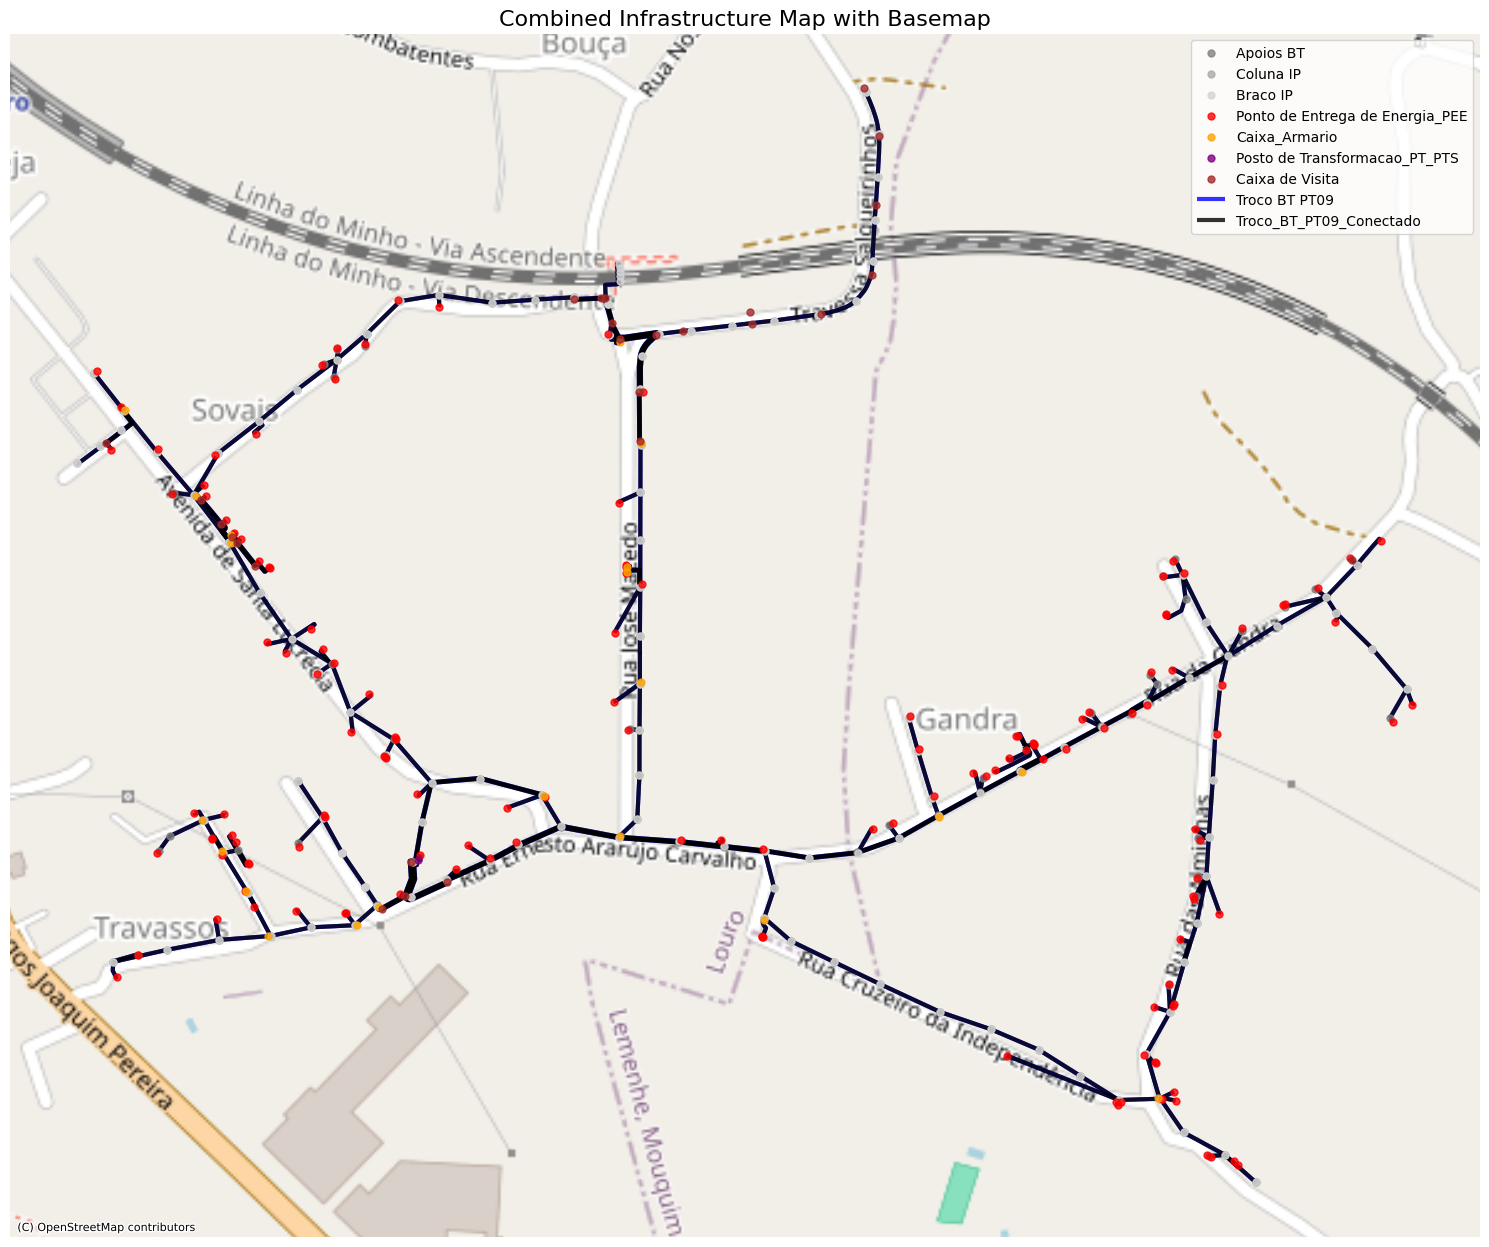

In [35]:
import geopandas
import matplotlib.pyplot as plt
import contextily as ctx


# 1. Create a single figure and axes for the map
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

color_map = {
    'Apoios BT': 'gray', 'Coluna IP': 'darkgray', 'Braco IP': 'lightgray',
    'Ponto de Entrega de Energia_PEE': 'red', 'Caixa_Armario': 'orange',
    'Posto de Transformacao_PT_PTS': 'purple', 'Caixa de Visita': 'brown',
    'Troco BT PT09': 'blue'
}

print("--- Reprojecting data and plotting on a basemap ---")

# 2. Loop through each GeoDataFrame
for name, gdf in all_geodata.items():
    # Reproject the GeoDataFrame to Web Mercator (EPSG:3857) to match the basemap
    gdf_web_mercator = gdf.to_crs(epsg=3857)

    # Get the color for the layer
    color = color_map.get(name, 'black')

    # Plot the REPROJECTED data on the axes
    if 'Point' in gdf_web_mercator.geom_type.unique():
        gdf_web_mercator.plot(ax=ax, color=color, label=name, markersize=25, alpha=0.8, zorder=3)
    else: # For lines
        gdf_web_mercator.plot(ax=ax, color=color, label=name, linewidth=3, alpha=0.8, zorder=2)

# 3. Add the basemap to the axes
#    Contextily is smart and adds it underneath your data
print("Adding basemap...")
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# 4. Customize and show the final map
ax.set_title('Combined Infrastructure Map with Basemap', fontsize=16)
ax.legend()
ax.set_axis_off()

plt.tight_layout()
plt.show()

# Correct file (read)

In [36]:
# The GeoDataFrame you want to save
gdf_to_save_connected = all_geodata['Troco_BT_PT09_Conectado']

# Save to a GeoPackage file by changing the filename and driver
gdf_to_save_connected.to_file("troco_bt_pt09_connected.gpkg", driver="GPKG")

print("GeoDataFrame saved as a GeoPackage file.")

GeoDataFrame saved as a GeoPackage file.


In [37]:
import geopandas as gpd


corrected_file = gpd.read_file(
    "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/troco_bt_pt09_connected.gpkg",
    encoding='latin-1'
)

# Now check the data
print(corrected_file.head())

  DesignaÃ§Ã£o do cabo/condutor                   Tipo FunÃ§Ã£o  \
0                 LXS 4x70 + 16         AÃ©reo apoiado  BT e IP   
1                 LXS 4x70 + 16         AÃ©reo apoiado  BT e IP   
2                      VAV 4x10  SubterrÃ¢neo entubado       IP   
3                 LXS 4x70 + 16         AÃ©reo apoiado  BT e IP   
4                      VV 4x2.5         AÃ©reo pousado       IP   

   Comprimento do sistema [m]  Comprimento real  [m] NÃºmero de fases  \
0                  198.599733                    NaN                3   
1                  387.923355                    NaN                3   
2                  339.281348                    NaN                3   
3                  631.822479                    NaN                3   
4                   24.611977                    NaN                3   

  NÃºmero de condutores por fase NÃºmero de condutores por neutro  \
0                              1                                1   
1                   

# Building eletric network

In [38]:
import fiona

gpkg_path = "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/troco_bt_pt09_connected.gpkg"

try:
    layer_names = fiona.listlayers(gpkg_path)
    print(f"Available layers in '{gpkg_path}':")
    for name in layer_names:
        print(f"- {name}")
except Exception as e:
    print(f"Error reading file: {e}")

Available layers in '/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/troco_bt_pt09_connected.gpkg':
- troco_bt_pt09_connected


In [39]:
all_geodata

{'Apoios BT':         Designação         Nº ID  Número de fabrico Ano de fabrico  \
 0    9BP01-800-320  031223K90258                NaN           2003   
 1    9BP00-400-220  031223K90260                NaN           2003   
 2           8B-100  031223K90261                NaN           1981   
 3           8B-100  031223K90262                NaN           1965   
 4           8B-100  031223K90263                NaN           1965   
 ..             ...           ...                ...            ...   
 125   8BP00-200-80  031226K90927                NaN           2016   
 126         8B-100  031223K90564                NaN          unset   
 127  9BP00-400-220  031223K90565                NaN           2002   
 128   9BF00-200-80  031223K90566                NaN           2002   
 129      Postalete  031223K90586                NaN          unset   
 
      Número do apoio       Tipo    Função  Altura  \
 0                NaN      Betão   BT e IP     9.0   
 1                NaN    

#Cable Library

unique (29 total):

array(['LXS 4x70 + 16', 'VAV 4x10', 'VV 4x2.5', 'VV 4x4', 'LXS 4x25+16',
       'XS 4x6', 'LXS 5x16', 'LXS 4x16', 'VAV 4x6', 'LXS 16',
       'LXS 4x95+16', 'LSVAV 4x95', 'LXS 4x70', 'VAV 3x16 + 10',
       'VAV 3x35+16', 'LXS 4x50', 'LXS 2x16', 'LXS 4x50 + 16', 'V 10',
       'LSVAV 4x50', 'VAV 4x16', 'VAV 3x25 + 16', 'LXS 4x25', 'VV 2x4',
       'XS 2x6', 'XV 4x6', 'XV 4x10', 'w_cabo-PEEs-NAV', 'XV 2x10'],
      dtype=object)

## Valores normativos (E-REDES – DIT-C14-100)

https://www.e-redes.pt/sites/eredes/files/2024-07/DIT-C14-100%20Ed8.pdf#page=15.02


r_ohm_per_km: The values for Copper are from standard IEC 60228 (via "Cables RCT" datasheet). The value for Aluminum is calculated from standard resistivity.

x_ohm_per_km: These are estimates based on the precedents in existing cable_library. This is the most common parameter to estimate, and the values (0.10 - 0.185) are all typical for LV cables.

max_i_ka: These values (ampacity) are from standard IEC 60364-5-52 tables, which is the international standard. I used "Method E" (in free air) for aerial/exposed cables (LXS, XS, VAV) and "Method B1" (in conduit) for the H07V-R, as this matches their likely use

In [40]:
cable_name_map = {
    # --- LXS ---
    "LXS 4x70 + 16": "LXS 4x70 + 16",
    "LXS 4x70+16":   "LXS 4x70 + 16",
    "LXS 4x70 +16":  "LXS 4x70 + 16",

    "LXS 4x70":      "LXS 4x70",
    "LXS 4x95+16":   "LXS 4x95+16",

    "LXS 4x25+16":   "LXS 4x25+16",
    "LXS 4x25":      "LXS 4x25",

    "LXS 5x16":      "LXS 5x16",
    "LXS 4x16":      "LXS 4x16",
    "LXS 16":        "LXS 16",

    "LXS 4x50":      "LXS 4x50",
    "LXS 4x50 + 16": "LXS 4x50 + 16",
    "LXS 4x50+16":   "LXS 4x50 + 16",

    "LXS 2x16":      "LXS 2x16",

    # --- LSVAV ---
    "LSVAV 4x95":    "LSVAV 4x95",
    "LSVAV 4x50":    "LSVAV 4x50",

    # --- XS ---
    "XS 4x6":        "XS 4x6",
    "XS 2x6":        "XS 2x6",

    # --- XV ---
    "XV 4x6":        "XV 4x6",
    "XV 4x10":       "XV 4x10",
    "XV 2x10":       "XV 2x10",

    # --- VV ---
    "VV 4x2.5":      "VV 4x2.5",
    "VV 4x4":        "VV 4x4",
    "VV 2x4":        "VV 2x4",

    # --- V ---
    "V 10":          "V 10",

    # --- VAV ---
    "VAV 4x10":      "VAV 4x10",
    "VAV 4x6":       "VAV 4x6",
    "VAV 4x16":      "VAV 4x16",

    "VAV 3x16 + 10": "VAV 3x16 + 10",
    "VAV 3x16+10":   "VAV 3x16 + 10",

    "VAV 3x35+16":   "VAV 3x35+16",

    "VAV 3x25 + 16": "VAV 3x25 + 16",
    "VAV 3x25+16":   "VAV 3x25 + 16",

    # --- Outros  ---
    "w_cabo-PEEs-NAV": "w_cabo-PEEs-NAV",
}


In [41]:
cable_library = {
    # LXS – torçada aérea 0,6/1 kV  (R e X a 20 ºC, Iz em kA)
    "LXS 2x16": {
        "r_ohm_per_km": 1.910,
        "x_ohm_per_km": 0.10,
        "c_nf_per_km": None,
        "max_i_ka": 0.085,   # Iz = 85 A
        "source": "E-REDES DIT-C14-100 Quadro C1"
    },
    "LXS 4x16": {
        "r_ohm_per_km": 1.910,
        "x_ohm_per_km": 0.10,
        "c_nf_per_km": None,
        "max_i_ka": 0.075,   # Iz = 75 A
        "source": "E-REDES DIT-C14-100 Quadro C1"
    },

    # Uso os mesmos valores para variantes com neutro mais pequeno (+16)
    "LXS 4x25+16": {
        "r_ohm_per_km": 1.200,
        "x_ohm_per_km": 0.10,
        "c_nf_per_km": None,
        "max_i_ka": 0.100,   # Iz = 100 A
        "source": "E-REDES DIT-C14-100 Quadro C1 (LXS 4x25*)"
    },

    "LXS 4x50": {
        "r_ohm_per_km": 0.641,
        "x_ohm_per_km": 0.10,
        "c_nf_per_km": None,
        "max_i_ka": 0.150,   # Iz = 150 A
        "source": "E-REDES DIT-C14-100 Quadro C1"
    },
    "LXS 4x50 + 16": {
        "r_ohm_per_km": 0.641,
        "x_ohm_per_km": 0.10,
        "c_nf_per_km": None,
        "max_i_ka": 0.150,
        "source": "E-REDES DIT-C14-100 Quadro C1 (mesma LXS 4x50)"
    },

    "LXS 4x70": {
        "r_ohm_per_km": 0.443,
        "x_ohm_per_km": 0.10,
        "c_nf_per_km": None,
        "max_i_ka": 0.190,   # Iz = 190 A
        "source": "E-REDES DIT-C14-100 Quadro C1"
    },
    "LXS 4x70 + 16": {
        "r_ohm_per_km": 0.443,
        "x_ohm_per_km": 0.10,
        "c_nf_per_km": None,
        "max_i_ka": 0.190,
        "source": "E-REDES DIT-C14-100 Quadro C1 (LXS 4x70*)"
    },
    "LXS 4x95+16": {
        "r_ohm_per_km": 0.320,
        "x_ohm_per_km": 0.10,
        "c_nf_per_km": None,
        "max_i_ka": 0.230,   # Iz = 230 A
        "source": "E-REDES DIT-C14-100 Quadro C1 (LXS 4x95*)"
    },

    # LXS – aéreo Al XLPE 0,6/1 kV (entrada “pura” 4x25)
    "LXS 4x25": {
        "r_ohm_per_km": 1.200,   # 4x25 Al, valor normativo (≈ LXS 4x25*)
        "x_ohm_per_km": 0.10,
        "c_nf_per_km": None,
        "max_i_ka": 0.100,       # Iz = 100 A (mesmo de LXS 4x25+16)
        "source": "E-REDES DIT-C14-100 Quadro C1 (LXS 4x25)"
    },

    # LSVAV – subterrâneo 0,6/1 kV (armado)
    "LSVAV 4x95": {
        "r_ohm_per_km": 0.320,
        "x_ohm_per_km": 0.10,
        "c_nf_per_km": None,
        "max_i_ka": 0.235,   # Iz = 235 A
        "source": "E-REDES DIT-C14-100 Quadro C2"
    },
    # LSVAV – subterrâneo 0,6/1 kV (armado)
    #"Alcobre LSVAV 0,6/1 kV 4x50 mm²: R20=0,641 Ω/km, "
    #"Iz, enterrado 20 °C = 150 A; X≈0,10 Ω/km assumido "
    #"como típico da gama LSVAV/LXS 16–95 mm²."
    "LSVAV 4x50": {
        "r_ohm_per_km": 0.641,   # Alcobre LSVAV 4x50, R20
        "x_ohm_per_km": 0.10,    # X típico BT Al 0,6/1 kV (aprox.)
        "c_nf_per_km": 0.0,      # não temos, mas pandapower exige o campo
        "max_i_ka": 0.150,      # 150 A enterrado (Alcobre / DMA-C33-200)
        "source": "DMA-C33-200 + catálogo Alcobre LSVAV 4x50 (I_enterrado ≈ 150 A)"
    },


    # XS – torçada Cu XLPE 0,6/1 kV
    "XS 2x6": {
        # d08 = 5,96 ; d092 = 6,79  (Tabela 1B, monofásico, 6 mm²)
        # → R ≈ 3,6445 ; X ≈ 0,1074 Ω/km
        # Iz (ramal BT): Imax = 55 A  → 0,055 kA
        "r_ohm_per_km": 3.6445,
        "x_ohm_per_km": 0.1074,
        "c_nf_per_km": None,
        "max_i_ka": 0.055,
        "source": "Nexans/FICAP Tabela 1B + STN Ramais BT (XS 2x6 Imax=55 A)"
    },

    # XV – cabos XLPE 90 °C
    "XV 4x6": {
        # d08/d092 como VAV 4x6 (trifásico 6 mm²)
        # → R ≈ 4,2145 ; X ≈ 0,1830 Ω/km
        # Imax (ramal BT trifásico): 64 A  → 0,064 kA
        "r_ohm_per_km": 4.2145,
        "x_ohm_per_km": 0.1830,
        "c_nf_per_km": None,
        "max_i_ka": 0.064,
        "source": "Nexans/FICAP Tabela 1B + STN Ramais BT (XV 4x6 Imax=64 A)"
    },
    "XV 4x10": {
        # d08 = 3,57 ; d092 = 4,01  (10 mm² trifásico)
        # → R ≈ 2,4377 ; X ≈ 0,1850 Ω/km
        # Imax (ramal BT trifásico): 86 A  → 0,086 kA
        "r_ohm_per_km": 2.4377,
        "x_ohm_per_km": 0.1850,
        "c_nf_per_km": None,
        "max_i_ka": 0.086,
        "source": "Nexans/FICAP Tabela 1B + STN Ramais BT (XV 4x10 Imax=86 A)"
    },
    "XV 2x10": {
        # d08 = 3,50 ; d092 = 3,96  (10 mm² monofásico)
        # → R ≈ 2,1057 ; X ≈ 0,1090 Ω/km
        # Imax (ramal BT monofásico): 90 A  → 0,090 kA
        "r_ohm_per_km": 2.1057,
        "x_ohm_per_km": 0.1090,
        "c_nf_per_km": None,
        "max_i_ka": 0.090,
        "source": "Nexans/FICAP Tabela 1B + STN Ramais BT (XV 2x10 Imax=90 A)"
    },

    # VV – PVC 70 °C (monofásico 2x4)
    "VV 2x4": {
        # Tabela 1B, monofásico 4 mm²: d08 = 8,89 ; d092 = 10,15
        # → R ≈ 5,4638 ; X ≈ 0,1233 Ω/km
        # Iz ao ar (40 ºC) VV 0,6/1 kV 2x4 mm² bipolares ≈ 35 A → 0,035 kA
        "r_ohm_per_km": 5.4638,
        "x_ohm_per_km": 0.1233,
        "c_nf_per_km": None,
        "max_i_ka": 0.035,
        "source": (
            "Nexans/FICAP Tabela 1B, monofásico 4 mm² + fórmula rx_monofasico; "
            "Iz,ar ≈ 35 A (Eurocabos VV 2x4 ao ar 40 ºC)"
        ),
    },

    # VAV – XLPE 90 °C
    "VAV 4x6": {
        # d08 = 6,03 ; d092 = 6,84 (trifásico 6 mm²)
        # → R ≈ 4,2145 ; X ≈ 0,1830 Ω/km
        # Iz (aprox., ao ar 3–4 cond.): 44 A → 0,044 kA
        "r_ohm_per_km": 4.2145,
        "x_ohm_per_km": 0.1830,
        "c_nf_per_km": None,
        "max_i_ka": 0.044,
        "source": (
            "Nexans/FICAP Tabela 1B, trifásico 6 mm² + fórmula rx_trifasico; "
            "Iz≈44 A (ao ar, 3–4 cond.)"
        ),
    },
    "VAV 4x10": {
        # d08 = 3,57 ; d092 = 4,01 (10 mm² trifásico)
        # → R ≈ 2,4377 ; X ≈ 0,1850 Ω/km
        # Iz (aprox., ao ar 3–4 cond.): 61 A → 0,061 kA
        "r_ohm_per_km": 2.4377,
        "x_ohm_per_km": 0.1850,
        "c_nf_per_km": None,
        "max_i_ka": 0.061,
        "source": (
            "Nexans/FICAP Tabela 1B, trifásico 10 mm² + fórmula rx_trifasico; "
            "Iz≈61 A (ao ar, 3–4 cond.)"
        ),
    },
    "VAV 4x16": {
        # d08 = 2,33 ; d092 = 2,58 (16 mm² trifásico)
        # → R ≈ 1,5370 ; X ≈ 0,1927 Ω/km
        # Iz (aprox., ao ar 3–4 cond.): 82 A → 0,082 kA
        "r_ohm_per_km": 1.5370,
        "x_ohm_per_km": 0.1927,
        "c_nf_per_km": None,
        "max_i_ka": 0.082,
        "source": (
            "Nexans/FICAP Tabela 1B, trifásico 16 mm² + fórmula rx_trifasico; "
            "Iz≈82 A (ao ar, 3–4 cond.)"
        ),
    },
    "VAV 3x25 + 16": {
        # usa secção de fase 25 mm²; d08 = 1,56 ; d092 = 1,71 (trifásico 25 mm²)
        # → R ≈ 1,0038 ; X ≈ 0,1627 Ω/km
        # Iz (aprox., ao ar 3 cond.): 110 A → 0,110 kA
        "r_ohm_per_km": 1.0038,
        "x_ohm_per_km": 0.1627,
        "c_nf_per_km": None,
        "max_i_ka": 0.110,
        "source": (
            "Nexans/FICAP Tabela 1B, trifásico 25 mm² + fórmula rx_trifasico (fases); "
            "Iz≈110 A (ao ar, 3 cond.)"
        ),
    },

    # Ramal “w_cabo-PEEs-NAV” – assumido equivalente a LXS 4x16 (3F+N aéreo apoiado BT)
    "w_cabo-PEEs-NAV": {
        "r_ohm_per_km": 1.910,
        "x_ohm_per_km": 0.10,
        "c_nf_per_km": None,
        "max_i_ka": 0.075,   # 75 A -> 0,075 kA
        "source": "Assumido igual a LXS 4x16 (ramal BT 3F+N aéreo apoiado)"
    },
    "LXS 5x16": {
            "r_ohm_per_km": 1.767,  # Max resistance for 16mm² Al @ 20°C (calc from resistivity)
            "x_ohm_per_km": 0.10,   # Assumed, consistent with your other LXS/LSVAV cables
            "c_nf_per_km": 0.0,
            "max_i_ka": 0.068,      # 68 A (Ampacity for 16mm² Al, general table)
            "source": "Calculated R, Estimated X, Ampacity from Al cable tables"
        },
   "XS 4x6": {
        "r_ohm_per_km": 3.08,   # Max resistance for 6mm² Cu @ 20°C (IEC 60228)
        "x_ohm_per_km": 0.185,  # Estimated, based on your XV 4x10
        "c_nf_per_km": 0.0,
        "max_i_ka": 0.054,      # 54 A (IEC 60364-5-52, Table B.52.12, 3-loaded, Method E)
        "source": "IEC 60228 (R), IEC 60364-5-52 (Iz), Estimated X"
    },
  "VV 4x2.5": {
        "r_ohm_per_km": 7.41,   # Max resistance for 2.5mm² Cu @ 20°C (IEC 60228)
        "x_ohm_per_km": 0.123,  # Estimated, based on your VV 2x4
        "c_nf_per_km": 0.0,
        "max_i_ka": 0.023,      # 23 A (IEC 60364-5-52, 3-loaded, PVC, Method E)
        "source": "IEC 60228 (R), IEC 60364-5-52 (Iz), Estimated X"
    },
  "VV 4x4": {
        "r_ohm_per_km": 4.61,   # Max resistance for 4mm² Cu @ 20°C (IEC 60228)
        "x_ohm_per_km": 0.123,  # Estimated, based on your VV 2x4
        "c_nf_per_km": 0.0,
        "max_i_ka": 0.031,      # 31 A (IEC 60364-5-52, 3-loaded, PVC, Method E)
        "source": "IEC 60228 (R), IEC 60364-5-52 (Iz), Estimated X"
    },
  "V 10": {
        "r_ohm_per_km": 1.83,   # Max resistance for 10mm² Cu @ 20°C (IEC 60228)
        "x_ohm_per_km": 0.109,  # Estimated, based on your XV 2x10
        "c_nf_per_km": 0.0,
        "max_i_ka": 0.050,      # 50 A (IEC 60364-5-52, 2-loaded, PVC, Method B1)
        "source": "H07V-R Datasheet (IEC 60228/IEC 60364)"
    },
   "VAV 3x16 + 10": {
        "r_ohm_per_km": 1.15,   # Max resistance for 16mm² Cu @ 20°C (IEC 60228)
        "x_ohm_per_km": 0.10,   # Assumed, consistent with your other LSVAV cables
        "c_nf_per_km": 0.0,
        "max_i_ka": 0.100,      # 100 A (IEC 60364-5-52, Table B.52.12, 3-loaded, Method E)
        "source": "IEC 60228 (R), IEC 60364-5-52 (Iz), Estimated X"
    },
   "VAV 3x35+16": {
        "r_ohm_per_km": 0.524,  # Max resistance for 35mm² Cu @ 20°C (IEC 60228)
        "x_ohm_per_km": 0.10,   # Assumed, consistent with your other LSVAV cables
        "c_nf_per_km": 0.0,
        "max_i_ka": 0.158,      # 158 A (IEC 60364-5-52, Table B.52.12, 3-loaded, Method E)
        "source": "IEC 60228 (R), IEC 60364-5-52 (Iz), Estimated X"
    },

#"LXS 16" is common shorthand for "LXS 4x16", so just minmicting
 "LXS 16": {
        "r_ohm_per_km": 3.6445,  # <-- Example value, you must find the correct one
        "x_ohm_per_km": 0.1074,  # <-- Example value
        "c_nf_per_km": 0.0,
        "max_i_ka": 0.055,       # <-- Example value
        "source": "Source for XS 4x6 parameters"
    },

}


In [42]:
import pandapower as pp
import pandas as pd
import geopandas as gpd
import numpy as np
import fiona
import pandapower.topology as ppt
import networkx as nx
from shapely.geometry import Point, LineString, MultiLineString
from shapely.ops import linemerge
from sklearn.cluster import DBSCAN

# 1) Fallback "default" cable type

cable_library["default"] = {
    "r_ohm_per_km": cable_library["LXS 4x16"]["r_ohm_per_km"],
    "x_ohm_per_km": cable_library["LXS 4x16"]["x_ohm_per_km"],
    "c_nf_per_km": 0.0,  # em BT o efeito é pequeno, mas pandapower exige o campo
    "max_i_ka":    cable_library["LXS 4x16"]["max_i_ka"],
    "source": "Fallback 'default' = LXS 4x16 (para segmentos sem tipo explícito)",
}

# 2) Network setup + criação robusta dos std_types

SN_MVA = 1.0
net = pp.create_empty_network(sn_mva=SN_MVA)

created_types = 0
for name, params in cable_library.items():
    if params is None:
        continue

    p = params.copy()

    # É obrigatório ter pelo menos R e X
    if p.get("r_ohm_per_km") is None or p.get("x_ohm_per_km") is None:
        # exemplo: LSVAV 4x50 ainda sem R/X → ignora
        continue

    # Capacitância: mete 0.0 se vier None
    if p.get("c_nf_per_km") is None:
        p["c_nf_per_km"] = 0.0

    data = {
        "r_ohm_per_km": p["r_ohm_per_km"],
        "x_ohm_per_km": p["x_ohm_per_km"],
        "c_nf_per_km": p["c_nf_per_km"],
        "max_i_ka": p.get("max_i_ka"),
    }

    pp.create_std_type(net, data, name=name, element="line")
    created_types += 1

print(f"Created {created_types} standard cable types.")



# 3) Load geodata (lines)

file_path = "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/troco_bt_pt09_connected.gpkg"
lines_gdf = gpd.read_file(file_path, layer="troco_bt_pt09_connected").dropna(subset=["geometry"])
print(f"Loaded {len(lines_gdf)} line features.")

possible_cable_cols = [
    "Designação do cabo/condutor",
    "DesignaÃ§Ã£o do cabo/condutor",
    "cable_type",
]
CABLE_TYPE_COL = next((c for c in possible_cable_cols if c in lines_gdf.columns), None)
if CABLE_TYPE_COL is None:
    raise KeyError("Cable type column not found.")

possible_length_cols = ["Comprimento do sistema [m]", "length_m"]
LENGTH_COL = next((c for c in possible_length_cols if c in lines_gdf.columns), None)
ID_COL = "id" if "id" in lines_gdf.columns else lines_gdf.columns[0]

if lines_gdf.crs is None:
    raise ValueError("Input lines have no CRS.")
lines_gdf = lines_gdf.to_crs(3763)


# 3.1) Extract ALL vertices from lines

all_coords = []

def extract_coords(geom):
    """Recursively extracts all coordinates from geometries."""
    if isinstance(geom, LineString):
        all_coords.extend(geom.coords)
    elif isinstance(geom, MultiLineString):
        for part in geom.geoms:
            extract_coords(part)  # recurse

for geom in lines_gdf.geometry:
    try:
        extract_coords(geom)
    except Exception as e:
        print(f"Warning: Skipping a geometry. Error: {e}")
        continue

if not all_coords:
    raise ValueError("No coordinates were extracted from line geometries.")

print(f"Extracted {len(all_coords)} total vertices from lines.")
all_coords_array = np.array(all_coords)


# 3.2) Cluster vertices into buses (DBSCAN)
db = DBSCAN(eps=1.0, min_samples=1).fit(all_coords_array[:, :2])  # Use only x, y
labels = db.labels_
n_clusters = len(set(labels))
print(f"Clustered {len(all_coords)} vertices into {n_clusters} unique buses (1.0m tolerance).")

# map coord -> bus (cluster id)
coord_to_bus_map = {
    (round(coord[0], 8), round(coord[1], 8)): label
    for coord, label in zip(all_coords, labels)
}

# create buses
bus_geodata_records = []
bus_cluster_centroids = {}
for bus_idx in set(labels):
    if bus_idx == -1:
        continue

    cluster_points = all_coords_array[labels == bus_idx]
    centroid = cluster_points.mean(axis=0)
    x, y = centroid[0], centroid[1]

    pp.create_bus(net, vn_kv=0.4, name=f"Bus_{bus_idx}")
    bus_geodata_records.append({"x": x, "y": y, "bus": bus_idx})
    bus_cluster_centroids[bus_idx] = (x, y)

net.bus_geodata = pd.DataFrame(bus_geodata_records).set_index("bus")[["x", "y"]]
print(f"Created {len(net.bus)} buses from clusters.")

bus_points_gdf = gpd.GeoDataFrame(
    net.bus_geodata.copy(),
    geometry=[Point(xy) for xy in net.bus_geodata[["x", "y"]].to_numpy()],
    crs=3763
)

# helper: deterministic nearest that always returns 'bus_id'

def nearest_bus_ids(left_gdf: gpd.GeoDataFrame, right_bus_gdf: gpd.GeoDataFrame):
    rb = right_bus_gdf.copy()
    if rb.index.name is None:
        rb.index.name = "bus"
    rb = rb.reset_index()
    id_col = "bus" if "bus" in rb.columns else ("index" if "index" in rb.columns else None)
    if id_col is None:
        for c in rb.columns:
            if pd.api.types.is_integer_dtype(rb[c]):
                id_col = c
                break
    if id_col is None:
        raise KeyError("Could not find bus id column after reset_index().")
    rb = rb.rename(columns={id_col: "bus_id"})

    if left_gdf.crs != rb.crs:
        left_gdf = left_gdf.to_crs(rb.crs)
    joined = gpd.sjoin_nearest(left_gdf, rb, how="left", distance_col="dist")
    if "bus_id" not in joined.columns:
        raise KeyError(f"'bus_id' not in join result. Columns: {list(joined.columns)}")
    return joined["bus_id"], joined


# 3.3) Create Line Segments between all buses
net.line_geodata = pd.DataFrame(columns=["coords"])
created_segments = 0

def get_bus_from_coord(coord, coord_map):
    """Finds a bus ID from a coordinate, handling floating point precision."""
    key = (round(coord[0], 8), round(coord[1], 8))
    bus_id = coord_map.get(key)
    if bus_id is None:
        key_x_r, key_y_r = key
        for (map_x, map_y), b_id in coord_map.items():
            if abs(map_x - key_x_r) < 1e-7 and abs(map_y - key_y_r) < 1e-7:
                return b_id
    return bus_id


def create_segments_for_linestring(geom, row_data, coord_map):
    """
    Takes a single LineString and creates pandapower lines for each segment
    (e.g., A->B, B->C, C->D).
    """
    segment_count = 0
    if not isinstance(geom, LineString) or len(geom.coords) < 2:
        return 0

    # -------- Resolve cable type  --------
    raw_val = row_data[CABLE_TYPE_COL]
    if pd.isna(raw_val):
        raw_name = ""
    else:
        raw_name = str(raw_val).strip()

    # 1) tentar direto
    norm_key = cable_name_map.get(raw_name, raw_name)

    # 2) tentar sem espaços (ex: "LXS4x70+16")
    if norm_key not in cable_library:
        no_space = raw_name.replace(" ", "")
        norm_key = cable_name_map.get(no_space, norm_key)

    # 3) fallback: 'default'
    if norm_key not in cable_library:
        cable_type = "default"
        if raw_name:
            print(f"[INFO] Using default type for cable name '{raw_name}' (id={row_data[ID_COL]})")
    else:
        cable_type = norm_key

    original_id = row_data[ID_COL]

    # ---------------------------------------------------------------------------

    for i in range(len(geom.coords) - 1):
        a_coords = geom.coords[i]
        b_coords = geom.coords[i + 1]

        from_bus = get_bus_from_coord(a_coords, coord_map)
        to_bus   = get_bus_from_coord(b_coords, coord_map)

        if from_bus is None or to_bus is None:
            print(f"Warning: Could not find bus for segment {a_coords} -> {b_coords} in line {original_id}")
            continue

        if from_bus == to_bus:
            continue

        segment_length_m = Point(a_coords).distance(Point(b_coords))
        if segment_length_m < 0.01:  # 1 cm threshold
            continue

        segment_length_km = segment_length_m / 1000.0
        line_name = f"Cable_{original_id}_seg{i}"

        try:
            line_idx = pp.create_line(
                net,
                from_bus=from_bus,
                to_bus=to_bus,
                length_km=segment_length_km,
                std_type=cable_type,
                name=line_name,
                parallel=1,
            )
            net.line_geodata.loc[line_idx] = [[a_coords, b_coords]]
            segment_count += 1
        except Exception as e:
            print(f"Warning: Failed to create segment {line_name} ({from_bus} -> {to_bus}). Error: {e}")
            continue

    return segment_count


# --- Main loop for Section 3.3 ---
for _, row in lines_gdf.iterrows():
    geom = row.geometry
    try:
        if isinstance(geom, LineString):
            created_segments += create_segments_for_linestring(geom, row, coord_to_bus_map)
        elif isinstance(geom, MultiLineString):
            for part in geom.geoms:
                created_segments += create_segments_for_linestring(part, row, coord_to_bus_map)
    except Exception as e:
        print(f"Error processing row {row[ID_COL]}: {e}")

print(f"Created {created_segments} line *segments* and stored their paths.")


# 5) Attach Loads (PEE) from all_geodata

print("\n--- Attaching Loads (PEE) ---")
pee_gdf = all_geodata['Ponto de Entrega de Energia_PEE'].dropna(subset=['geometry'])

if pee_gdf.crs != bus_points_gdf.crs:
    pee_gdf = pee_gdf.to_crs(bus_points_gdf.crs)

attached_loads = 0
if not pee_gdf.empty:
    bus_ids, joined = nearest_bus_ids(pee_gdf, bus_points_gdf)
    max_snap_m = 5

    for i, row in joined.iterrows():
        bus_id = row["bus_id"]
        dist = row["dist"]

        if pd.isna(bus_id) or (not pd.isna(dist) and dist > max_snap_m):
            continue

        p_mw = 0.001  # 1 kW
        q_mvar = p_mw * np.tan(np.arccos(0.95))
        name = f"Load_{pee_gdf.loc[i].get('Id', i)}"

        try:
            pp.create_load(net, bus=int(bus_id), p_mw=p_mw, q_mvar=q_mvar, name=name)
            attached_loads += 1
        except Exception:
            continue

    print(f"Added {attached_loads} loads to the network (≤ {max_snap_m} m from a bus).")
else:
    print("No PEE features found; no loads added.")

# 6) Find Main Island & Attach Power Source (PT)

print("\n--- Locating Main Grid Island ---")
G = ppt.create_nxgraph(net, include_trafos=False, include_switches=True, respect_switches=True)
islands = list(nx.connected_components(G))
print(f"Network topology has {len(islands)} connected component(s) (islands).")

main_island_buses = set()
main_island_load_count = 0

if not net.load.empty:
    load_buses = set(net.load.bus)
    island_load_counts = []
    for island_set in islands:
        loads_on_this_island = len(load_buses.intersection(island_set))
        island_load_counts.append((loads_on_this_island, island_set))

    island_load_counts.sort(key=lambda x: x[0], reverse=True)
    main_island_load_count, main_island_buses = island_load_counts[0]

    if main_island_load_count > 0:
        print(f"Main island identified: {main_island_load_count} loads on an island with {len(main_island_buses)} buses.")
    else:
        print("Warning: No loads are on any connected line. Defaulting to largest island by bus count.")
        islands.sort(key=lambda x: len(x), reverse=True)
        main_island_buses = islands[0] if islands else set()
        print(f"Defaulted to largest island with {len(main_island_buses)} buses.")
else:
    print("No loads in network. Defaulting to largest island by bus count.")
    islands.sort(key=lambda x: len(x), reverse=True)
    if islands:
        main_island_buses = islands[0]
        print(f"Defaulted to largest island with {len(main_island_buses)} buses.")
    else:
        print("Network graph is empty. No ext_grid will be created.")



# 6) Ext grid exatamente no ponto do PT (sem nearest) +  PT

print("\n--- Attach PT as ext_grid at its exact vertex ---")

# 1) PT
pt_gdf = all_geodata['Posto de Transformacao_PT_PTS'].dropna(subset=['geometry'])
if pt_gdf.crs != bus_points_gdf.crs:
    pt_gdf = pt_gdf.to_crs(bus_points_gdf.crs)

if pt_gdf.empty:
    raise RuntimeError("PT layer is empty – cannot place ext_grid.")

pt = pt_gdf.geometry.iloc[0]
pt_x, pt_y = float(pt.x), float(pt.y)
key = (round(pt_x, 8), round(pt_y, 8))
print(f"PT @ ({pt_x:.3f}, {pt_y:.3f})")

# 2) remover fontes antigas
if not net.ext_grid.empty:
    net.ext_grid.drop(net.ext_grid.index, inplace=True)

# 3) tentar usar o bus EXACTO (vértice do cluster)
pt_bus = coord_to_bus_map.get(key)

if (pt_bus is not None) and (pt_bus in net.bus.index):
    # PT coincide com um vértice de linha
    pt_bus = int(pt_bus)
    print(f"PT coincide com bus existente: {pt_bus}")
else:
    # criar bus novo no PT
    pt_bus = int(pp.create_bus(net, vn_kv=0.4, name="PT_Louro-Gandra"))
    net.bus_geodata.loc[pt_bus, ["x","y"]] = [pt_x, pt_y]
    print(f"Criado bus novo para PT: {pt_bus} (garante conectores PT→linhas no layer)")

# 4) criar a fonte única no bus do PT
pp.create_ext_grid(net, bus=pt_bus, vm_pu=1.02, name="PT Louro-Gandra (250 kVA)")

# 5) (re)calcular ilhas e focar na que contém o PT
G = ppt.create_nxgraph(net, include_trafos=False, include_switches=True, respect_switches=True)
islands = list(nx.connected_components(G))
print(f"Topology: {len(islands)} componente(s) após colocar o PT.")

# escolher a ilha que contém o bus do PT
main_island_buses = set()
for comp in islands:
    if pt_bus in comp:
        main_island_buses = set(comp)
        break
if not main_island_buses:
    print("AVISO: PT ficou numa ilha sem linhas (provável falta de conector PT→linha).")


# 7) Run Power Flow (robust) + report na ilha do PT + check 250 kVA

print("\n--- Pandapower Network Built ---")
print(net)

if net.ext_grid.empty:
    print("\n---  Cannot run power flow: No external grid is defined. ---")
else:
    try:
        pp.runpp(net, algorithm="nr", init="flat", calculate_voltage_angles=True, numba=False)

        if not getattr(net, "converged", False):
            print("\n---  Power flow did NOT converge ---")
        else:
            print("\n---  Power flow converged ---")


            if main_island_buses:
                res_pt_island = net.res_bus.loc[net.res_bus.index.isin(main_island_buses)]
                print(f"\n--- Results on PT island ({len(main_island_buses)} buses) ---")
                print(res_pt_island.head(10))
                n_nan = res_pt_island['vm_pu'].isna().sum()
                if n_nan > 0:
                    print(f"---  WARNING: {n_nan} buses with NaN on the PT island. ---")
            else:
                print("--- WARNING: PT island not identified (empty). ---")

            # Check de capacidade do PT (250 kVA)
            p_tot_mw = float(net.load.p_mw.fillna(0).sum())
            q_tot_mvar = float(net.load.q_mvar.fillna(0).sum())
            s_tot_mva = (p_tot_mw**2 + q_tot_mvar**2) ** 0.5
            s_pt_mva = 0.250  # 250 kVA
            util_pct = 100.0 * s_tot_mva / s_pt_mva if s_pt_mva > 0 else np.nan

            print(f"\nPT 250 kVA: S_total = {s_tot_mva*1000:.1f} kVA  ({util_pct:.1f}% da capacidade)")
            if util_pct > 100:
                print("ALERTA: Carga aparente excede a potência do PT.")
            elif util_pct > 80:
                print("Aviso: PT acima de 80% — verifica quedas de tensão e perdas.")

            # Info sobre ilhas sem o PT (se existirem)
            other_buses_count = len(net.bus) - (len(main_island_buses) if main_island_buses else 0)
            if other_buses_count > 0:
                print(f"--- Nota: {other_buses_count} buses estão noutras ilhas e podem mostrar NaN ---")

    except Exception as e:
        print(f"\n---  Power flow failed with an error: {e} ---")

# 8) DEBUG: Save isolated buses to a new file

print("\n--- DEBUGGING ISLANDS ---")
try:
    all_bus_indices = set(net.bus.index)
    isolated_bus_indices = all_bus_indices - main_island_buses

    if not isolated_bus_indices:
        print("Network is fully connected. No isolated buses found.")
    else:
        isolated_bus_gdf = bus_points_gdf.loc[bus_points_gdf.index.isin(isolated_bus_indices)]

        output_path = "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/DEBUG_ISOLATED_BUSES.gpkg"
        isolated_bus_gdf.to_file(output_path, driver="GPKG")

        print(f"---   Wrote {len(isolated_bus_gdf)} isolated buses to: ---")
        print(output_path)

except Exception as e:
    print(f"Could not save debug file: {e}")


Created 30 standard cable types.
Loaded 270 line features.
Extracted 1315 total vertices from lines.
Clustered 1315 vertices into 459 unique buses (1.0m tolerance).
Created 459 buses from clusters.
Created 601 line *segments* and stored their paths.

--- Attaching Loads (PEE) ---
Added 145 loads to the network (≤ 5 m from a bus).

--- Locating Main Grid Island ---
Network topology has 1 connected component(s) (islands).
Main island identified: 131 loads on an island with 459 buses.

--- Attach PT as ext_grid at its exact vertex ---
PT @ (-33553.413, 195909.098)
PT coincide com bus existente: 458
Topology: 1 componente(s) após colocar o PT.

--- Pandapower Network Built ---
This pandapower network includes the following parameter tables:
   - bus (459 elements)
   - load (145 elements)
   - ext_grid (1 element)
   - line (601 elements)
   - bus_geodata (459 elements)
   - line_geodata (601 elements)

---  Power flow converged ---

--- Results on PT island (459 buses) ---
      vm_pu  va

In [43]:
import fiona
import geopandas as gpd

gpkg_path_isolared = gpd.read_file("/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/DEBUG_ISOLATED_BUSES.gpkg",
                                       encoding='latin-1')

# Now check the data
print(gpkg_path_isolared)


     bus             x            y                       geometry
0     81 -33405.010250  196326.6500    POINT (-33405.01 196326.65)
1     82 -33406.352000  196326.6500   POINT (-33406.352 196326.65)
2     83 -33406.444500  196329.9230  POINT (-33406.444 196329.923)
3     84 -33405.164333  196329.9230  POINT (-33405.164 196329.923)
4     85 -33406.523000  196332.7225  POINT (-33406.523 196332.722)
..   ...           ...          ...                            ...
183  453 -33774.688000  195830.4270  POINT (-33774.688 195830.427)
184  454 -33772.163000  195825.5380  POINT (-33772.163 195825.538)
185  455 -33771.271000  195825.9910  POINT (-33771.271 195825.991)
186  456 -33666.832000  196102.2740  POINT (-33666.832 196102.274)
187  457 -33785.962000  196261.5730  POINT (-33785.962 196261.573)

[188 rows x 4 columns]


Loaded 188 isolated buses to highlight.
Plotting network lines...
Plotting all buses...
Highlighting isolated buses...


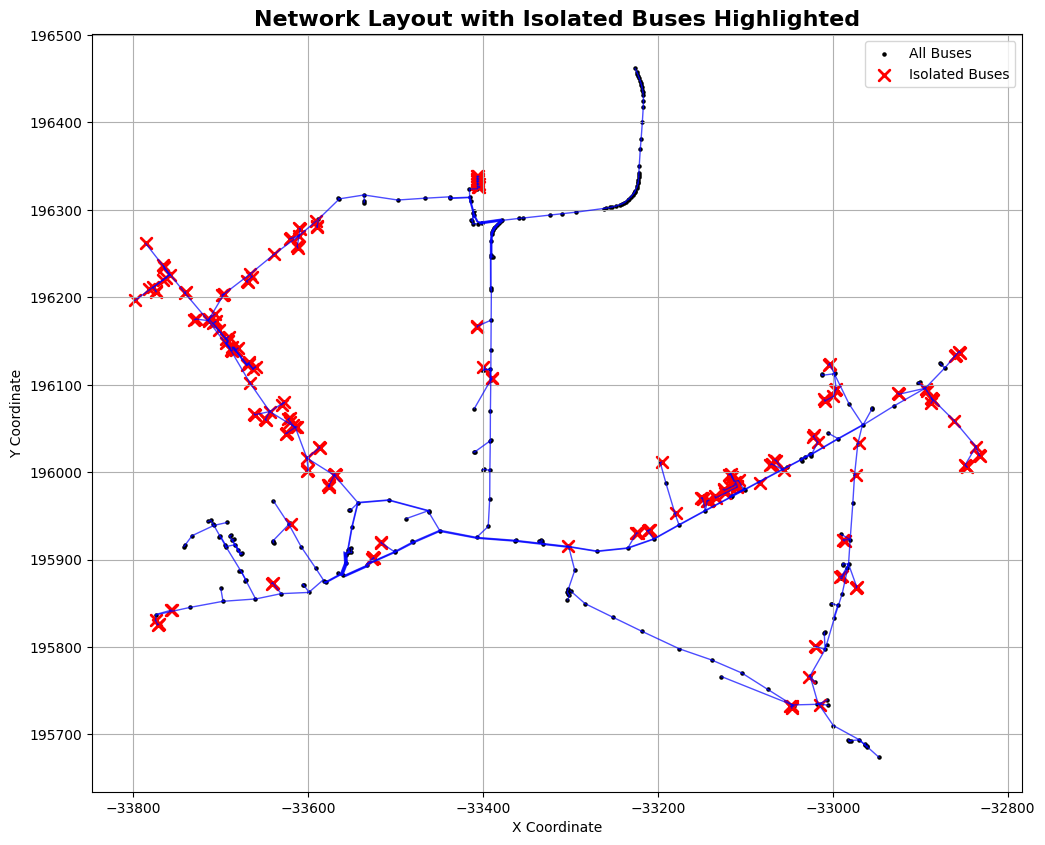

In [44]:
import matplotlib.pyplot as plt
import pandapower.plotting as plot
import numpy as np
import fiona
import geopandas as gpd

# --- 1. Load the Isolated Buses Data FIRST ---
try:
    gpkg_path_isolared = gpd.read_file(
        "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/DEBUG_ISOLATED_BUSES.gpkg",
        encoding='latin-1'
    )
    print(f"Loaded {len(gpkg_path_isolared)} isolated buses to highlight.")
except Exception as e:
    print(f"Could not load isolated buses file: {e}")
    # Create an empty GeoDataFrame so the script doesn't crash
    gpkg_path_isolared = gpd.GeoDataFrame(geometry=[])

# --- 2. Create the Figure ---
fig, ax = plt.subplots(figsize=(12, 12))

# --- 3. Manually Plot Each Line ---
# (This assumes 'net' already exists from your main script)
print("Plotting network lines...")
for idx, line in net.line.iterrows():
    coords = net.line_geodata.loc[idx, 'coords']
    x, y = zip(*coords)
    # Plot lines with some transparency and no legend entry
    ax.plot(x, y, color='blue', linewidth=1, alpha=0.7, label='_nolegend_')

# --- 4. Plot ALL Buses (as small dots) ---
print("Plotting all buses...")
if 'bus_geodata' in net:

    bus_points_gdf.plot(
        ax=ax,
        color='black',
        markersize=5,
        label='All Buses'
    )
# --- 5. Plot ISOLATED Buses (on top) ---
print("Highlighting isolated buses...")
if not gpkg_path_isolared.empty:
    # Ensure the CRS matches
    if gpkg_path_isolared.crs != bus_points_gdf.crs:
        gpkg_path_isolared = gpkg_path_isolared.to_crs(bus_points_gdf.crs)

    gpkg_path_isolared.plot(
        ax=ax,
        color='red',
        markersize=60,  # Make them large
        marker='x',     # Use an 'x'
        linewidth=2,    # Make the 'x' thick
        label='Isolated Buses'
    )

# --- 6. Finalize and Show the Plot ---
ax.set_title("Network Layout with Isolated Buses Highlighted", fontsize=16, fontweight='bold')
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
ax.legend() # This will now show "All Buses" and "Isolated Buses"
plt.show()

In [45]:
na_buses_df = net.res_bus[net.res_bus['vm_pu'].isna()]

print("--- Buses that did NOT converge (NA results) ---")
print(na_buses_df)

import pandapower.topology as ppt

# The correct function is unsupplied_buses()
isolated_bus_indices = ppt.unsupplied_buses(net)

if len(isolated_bus_indices):
    print(f"\n---  Found {len(isolated_bus_indices)} unsupplied buses (isolated) ---")
    print(isolated_bus_indices)
else:
    print("\n---  All buses are supplied (fully connected)! ---")


# pp.runpp(net)

# Get the index (bus ID) of all rows where voltage is 'Not a Number'
isolated_bus_indices = net.res_bus[net.res_bus['vm_pu'].isna()].index

print(f"\n--- 💡 Found {len(isolated_bus_indices)} buses with NA results (isolated) ---")
print(isolated_bus_indices)


--- Buses that did NOT converge (NA results) ---
Empty DataFrame
Columns: [vm_pu, va_degree, p_mw, q_mvar]
Index: []

---  All buses are supplied (fully connected)! ---

--- 💡 Found 0 buses with NA results (isolated) ---
Index([], dtype='int64')


In [46]:
import networkx as nx

G = ppt.create_nxgraph(net)
# eg_bus is your power source:
eg_bus = int(net.ext_grid.bus.iloc[0])

main_island = set()
all_isolated_nodes = set()

# Find all connected "islands" in the graph
for island_nodes in nx.connected_components(G):
    # Check if the power source is in this island
    if eg_bus in island_nodes:
        main_island = island_nodes
    else:
        # If not, all nodes in this island are "isolated"
        all_isolated_nodes.update(island_nodes)

print(f"\n---  NetworkX Analysis ---")
print(f"Main island has {len(main_island)} buses.")
print(f"Found {len(all_isolated_nodes)} buses on other isolated islands.")
# print(all_isolated_nodes)


---  NetworkX Analysis ---
Main island has 459 buses.
Found 0 buses on other isolated islands.


In [47]:
# Print results for the external grid bus
eg_bus_index = net.ext_grid.bus.iloc[0]
print(f"\n--- Results for External Grid (Bus {eg_bus_index}) ---")
print(net.res_bus.loc[eg_bus_index])

# Print results for the first 10 buses that have loads
load_buses = net.load.bus.unique()
print(f"\n--- Results for first 10 buses with loads ---")
print(net.res_bus.loc[load_buses].head(10))

# Print the head of the *converged* buses (dropping all NaN rows)
print(f"\n--- Head of ALL Converged Buses ---")
print(net.res_bus.dropna().head(10))

# Print a summary of all converged bus voltages
print(f"\n--- Voltage Summary for Converged Buses ---")
print(net.res_bus.vm_pu.dropna().describe())


--- Results for External Grid (Bus 458) ---
vm_pu        1.020000
va_degree    0.000000
p_mw        -0.151371
q_mvar      -0.048813
Name: 458, dtype: float64

--- Results for first 10 buses with loads ---
        vm_pu  va_degree   p_mw    q_mvar
234  0.996331   0.124278  0.001  0.000329
236  0.996054   0.127533  0.001  0.000329
239  0.967314   0.252307  0.001  0.000329
241  0.967226   0.253765  0.001  0.000329
242  0.968823   0.244489  0.001  0.000329
245  0.968740   0.246563  0.001  0.000329
246  0.969084   0.240503  0.001  0.000329
252  0.969475   0.216116  0.001  0.000329
250  0.969036   0.223042  0.001  0.000329
254  0.969485   0.218592  0.001  0.000329

--- Head of ALL Converged Buses ---
      vm_pu  va_degree  p_mw  q_mvar
0  1.017940   0.005835   0.0     0.0
1  1.016802   0.011892   0.0     0.0
2  1.015309   0.019856   0.0     0.0
3  1.013991   0.026898   0.0     0.0
4  1.013661   0.028679   0.0     0.0
5  1.013437   0.029894   0.0     0.0
6  1.013202   0.031167   0.0     0.0

In [48]:
# --- Connectivity diagnostics + optional auto-rehome ext_grid ---
import pandapower.topology as ppt
import networkx as nx


# Build graph from pandapower net
G = ppt.create_nxgraph(
    net,
    include_trafos=True,
    include_switches=True,
    respect_switches=True,
)

# Connected components
cc = list(nx.connected_components(G))
eg_bus = int(net.ext_grid.bus.iloc[0])
eg_cc_idx = next((i for i, comp in enumerate(cc) if eg_bus in comp), None)
eg_island = set(cc[eg_cc_idx]) if eg_cc_idx is not None else set()

print(f"Connected components: {len(cc)} ; ext_grid component index: {eg_cc_idx} ; "
      f"size: {len(eg_island) if eg_island else 0}")

# Loads on the ext_grid island
loads_on_eg = net.load.bus.isin(eg_island).sum()
print(f"Loads on ext_grid island: {loads_on_eg}/{len(net.load)}")

# If no loads share the island, move ext_grid to nearest *connected* bus (deg>=2 preferred)
if loads_on_eg == 0 and len(net.load) > 0:
    # Degrees from the graph
    deg = pd.Series(dict(G.degree()))
    # Prefer well-connected buses
    cand_deg2 = deg[deg >= 2].index.tolist()
    cand_deg1 = deg[deg >= 1].index.tolist()
    candidates = cand_deg2 if len(cand_deg2) else cand_deg1

    # Build candidate GeoDataFrame
    cand_gdf = bus_points_gdf.loc[bus_points_gdf.index.intersection(candidates)]

    # Nearest candidate bus to the PT location you used earlier
    pt_gdf = all_geodata['Posto de Transformacao_PT_PTS'].dropna(subset=['geometry'])
    pt_gdf = pt_gdf.to_crs(cand_gdf.crs) if pt_gdf.crs != cand_gdf.crs else pt_gdf
    nearest = gpd.sjoin_nearest(pt_gdf.iloc[[0]], cand_gdf, how="left", distance_col="dist")

    # Robust right-index extraction
    right_col = next(c for c in nearest.columns if c in ("index_right",) or c.endswith("_right"))
    new_bus = int(nearest[right_col].iloc[0])

    net.ext_grid.at[net.ext_grid.index[0], "bus"] = new_bus
    print(f"Moved ext_grid to connected bus {new_bus} (degree={int(deg.get(new_bus, 0))}).")


Connected components: 1 ; ext_grid component index: 0 ; size: 459
Loads on ext_grid island: 145/145



---  Plotting topological graph (459 nodes, 601 edges) ---


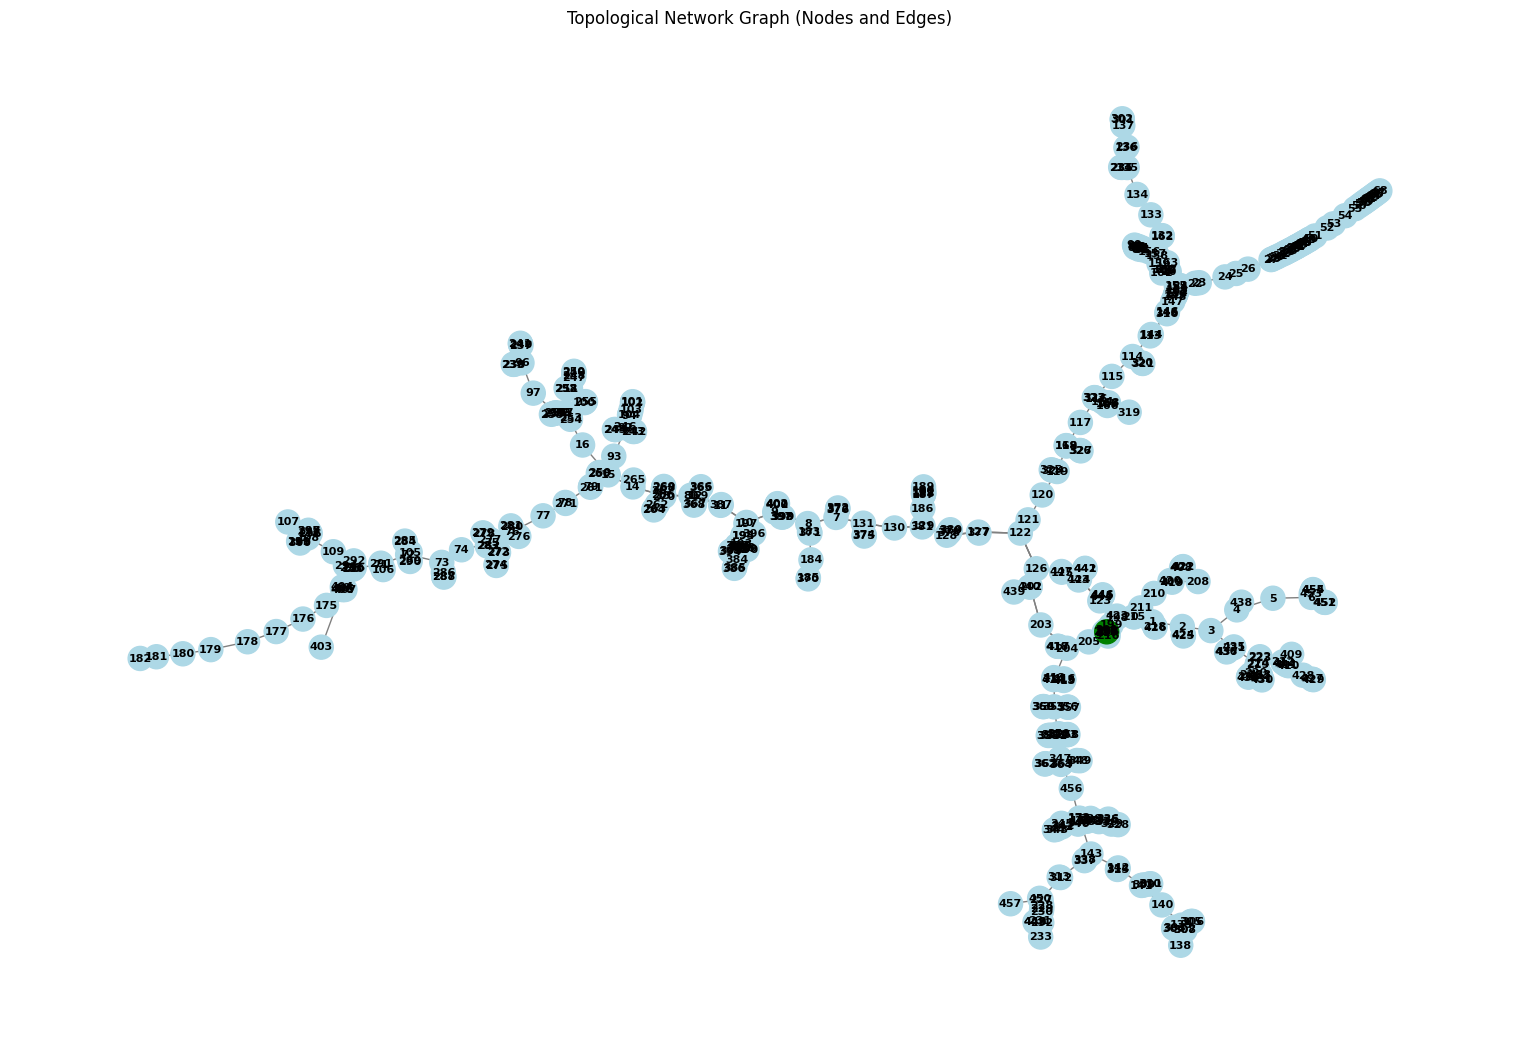

In [49]:
import matplotlib.pyplot as plt
import networkx as nx

# --- 6) Plot Topological Network Graph (Nodes & Edges) ---

if G.number_of_nodes() == 0:
    print("\n---  Cannot plot graph: Network is empty ---")
else:
    print(f"\n---  Plotting topological graph ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges) ---")

    # --- Highlight the Power Source (Ext. Grid) ---
    # Get the bus index for the external grid
    eg_bus = int(net.ext_grid.bus.iloc[0])

    # Create a color map: green for the source, lightblue for others
    node_colors = ['green' if node == eg_bus else 'lightblue' for node in G.nodes()]

    # --- Draw the graph ---
    plt.figure(figsize=(15, 10))

    # Use a layout to position nodes. 'spring_layout' is common.
    # 'kamada_kawai_layout' is often good for power grids.
    pos = nx.kamada_kawai_layout(G)

    nx.draw(
        G,
        pos,
        with_labels=True,     # Show the bus numbers
        node_color=node_colors,
        node_size=300,        # Size of the nodes
        font_size=8,          # Size of the labels
        font_weight='bold',
        edge_color='gray'
    )

    plt.title("Topological Network Graph (Nodes and Edges)")
    plt.show()

In [50]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import pandapower as pp
import pandapower.plotting as plot


# --- 1. Run Power Flow Calculation ---
try:
    pp.runpp(net)
    print("--- Power flow calculated successfully! ---")
    results_available = True
except Exception as e:
    print(f"--- An error occurred during the power flow calculation: {e} ---")
    results_available = False

--- Power flow calculated successfully! ---


In [51]:
net.load

,name,bus,p_mw,q_mvar,const_z_p_percent,const_i_p_percent,const_z_q_percent,const_i_q_percent,sn_mva,scaling,in_service,type
0,Load_1251855,234,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
1,Load_1251862,236,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
2,Load_1251344,239,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
3,Load_1455173,241,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
4,Load_1251162,242,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
...,...,...,...,...,...,...,...,...,...,...,...,...
140,Load_1251904,457,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
141,Load_5535042,450,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
142,Load_1238450,448,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
143,Load_1251631,452,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye


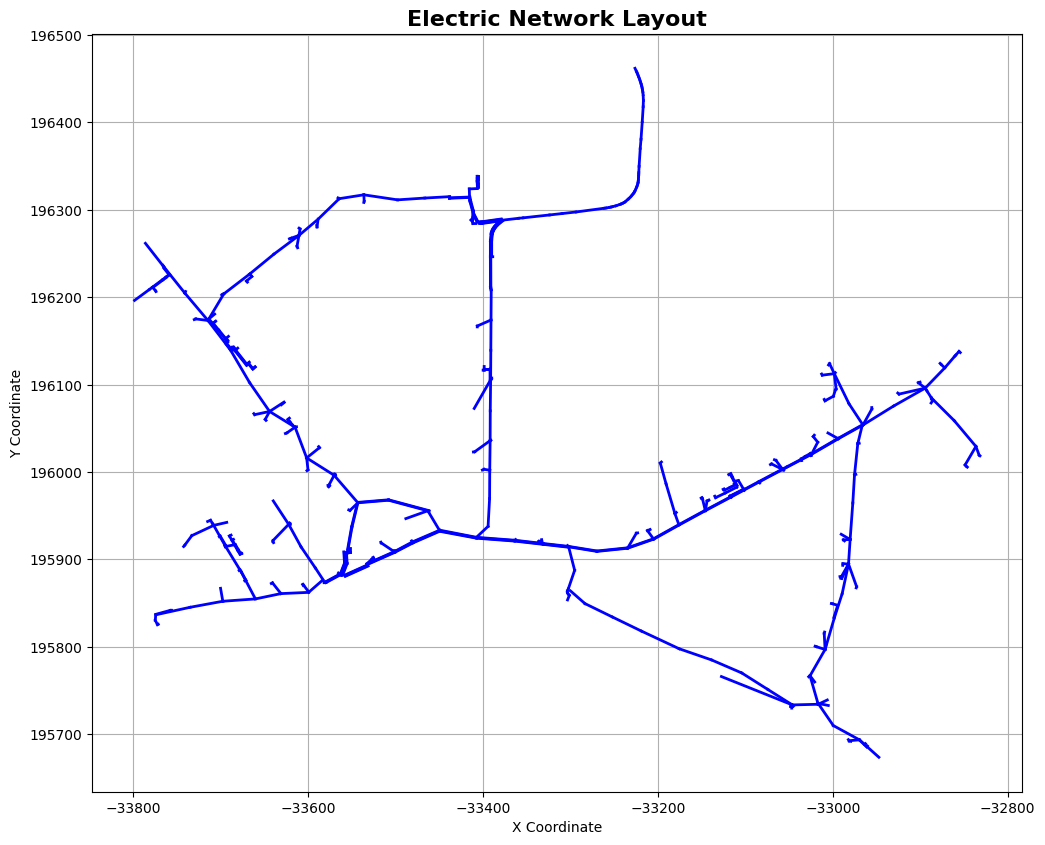

In [52]:
import matplotlib.pyplot as plt
import pandapower.plotting as plot
import numpy as np

# --- 1. Create the Figure ---
fig, ax = plt.subplots(figsize=(12, 12))

# --- 2. Manually Plot Each Line ---
for idx, line in net.line.iterrows():
    coords = net.line_geodata.loc[idx, 'coords']
    x, y = zip(*coords)
    ax.plot(x, y, color='blue', linewidth=2)

# --- 3. Plot the Buses (Nodes) ---

# 3a. Stage 1 Filter: Find valid shapely geometries
#geom_col = net.bus_geodata['geometry']
#is_valid_geom = (
#    geom_col.notnull() &
#    (geom_col.geom_type == 'Point') &
#    (~geom_col.is_empty)
#)
#valid_geom_idx = net.bus_geodata.index[is_valid_geom]

# 3b. Create 'x' and 'y' columns from the valid geometries
#     This step might still create NaN values if a point is "POINT (nan nan)"
#net.bus_geodata.loc[valid_geom_idx, 'x'] = net.bus_geodata.loc[valid_geom_idx, 'geometry'].x
#net.bus_geodata.loc[valid_geom_idx, 'y'] = net.bus_geodata.loc[valid_geom_idx, 'geometry'].y

# 3c. Stage 2 Filter (THE FIX):
#     Now, create a *new* list of buses by dropping any rows
#     from bus_geodata that have NaN in the 'x' or 'y' columns.
#valid_geo_data_final = net.bus_geodata.dropna(subset=['x', 'y'])
#valid_buses_with_geo = valid_geo_data_final.index

# (Optional Debug) See what was filtered
# print(f"Buses after geom filter: {len(valid_geom_idx)}")
# print(f"Buses after NaN filter: {len(valid_buses_with_geo)}")

# 3d. Plot using the *final, cleaned* list of buses.
#     The plotter will automatically use the 'x' and 'y' columns.
#bus_collection = plot.create_bus_collection(
#    net,
#    buses=valid_buses_with_geo,  # <-- This list is now guaranteed to have valid (x, y) pairs
#    size=2,
#    color="red",
#    zorder=10
#)

#plot.draw_collections([bus_collection], ax=ax)

# --- 4. Finalize and Show the Plot ---
ax.set_title("Electric Network Layout", fontsize=16, fontweight='bold')
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.grid(True)
ax.set_aspect('equal', adjustable='box')
plt.show()

In [53]:
net.load

,name,bus,p_mw,q_mvar,const_z_p_percent,const_i_p_percent,const_z_q_percent,const_i_q_percent,sn_mva,scaling,in_service,type
0,Load_1251855,234,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
1,Load_1251862,236,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
2,Load_1251344,239,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
3,Load_1455173,241,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
4,Load_1251162,242,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
...,...,...,...,...,...,...,...,...,...,...,...,...
140,Load_1251904,457,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
141,Load_5535042,450,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
142,Load_1238450,448,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye
143,Load_1251631,452,0.001,0.000329,0.0,0.0,0.0,0.0,NaN,1.0,True,wye


In [54]:
from pandapower.plotting.plotly import vlevel_plotly
import plotly.io as pio

# 1. Create the figure object first
fig = vlevel_plotly(net)

# 2. FIX: Update the layout of the figure object
fig.update_layout(width=700, height=600)

# 3. Now show the figure
pio.show(fig)

# Contracts

Diagrama de Carga PT009
Contratos PT009
backward forward sweep

In [55]:
import pandas as pd

excel_file_path = "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/Contratos PT009.xlsx"

try:
    contracts_df = pd.read_excel(excel_file_path, skiprows=2)

    print("--- Ficheiro Excel 'Contratos PT009.xlsx' lido com sucesso! ---")
    print(contracts_df.head())

except FileNotFoundError:
    print(f"ERRO: O ficheiro não foi encontrado no caminho: {excel_file_path}")
except Exception as e:
    print(f"Ocorreu um erro ao ler o ficheiro Excel: {e}")

--- Ficheiro Excel 'Contratos PT009.xlsx' lido com sucesso! ---
         Nº      Local Consumo Nº Estado Potência Contratada  \
0  CT003164  PT0008000000000437VN  Ativo             MONO6,9   
1  CT003240  PT0008000000000513CL  Ativo             TRI20,7   
2  CT003367  PT0008000000000640AP  Ativo              TRI6,9   
3  CT003607  PT0008000000000881JL  Ativo            MONO3,45   
4  CT004044  PT0008000000001318DL  Ativo             MONO6,9   

   Tipo Consumidor DGGE Tipo de Contrato                         Desc. Rua  \
0                     1          Consumo  Rua do Cruzeiro da Independência   
1                     4          Consumo                    Rua da Alegria   
2                     1          Consumo                     Rua da Gandra   
3                     1          Consumo                  Rua das Alminhas   
4                     1          Consumo                  Rua das Alminhas   

   Freguesia Area/Prédio PT Bloco  Bloco WGS Latitude  Bloco WGS Longitude  \
0   

In [56]:
import numpy as np

contracts_df['Potência Contratada'].unique()

# 1. Create the 'Tipo' column
# Checks if the string starts with 'MONO', if so, assigns 'MONO', otherwise 'TRI'
contracts_df['Tipo'] = np.where(
    contracts_df['Potência Contratada'].str.startswith('MONO'),
    'MONO',
    'TRI'
)

# 2. Create the 'Potência_Valor' column
# Replaces prefixes, then replaces the comma with a dot for decimal conversion
contracts_df['Potência_Valor'] = contracts_df['Potência Contratada'] \
    .str.replace('MONO', '', regex=False) \
    .str.replace('TRI', '', regex=False) \
    .str.replace(',', '.') \
    .astype(float)

# You can then check the result
print(contracts_df[['Potência Contratada', 'Tipo', 'Potência_Valor']].head())

  Potência Contratada  Tipo  Potência_Valor
0             MONO6,9  MONO            6.90
1             TRI20,7   TRI           20.70
2              TRI6,9   TRI            6.90
3            MONO3,45  MONO            3.45
4             MONO6,9  MONO            6.90


In [57]:
import geopandas as gpd
from shapely.geometry import Point

# Define the correct column names for latitude and longitude
lat_col = 'Bloco WGS Latitude'
lon_col = 'Bloco WGS Longitude'

# --- Data Cleaning ---
# Drop any rows where the latitude or longitude is missing
contracts_df.dropna(subset=[lat_col, lon_col], inplace=True)

# Ensure the coordinate columns are a numeric type, converting any errors to NaN
contracts_df[lat_col] = pd.to_numeric(contracts_df[lat_col], errors='coerce')
contracts_df[lon_col] = pd.to_numeric(contracts_df[lon_col], errors='coerce')

# Drop rows again in case the conversion created new NaNs
contracts_df.dropna(subset=[lat_col, lon_col], inplace=True)

# --- Create GeoDataFrame ---
# Convert the pandas DataFrame to a GeoDataFrame
# WGS84 (EPSG:4326) is the standard for latitude/longitude data
consumer_gdf = gpd.GeoDataFrame(
    contracts_df,
    geometry=gpd.points_from_xy(contracts_df[lon_col], contracts_df[lat_col]),
    crs="EPSG:4326"
)

#Project the consumer points to the same Coordinate Reference System (CRS)
# as the electrical network to ensure they align correctly on the map.
consumer_gdf = consumer_gdf.to_crs(lines_gdf.crs)

print(f"Successfully processed and prepared {len(consumer_gdf)} consumer locations for plotting.")

Successfully processed and prepared 140 consumer locations for plotting.


In [58]:
consumer_gdf

,Nº,Local Consumo Nº,Estado,Potência Contratada,Tipo Consumidor DGGE,Tipo de Contrato,Desc. Rua,Freguesia,Area/Prédio,PT Bloco,Bloco WGS Latitude,Bloco WGS Longitude,Data Caduc. Licença Construção,Nº Policia,Tipo Tarifário,Tarifário,Nº Série Contador,Tipo,Potência_Valor,geometry
0,CT003164,PT0008000000000437VN,Ativo,"MONO6,9",1,Consumo,Rua do Cruzeiro da Independência,31226,BL00427,PT009,41.43020,-8.52849,NaN,15,3TARBIH,"BTN BI-HOR 6,9 3T",ZIV2149701573,MONO,6.90,POINT (-33048.31 195730.653)
1,CT003240,PT0008000000000513CL,Ativo,"TRI20,7",4,Consumo,Rua da Alegria,31223,BL00499,PT009,41.43181,-8.53684,NaN,NaN,3TARSIMP,"BTN SIMP10,35 3TAR",ZIV2035620840,TRI,20.70,POINT (-33745.42 195912.685)
2,CT003367,PT0008000000000640AP,Ativo,"TRI6,9",1,Consumo,Rua da Gandra,31226,BL00619,PT009,41.43291,-8.52761,NaN,511,3TARBIH,"BTN BI-HOR 6,9 3T",ZIV2349823619,TRI,6.90,POINT (-32973.383 196031.298)
3,CT003607,PT0008000000000881JL,Ativo,"MONO3,45",1,Consumo,Rua das Alminhas,31226,BL00842,PT009,41.43096,-8.52807,NaN,240,3TARSIMP,"BTN SIMPLS 3,45 3TAR",ZIV2336983789,MONO,3.45,POINT (-33012.819 195814.901)
4,CT004044,PT0008000000001318DL,Ativo,"MONO6,9",1,Consumo,Rua das Alminhas,31226,BL01259,PT009,41.43050,-8.52828,NaN,300,3TARSIMP,"BTN SIMPLS 6,9 3TAR",ZIV1949693090,MONO,6.90,POINT (-33030.605 195763.892)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,CT033789,PT0008000000006557FZ,Ativo,"MONO3,45",2,Consumo,Avenida de Santa Lucrécia,31223,BL05823,PT009,41.43243,-8.53486,NaN,11,3TARSIMP,"BTN SIMPLS 3,45 3TAR",SAG1850000100,MONO,3.45,POINT (-33579.604 195980.774)
136,CT033926,PT0008000000004823RM,Ativo,"MONO6,9",1,Consumo,Rua da Alegria,31223,BL04357,PT009,41.43157,-8.53608,NaN,3,3TARSIMP,"BTN SIMPLS 6,9 3TAR",SAG1750205925,MONO,6.90,POINT (-33682.02 195885.734)
137,CT034036,PT0008000000018134GE,Ativo,"TRI6,9",1,Consumo,Rua das Alminhas,31226,BL08822,PT009,41.43190,-8.52780,NaN,130,3TARSIMP,"BTN SIMPLS 6,9 3TAR",ZIV2035620602,TRI,6.90,POINT (-32989.775 195919.197)
138,CTMP00033,PT0008000000005836EY,Ativo,"MONO3,68",1,Produção,Rua Padre Domingos Joaquim Pereira,31223,BL05309,PT009,41.43101,-8.53719,NaN,1060,MICRO,MICRO2010,51019113,MONO,3.68,POINT (-33775.089 195823.971)


In [59]:
pee_gdf

,Designação,Tipo,Número de clientes alimentados,Gerador de emergência,Microprodução?,Situação,Data de entrada em serviço,Observações,Tensão de Serviço,Blocos,...,Id,Produtor Central,Subestacao Cliente,Subestacao Cliente.1,X [m]/Long(º),Y [m]/Lat(º),Freguesia,Concelho,PT/PTS,geometry
0,NaN,Contador,unset,Não,unset,Em exploração,unset,009-048,BT,(1),...,1251855,NaN,NaN,unset,-33536.176,196308.309,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33536.176 196308.309)
1,NaN,Contador,unset,Não,unset,Em exploração,unset,009-047,BT,(1),...,1251862,NaN,NaN,unset,-33565.752,196313.506,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33565.752 196313.506)
2,NaN,Contador,unset,Não,unset,Em exploração,unset,009-126,BT,(1),...,1251344,NaN,NaN,unset,-32832.221,196017.767,MOUQUIM,Vila Nova de Famalicão,031223D20009,POINT (-32832.221 196017.767)
3,NaN,Contador,unset,Não,unset,Em exploração,unset,009-161,BT,(1),...,1455173,NaN,NaN,unset,-32846.090,196005.625,MOUQUIM,Vila Nova de Famalicão,031223D20009,POINT (-32846.09 196005.625)
4,NaN,Contador,unset,Não,unset,Em exploração,unset,009-163,BT,(1),...,1251162,NaN,NaN,unset,-33004.793,196122.439,MOUQUIM,Vila Nova de Famalicão,031223D20009,POINT (-33004.793 196122.439)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,NaN,Contador,unset,Não,unset,Em exploração,unset,009-038,BT,(1),...,1251904,NaN,NaN,unset,-33784.403,196263.124,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33784.403 196263.124)
141,NaN,Contador,unset,Não,unset,Em exploração,unset,009-174,BT,(1),...,5535042,NaN,NaN,unset,-33766.512,196237.046,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33766.512 196237.046)
142,NaN,Contador,unset,Não,unset,Em exploração,unset,009-162,BT,(1),...,1238450,NaN,NaN,unset,-33773.907,196206.399,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33773.907 196206.399)
143,NaN,Contador,unset,Não,unset,Em exploração,unset,009-079,BT,(1),...,1251631,NaN,NaN,unset,-33756.053,195841.888,LOURO,Vila Nova de Famalicão,031223D20009,POINT (-33756.053 195841.888)


In [60]:
print("--- Line Geodata Head ---")
print(net.line_geodata.head())
empty_coords = net.line_geodata['coords'].apply(lambda x: x is None or len(x) == 0).sum()
print(f"\n{empty_coords} lines have empty coordinates.")

--- Line Geodata Head ---
                                              coords
0  [(-33583.17, 195876.499), (-33599.344, 195862....
1  [(-33599.344, 195862.397), (-33630.991, 195860...
2  [(-33630.991, 195860.993), (-33660.174, 195854...
3  [(-33660.174, 195854.909), (-33697.467, 195852...
4  [(-33697.467, 195852.245), (-33735.049, 195845...

0 lines have empty coordinates.


In [61]:
print("--- Unique Contract Names in GDF ---")
print(consumer_gdf['Tipo de Contrato'].unique())
print("\n--- Color Map Being Used ---")
print(color_map)

--- Unique Contract Names in GDF ---
['Consumo' 'Produção']

--- Color Map Being Used ---
{'Apoios BT': 'gray', 'Coluna IP': 'darkgray', 'Braco IP': 'lightgray', 'Ponto de Entrega de Energia_PEE': 'red', 'Caixa_Armario': 'orange', 'Posto de Transformacao_PT_PTS': 'purple', 'Caixa de Visita': 'brown', 'Troco BT PT09': 'blue'}


In [62]:
print("--- Consumer GDF Head ---")
print(consumer_gdf.head())

# Check how many consumers have valid, non-empty geometries
valid_geos = consumer_gdf.geometry.notna().sum()
print(f"\n{valid_geos} consumers have valid geometry.")
print(f"{len(consumer_gdf)} consumers total.")

--- Consumer GDF Head ---
         Nº      Local Consumo Nº Estado Potência Contratada  \
0  CT003164  PT0008000000000437VN  Ativo             MONO6,9   
1  CT003240  PT0008000000000513CL  Ativo             TRI20,7   
2  CT003367  PT0008000000000640AP  Ativo              TRI6,9   
3  CT003607  PT0008000000000881JL  Ativo            MONO3,45   
4  CT004044  PT0008000000001318DL  Ativo             MONO6,9   

   Tipo Consumidor DGGE Tipo de Contrato                         Desc. Rua  \
0                     1          Consumo  Rua do Cruzeiro da Independência   
1                     4          Consumo                    Rua da Alegria   
2                     1          Consumo                     Rua da Gandra   
3                     1          Consumo                  Rua das Alminhas   
4                     1          Consumo                  Rua das Alminhas   

   Freguesia Area/Prédio PT Bloco  Bloco WGS Latitude  Bloco WGS Longitude  \
0      31226     BL00427    PT009         

In [63]:
print("--- Line Index Check ---")
print(f"net.line index:      {net.line.index[:5].values}")
print(f"net.line_geodata index: {net.line_geodata.index[:5].values}")

# Check for a match on the first ID
first_line_id = net.line.index[0]
print(f"\nIs first line ID ({first_line_id}) in net.line_geodata index? ", end="")
print(first_line_id in net.line_geodata.index)

--- Line Index Check ---
net.line index:      [0 1 2 3 4]
net.line_geodata index: [0 1 2 3 4]

Is first line ID (0) in net.line_geodata index? True


--- Color mapping for contracts ---
{'Consumo': 'gold', 'Produção': 'red'}
Plot limits set to: X=(np.float64(-33835.72412708761), np.float64(-32787.90971630039)), Y=(np.float64(195653.3845454832), np.float64(196343.04624526956))


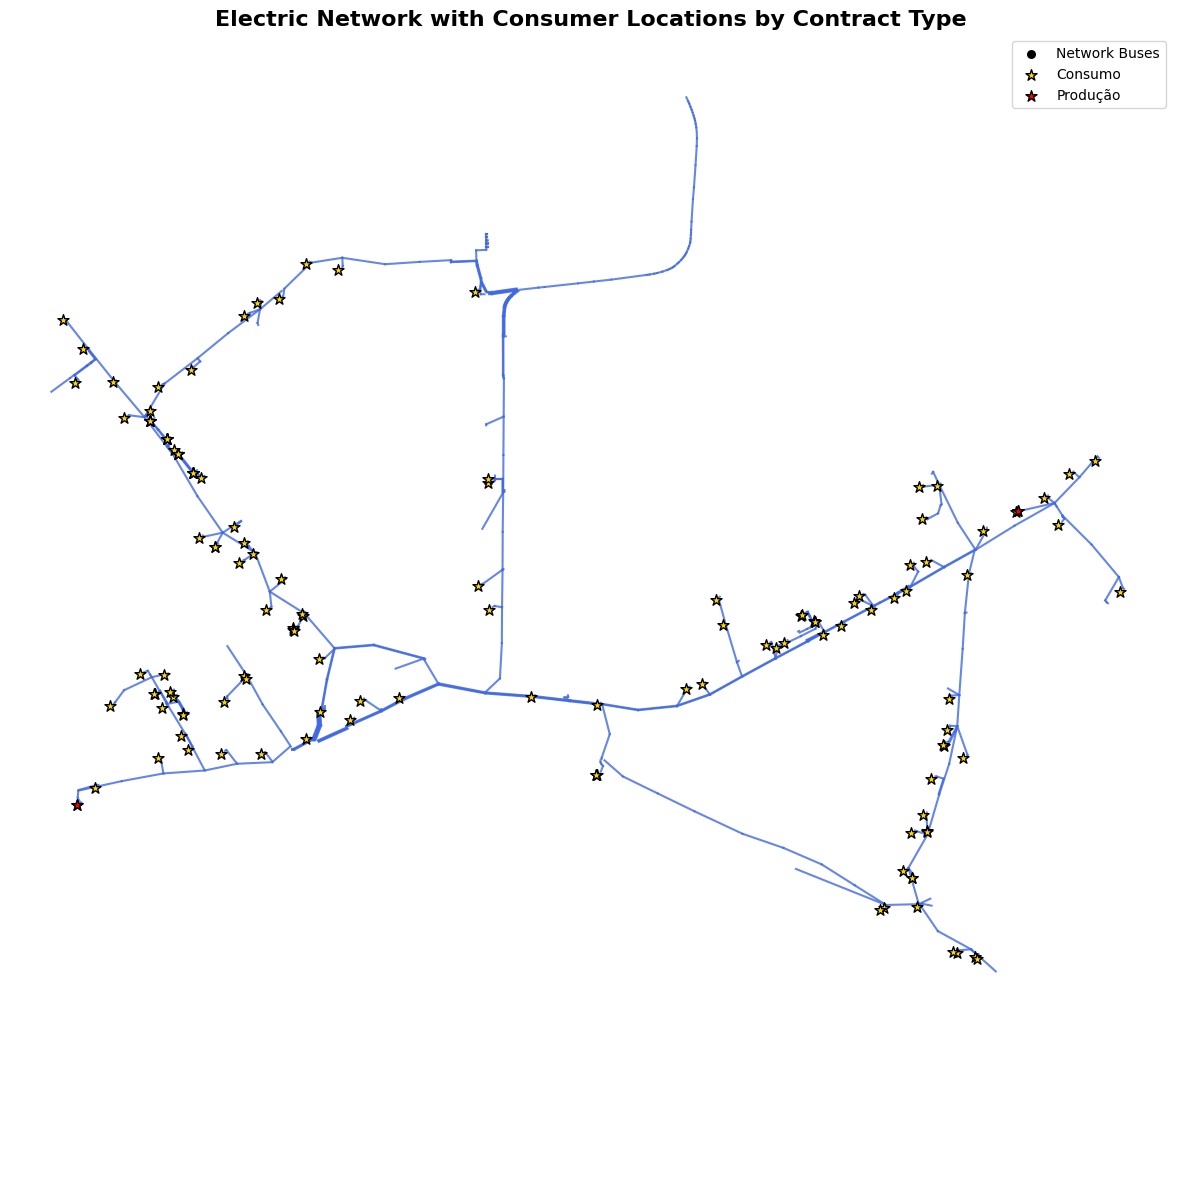

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import pandapower.plotting as plot

fixed_map = {'Consumo': 'gold', 'Produção': 'red'}
palette = ['magenta', 'green', 'orange', 'purple', 'brown', 'dodgerblue', 'olive', 'teal']

labels = pd.Series(consumer_gdf['Tipo de Contrato'].dropna().unique())
auto_labels = [l for l in labels if l not in fixed_map]
auto_map = {lbl: palette[i % len(palette)] for i, lbl in enumerate(auto_labels)}
color_map = {**fixed_map, **auto_map}

print('--- Color mapping for contracts ---')
print(color_map)

if "geo" in net.bus:
    valid_buses = net.bus.index[net.bus["geo"].notna()]
else:
    valid_buses = pd.Index([])


fig, ax = plt.subplots(figsize=(15, 15))


# [minX, minY, maxX, maxY]
try:
    bounds = consumer_gdf.total_bounds

    #  (buffer) 5%
    x_margin = (bounds[2] - bounds[0]) * 0.05
    y_margin = (bounds[3] - bounds[1]) * 0.05

    # set  xx limits before
    ax.set_xlim(bounds[0] - x_margin, bounds[2] + x_margin)
    ax.set_ylim(bounds[1] - y_margin, bounds[3] + y_margin)
    print(f"Plot limits set to: X={ax.get_xlim()}, Y={ax.get_ylim()}")

except Exception as e:
    print(f"Warning: Could not set plot bounds automatically. {e}")

# Linhas
for idx, _ in net.line.iterrows():
    if idx not in net.line_geodata.index:
        continue
    coords = net.line_geodata.at[idx, 'coords']
    if not coords:
        continue
    x, y = zip(*coords)
    ax.plot(x, y, color='royalblue', linewidth=1.5, alpha=0.8, zorder=1, label='_nolegend_')

# (Buses)
if len(valid_buses):
    bc = plot.create_bus_collection(net, buses=valid_buses, size=1, color="black", zorder=2)
    plot.draw_collections([bc], ax=ax)
    ax.scatter([], [], s=30, color='black', label='Network Buses')

# Consumidores por tipo de contrato
for contract_type, color in color_map.items():
    sub = consumer_gdf[consumer_gdf['Tipo de Contrato'] == contract_type]
    if not sub.empty:
        sub.plot(ax=ax, marker='*', color=color, markersize=70,
                 edgecolor='black', zorder=3, label=f'{contract_type}')

ax.set_title("Electric Network with Consumer Locations by Contract Type", fontsize=16, fontweight='bold')
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.grid(True)
ax.legend()
ax.set_aspect('equal', adjustable='box')
plt.show()

# Matching contract with PEE

In [65]:
import pandas as pd
import geopandas as gpd

# --- Define serial_matched_idx ---
meter_assets = pee_gdf[pee_gdf["Tipo"] == "Contador"]
meter_serials = set(meter_assets["Designação"].dropna())
serial_matched_idx = consumer_gdf[consumer_gdf["Nº Série Contador"].isin(meter_serials)].index

print(f"Found {len(serial_matched_idx)} serial number matches.")

# 1) Nearest join with explicit suffixes
nearest_all = gpd.sjoin_nearest(
    consumer_gdf,
    pee_gdf,
    how="left",
    distance_col="meter_distance_m",
    max_distance=10,
    lsuffix="cons",
    rsuffix="meter",
)

# 2) Serial match flag (left index)
nearest_all["_cons_idx"] = nearest_all.index
nearest_all["serial_match"] = nearest_all["_cons_idx"].isin(serial_matched_idx)

# 3) Column pickers (handle suffixed/unsuffixed names)
def pick_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    print(f"Warning: None of {candidates} found in DataFrame.")
    return None

contract_cols = [
    pick_existing(nearest_all, ["Nºcons", "Nº"]),
    pick_existing(nearest_all, ["Local Consumo Nºcons", "Local Consumo Nº"]),
    pick_existing(nearest_all, ["Nº Série Contadorcons", "Nº Série Contador"]),
    pick_existing(nearest_all, ["Tipo de Contratocons", "Tipo de Contrato"]),


    pick_existing(nearest_all, ["Tipocons", "Tipo"]), # For the new MONO/TRI column
    pick_existing(nearest_all, ["Potência_Valorcons", "Potência_Valor"]), # For the new numeric power


    pick_existing(nearest_all, ["PT Blococons", "PT Bloco"]),
    pick_existing(nearest_all, ["_PTCODEcons", "_PTCODE"]),
]
contract_cols = [c for c in contract_cols if c]

meter_id_col = pick_existing(nearest_all, ["Idmeter", "Designaçãometer", "Id", "Designação"])
meter_cols = [
    meter_id_col,
    pick_existing(nearest_all, ["Tipometer", "Tipo"]),
    pick_existing(nearest_all, ["Situaçãometer", "Situação"]),
    pick_existing(nearest_all, ["_PTCODEmeter", "_PTCODE_right", "_PTCODE"]),
]
meter_cols = [c for c in meter_cols if c]

# 4) Build tidy output
select_cols = ["geometry"] + contract_cols + meter_cols + ["meter_distance_m", "serial_match"]
select_cols = [c for c in select_cols if c in nearest_all.columns]
matches_gdf = nearest_all[select_cols].copy()

# 5) Rename consistently
rename_map = {
    # Renames from contract_cols (consumer_gdf)
    "Nºcons": "contract_n", "Nº": "contract_n",
    "Local Consumo Nºcons": "contract_local_n", "Local Consumo Nº": "contract_local_n",
    "Nº Série Contadorcons": "contract_serial", "Nº Série Contador": "contract_serial",
    "Tipo de Contratocons": "contract_type", "Tipo de Contrato": "contract_type",
    "PT Blococons": "contract_ptblock", "PT Bloco": "contract_ptblock",
    "_PTCODEcons": "contract_ptcode", "_PTCODE": "contract_ptcode",

    # We put them *before* the meter renames
    "Tipocons": "contract_potencia_tipo", # Renames the suffixed 'Tipo' from consumer_gdf
    "Potência_Valorcons": "contract_potencia_valor", # Renames the suffixed 'Potência_Valor'
    "Potência_Valor": "contract_potencia_valor", # Fallback for un-suffixed

    # Renames from meter_cols (pee_gdf)
    "Tipometer": "meter_type", "Tipo": "meter_type", # This will correctly handle the 'Tipo' from pee_gdf
    "Situaçãometer": "meter_situation", "Situação": "meter_situation",
    "_PTCODEmeter": "meter_ptcode", "_PTCODE_right": "meter_ptcode",
}
if meter_id_col:
    rename_map[meter_id_col] = "meter_id"

existing_rename_map = {k: v for k, v in rename_map.items() if k in matches_gdf.columns}
matches_gdf.rename(columns=existing_rename_map, inplace=True)


# 6) Quality buckets + safe 'serial' assignment
matches_gdf["match_quality"] = pd.cut(
    matches_gdf["meter_distance_m"],
    bins=[-1, 2, 5, 10],
    labels=["excellent (≤2m)", "good (≤5m)", "ok (≤10m)"]
)

matches_gdf["serial_match"] = matches_gdf["serial_match"].fillna(False).astype(bool)

# 1. Add "serial" as a valid category to the existing categorical column
if isinstance(matches_gdf["match_quality"].dtype, pd.CategoricalDtype):
    matches_gdf["match_quality"] = matches_gdf["match_quality"].cat.add_categories(["serial"])

# 2. assign "serial" as a value where matches_gdf["serial_match"] is True
matches_gdf.loc[matches_gdf["serial_match"], "match_quality"] = "serial"

# 3. Recast the column as an ordered Categorical
matches_gdf["match_quality"] = pd.Categorical(
    matches_gdf["match_quality"],
    categories=["serial", "excellent (≤2m)", "good (≤5m)", "ok (≤10m)"],
    ordered=True,
)

print(f"Matched {len(matches_gdf)} contracts to meters.")

# 7) --- Deduplicate to enforce "one contract per bus" ---
# This fixes the "138 vs 108" problem based on new rule.
# We pick the "best" contract for each bus.
# "Best" is: 1st) Serial Match, 2nd) Closest distance

if 'bus_idx' in matches_gdf.columns:
    print(f"\nFound {len(matches_gdf)} total matches before deduplication.")

    # 1. Sort by "best" match: Serial match is best, then distance
    matches_gdf = matches_gdf.sort_values(
        by=["serial_match", "meter_distance_m"],
        ascending=[False, True] # serial_match (True) first, then meter_distance_m (lowest) first
    )

    # 2. This line drops all duplicates for each bus
    #    and keeps ONLY the "best" one (the first one)
    matches_gdf = matches_gdf.drop_duplicates(subset=['bus_idx'], keep='first')

    print(f"Kept {len(matches_gdf)} contracts after deduplicating by bus.")
else:
    print("Warning: 'bus_idx' column not found. Skipping deduplication.")

# --- Build map Load_<meter_id> -> load index in pandapower ---
# This assumes 'net' (the pandapower network) is defined and has loads
if 'net' in locals() or 'net' in globals():
    try:
        # Get all load names and strip the 'Load_' prefix
        cleaned_ids = net.load['name'].astype(str).str.replace('Load_', '', regex=False)

        # Create a dictionary mapping the cleaned ID (e.g., meter ID) to the pandapower load index
        load_id_map = pd.Series(net.load.index, index=cleaned_ids).to_dict()

        # Map each contract's 'meter_id' to its corresponding pandapower 'load_idx'
        # Replaced 'loads_to_update' with 'matches_gdf'
        matches_gdf['load_idx'] = matches_gdf['meter_id'].astype(str).map(load_id_map)

        # Print a summary of the mapping
        mapped_count = matches_gdf['load_idx'].notna().sum()
        total_contracts = len(matches_gdf)
        print(f"Successfully mapped {mapped_count} out of {total_contracts} contracts to pandapower load indices.")

        # You can now see which contracts have a pandapower load index
        # print(matches_gdf[['contract_n', 'meter_id', 'load_idx', 'match_quality']].head())

    except AttributeError as e:
        print(f"Error mapping loads: 'net' object might be missing 'load' table or 'name' column. Error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred during load mapping: {e}")
else:
    print("Warning: 'net' (pandapower network) not found. Skipping pandapower load mapping.")

Found 0 serial number matches.
Matched 140 contracts to meters.
Successfully mapped 140 out of 140 contracts to pandapower load indices.


In [66]:
import pandas as pd
import geopandas as gpd

print("Starting contract matching...")

# 1) Nearest join with explicit suffixes
nearest_all = gpd.sjoin_nearest(
    consumer_gdf,
    pee_gdf,
    how="left",
    distance_col="meter_distance_m",
    max_distance=10,
    lsuffix="cons",
    rsuffix="meter",
)

# 2) Column pickers
def pick_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    print(f"Warning: None of {candidates} found in DataFrame.")
    return None

# Do NOT fall back to "Designação" (serial number)
meter_id_col = pick_existing(nearest_all, ["Idmeter", "Id"])
if not meter_id_col:
    print("CRITICAL ERROR: Could not find 'Idmeter' or 'Id' from pee_gdf.")


contract_cols = [
    pick_existing(nearest_all, ["Tipo de Contratocons", "Tipo de Contrato"]),
    pick_existing(nearest_all, ["Potência_Valorcons", "Potência_Valor"]),
]
contract_cols = [c for c in contract_cols if c]

meter_cols = [
    meter_id_col,
]
meter_cols = [c for c in meter_cols if c]

# 3) Build tidy output (Removed 'serial_match')
select_cols = ["geometry"] + contract_cols + meter_cols + ["meter_distance_m"]
select_cols = [c for c in select_cols if c in nearest_all.columns]
matches_gdf = nearest_all[select_cols].copy()
print(f"Found {len(matches_gdf)} initial geospatial matches.")

# 4) Rename consistently
rename_map = {
    "Tipo de Contratocons": "contract_type", "Tipo de Contrato": "contract_type",
    "Potência_Valorcons": "contract_potencia_valor", "Potência_Valor": "contract_potencia_valor",
}
if meter_id_col:
    rename_map[meter_id_col] = "meter_id"

existing_rename_map = {k: v for k, v in rename_map.items() if k in matches_gdf.columns}
matches_gdf.rename(columns=existing_rename_map, inplace=True)

# 5) Map to pandapower bus_idx
if 'net' in locals() or 'net' in globals():
    try:
        # Create a map from 'meter_id' -> 'bus_idx'
        cleaned_names = net.load['name'].astype(str).str.replace('Load_', '', regex=False).str.strip()
        load_id_to_bus = pd.Series(net.load['bus'].values, index=cleaned_names).to_dict()

        # Map a new 'bus_idx' column
        matches_gdf['bus_idx'] = matches_gdf['meter_id'].astype(str).map(load_id_to_bus)

        mapped_bus_count = matches_gdf['bus_idx'].notna().sum()
        print(f"Successfully mapped {mapped_bus_count} contracts to a bus_idx.")

    except Exception as e:
        print(f"An unexpected error occurred during bus mapping: {e}")
else:
    print("Warning: 'net' (pandapower network) not found. Skipping pandapower bus mapping.")


# 6) Final Quality Buckets
matches_gdf["match_quality"] = pd.cut(
    matches_gdf["meter_distance_m"],
    bins=[-1, 2, 5, 10],
    labels=["excellent (≤2m)", "good (≤5m)", "ok (≤10m)"]
)

# Recast the column as an ordered Categorical
matches_gdf["match_quality"] = pd.Categorical(
    matches_gdf["match_quality"],
    categories=["excellent (≤2m)", "good (≤5m)", "ok (≤10m)"], # (Removed "serial")
    ordered=True,
)

print(f"\nFinal 'matches_gdf' has {len(matches_gdf)} contracts ready for update (duplicates included).")

# 7) Final check for load_idx (for your *next* script, 'update_network.py')
if 'net' in locals() or 'net' in globals():
    try:
        cleaned_ids = net.load['name'].astype(str).str.replace('Load_', '', regex=False)
        load_id_map = pd.Series(net.load.index, index=cleaned_ids).to_dict()
        matches_gdf['load_idx'] = matches_gdf['meter_id'].astype(str).map(load_id_map)
        print(f"Successfully mapped {matches_gdf['load_idx'].notna().sum()} final contracts to a load_idx.")
    except Exception as e:
        print(f"Error during final load_idx mapping: {e}")

print("\nMatching script complete.")

Starting contract matching...
Found 140 initial geospatial matches.
Successfully mapped 140 contracts to a bus_idx.

Final 'matches_gdf' has 140 contracts ready for update (duplicates included).
Successfully mapped 140 final contracts to a load_idx.

Matching script complete.


In [67]:
matches_gdf

,geometry,contract_type,contract_potencia_valor,meter_id,meter_distance_m,bus_idx,match_quality,load_idx
0,POINT (-33048.31 195730.653),Consumo,6.90,1239374,1.527596,406,excellent (≤2m),106
1,POINT (-33745.42 195912.685),Consumo,20.70,1251687,3.831026,429,good (≤5m),123
2,POINT (-32973.383 196031.298),Consumo,6.90,1251379,4.025264,261,good (≤5m),16
3,POINT (-33012.819 195814.901),Consumo,3.45,1251253,4.076285,285,good (≤5m),29
4,POINT (-33030.605 195763.892),Consumo,6.90,1251232,3.706672,291,good (≤5m),33
...,...,...,...,...,...,...,...,...
135,POINT (-33579.604 195980.774),Consumo,3.45,1251617,4.042502,415,good (≤5m),111
136,POINT (-33682.02 195885.734),Consumo,6.90,1251659,3.634671,435,good (≤5m),131
137,POINT (-32989.775 195919.197),Consumo,6.90,1242909,3.856943,281,good (≤5m),23
138,POINT (-33775.089 195823.971),Produção,3.68,1251638,4.319174,455,good (≤5m),144


In [68]:
# 1. Get a set of all cleaned IDs from net.load
# (We strip whitespace and convert to string)
all_net_load_ids = set(
    net.load['name'].str.replace('Load_', '', regex=False)
    .str.strip()
    #.dropna()
    .astype(str)
)

# 2. Get a set of all 'Consumo' meter IDs from matches_gdf
# (We convert to string FIRST, then strip whitespace)
all_consumo_meter_ids = set(
   matches_gdf[matches_gdf['contract_type'] == 'Consumo']['meter_id']
    #.dropna()
    .astype(str)
    .str.strip()
)

# 3. Find the differences
loads_without_contract = all_net_load_ids.difference(all_consumo_meter_ids)
contracts_without_load = all_consumo_meter_ids.difference(all_net_load_ids)


print(f"\n--- ID MISMATCH DEBUG ---")

print(f"Found {len(loads_without_contract)} load IDs in net.load that did NOT match a contract:")
if len(loads_without_contract) > 0:
    # Print the first 10 as an example
    print(list(loads_without_contract)[:10])

print(f"\nFound {len(contracts_without_load)} 'Consumo' contract IDs that did NOT match a load:")
if len(contracts_without_load) > 0:
    # Print the first 10 as an example
    print(list(contracts_without_load)[:10])


--- ID MISMATCH DEBUG ---
Found 37 load IDs in net.load that did NOT match a contract:
['1251750', '6227243', '1251813', '1251841', '6166349', '1251463', '1251183', '1251302', '1251526', '6447480']

Found 0 'Consumo' contract IDs that did NOT match a load:


In [69]:
matches_gdf

,geometry,contract_type,contract_potencia_valor,meter_id,meter_distance_m,bus_idx,match_quality,load_idx
0,POINT (-33048.31 195730.653),Consumo,6.90,1239374,1.527596,406,excellent (≤2m),106
1,POINT (-33745.42 195912.685),Consumo,20.70,1251687,3.831026,429,good (≤5m),123
2,POINT (-32973.383 196031.298),Consumo,6.90,1251379,4.025264,261,good (≤5m),16
3,POINT (-33012.819 195814.901),Consumo,3.45,1251253,4.076285,285,good (≤5m),29
4,POINT (-33030.605 195763.892),Consumo,6.90,1251232,3.706672,291,good (≤5m),33
...,...,...,...,...,...,...,...,...
135,POINT (-33579.604 195980.774),Consumo,3.45,1251617,4.042502,415,good (≤5m),111
136,POINT (-33682.02 195885.734),Consumo,6.90,1251659,3.634671,435,good (≤5m),131
137,POINT (-32989.775 195919.197),Consumo,6.90,1242909,3.856943,281,good (≤5m),23
138,POINT (-33775.089 195823.971),Produção,3.68,1251638,4.319174,455,good (≤5m),144


In [70]:
duplicates = matches_gdf[matches_gdf['meter_id'].duplicated(keep=False)].sort_values('meter_id')

print(duplicates)

                          geometry contract_type  contract_potencia_valor  \
35   POINT (-33709.114 196170.187)       Consumo                     6.90   
71   POINT (-33709.114 196170.187)       Consumo                     3.45   
67   POINT (-33709.114 196170.187)       Consumo                     6.90   
50   POINT (-33709.114 196170.187)       Consumo                     6.90   
133  POINT (-33709.114 196170.187)       Consumo                     6.90   
57   POINT (-33694.147 196153.457)       Consumo                     6.90   
70   POINT (-33694.147 196153.457)       Consumo                     3.45   
38   POINT (-33694.147 196153.457)       Consumo                     6.90   
102  POINT (-33694.147 196153.457)       Consumo                     6.90   
122  POINT (-33694.147 196153.457)       Consumo                     3.45   
72    POINT (-33684.18 196140.083)       Consumo                     3.45   
36    POINT (-33684.18 196140.083)       Consumo                     6.90   

In [71]:
len(all_consumo_meter_ids)

108

In [72]:
matches_gdf

,geometry,contract_type,contract_potencia_valor,meter_id,meter_distance_m,bus_idx,match_quality,load_idx
0,POINT (-33048.31 195730.653),Consumo,6.90,1239374,1.527596,406,excellent (≤2m),106
1,POINT (-33745.42 195912.685),Consumo,20.70,1251687,3.831026,429,good (≤5m),123
2,POINT (-32973.383 196031.298),Consumo,6.90,1251379,4.025264,261,good (≤5m),16
3,POINT (-33012.819 195814.901),Consumo,3.45,1251253,4.076285,285,good (≤5m),29
4,POINT (-33030.605 195763.892),Consumo,6.90,1251232,3.706672,291,good (≤5m),33
...,...,...,...,...,...,...,...,...
135,POINT (-33579.604 195980.774),Consumo,3.45,1251617,4.042502,415,good (≤5m),111
136,POINT (-33682.02 195885.734),Consumo,6.90,1251659,3.634671,435,good (≤5m),131
137,POINT (-32989.775 195919.197),Consumo,6.90,1242909,3.856943,281,good (≤5m),23
138,POINT (-33775.089 195823.971),Produção,3.68,1251638,4.319174,455,good (≤5m),144


In [73]:
 matches_gdf[matches_gdf['contract_type'] == 'Produção']

,geometry,contract_type,contract_potencia_valor,meter_id,meter_distance_m,bus_idx,match_quality,load_idx
138,POINT (-33775.089 195823.971),Produção,3.68,1251638,4.319174,455,good (≤5m),144
139,POINT (-32927.15 196088.841),Produção,3.68,1251365,2.183075,255,good (≤5m),10


In [74]:
 matches_gdf[matches_gdf['contract_type'] == 'Consumo']

,geometry,contract_type,contract_potencia_valor,meter_id,meter_distance_m,bus_idx,match_quality,load_idx
0,POINT (-33048.31 195730.653),Consumo,6.90,1239374,1.527596,406,excellent (≤2m),106
1,POINT (-33745.42 195912.685),Consumo,20.70,1251687,3.831026,429,good (≤5m),123
2,POINT (-32973.383 196031.298),Consumo,6.90,1251379,4.025264,261,good (≤5m),16
3,POINT (-33012.819 195814.901),Consumo,3.45,1251253,4.076285,285,good (≤5m),29
4,POINT (-33030.605 195763.892),Consumo,6.90,1251232,3.706672,291,good (≤5m),33
...,...,...,...,...,...,...,...,...
133,POINT (-33709.114 196170.187),Consumo,6.90,1203037,4.276611,336,good (≤5m),62
134,POINT (-33580.435 195981.888),Consumo,3.45,1251617,4.130259,415,good (≤5m),111
135,POINT (-33579.604 195980.774),Consumo,3.45,1251617,4.042502,415,good (≤5m),111
136,POINT (-33682.02 195885.734),Consumo,6.90,1251659,3.634671,435,good (≤5m),131


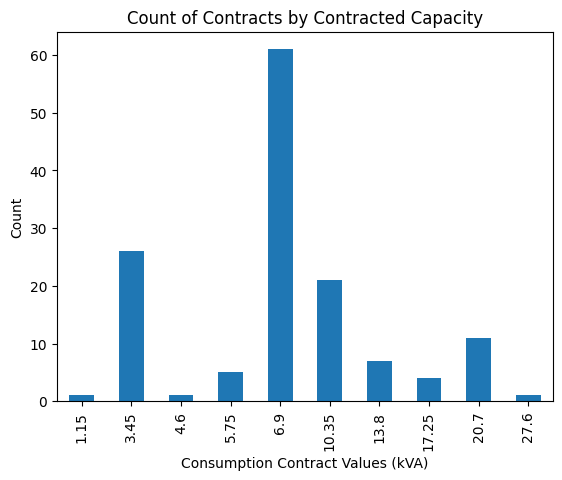

In [89]:
# Filter and Plot in one go
# Filter, Count unique values, and Plot
matches_gdf[matches_gdf['contract_type'] == 'Consumo']['contract_potencia_valor'].value_counts().sort_index().plot(kind='bar', title="Count of Contracts by Contracted Capacity")

plt.xlabel("Consumption Contract Values (kVA)")
plt.ylabel("Count")
plt.show()


--- Generating Combined Plot ---
Plotting base infrastructure layers...
Plotting contract layers...
Plotted 138 'Consumo' contracts.
Plotted 2 'Produção' contracts.


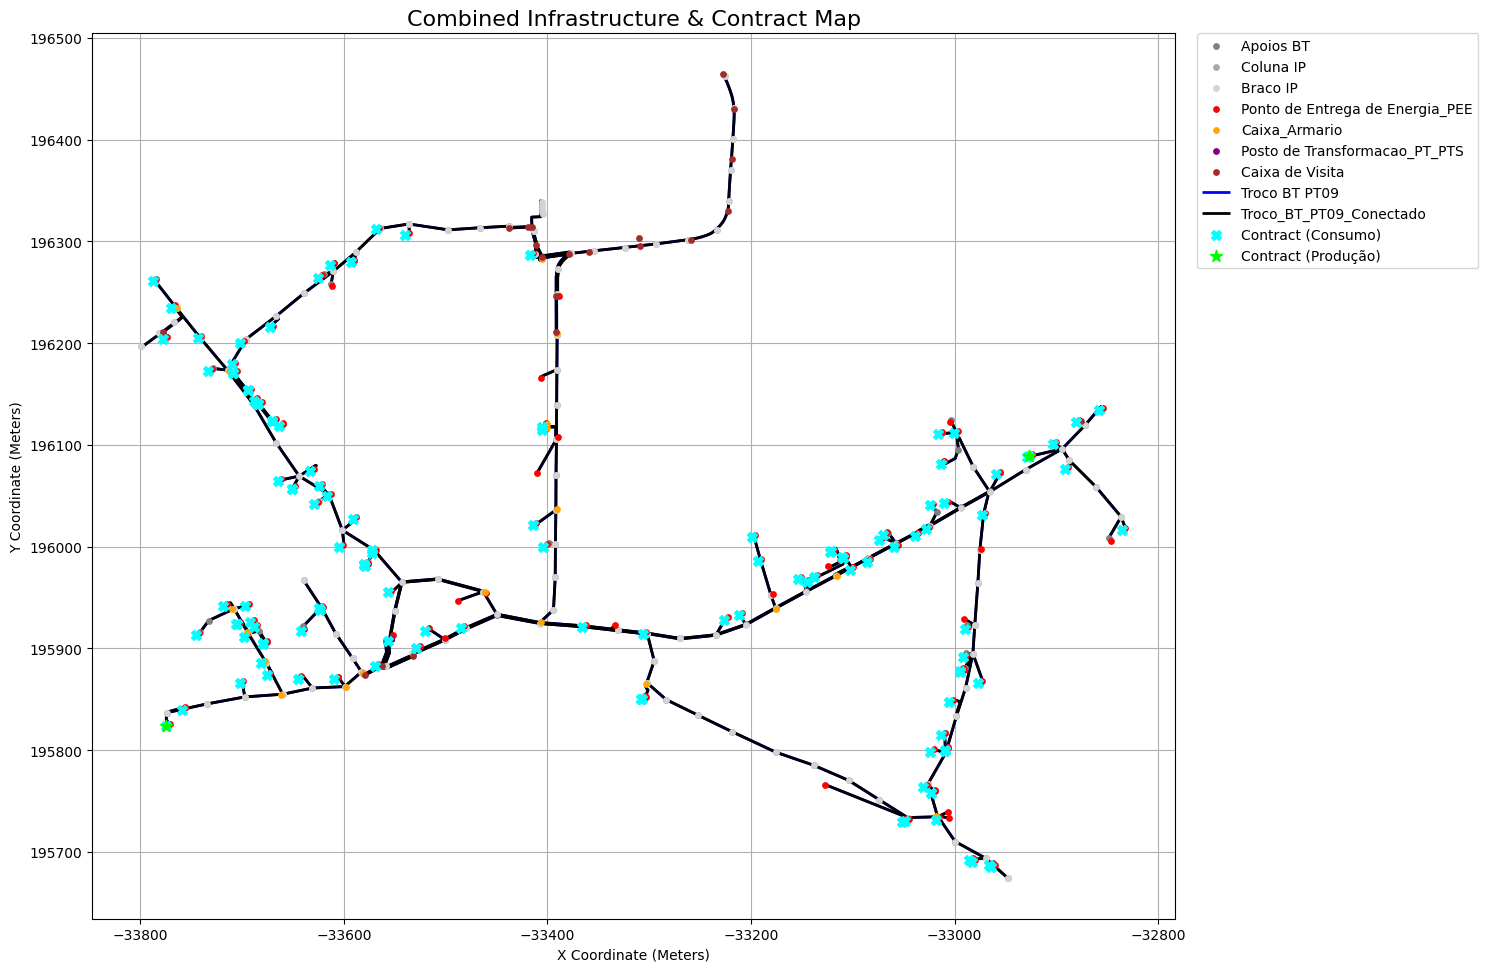

In [75]:
import geopandas
import matplotlib.pyplot as plt
import pandas as pd

print("\n--- Generating Combined Plot ---")

#
# --- Part 2: Create the Base Map (Infrastructure) ---
#
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Define the color map for the base infrastructure layers
color_map = {
    'Apoios BT': 'gray',
    'Coluna IP': 'darkgray',
    'Braco IP': 'lightgray',
    'Ponto de Entrega de Energia_PEE': 'red',
    'Caixa_Armario': 'orange',
    'Posto de Transformacao_PT_PTS': 'purple',
    'Caixa de Visita': 'brown',
    'Troco BT PT09': 'blue'
}

print("Plotting base infrastructure layers...")
try:
    for name, gdf in all_geodata.items():
        color = color_map.get(name, 'black')

        # Check for empty or invalid geometry
        if gdf.empty or not hasattr(gdf, 'geom_type'):
            print(f"Skipping empty or invalid layer: {name}")
            continue

        # Plot the layer on the pre-defined axes (ax)
        if 'Point' in gdf.geom_type.unique():
            gdf.plot(ax=ax, color=color, label=name, markersize=15, zorder=3) # zorder brings points to the front
        else: # For lines
            gdf.plot(ax=ax, color=color, label=name, linewidth=2, zorder=2)

except NameError:
    print("Error: 'all_geodata' is not defined. Cannot plot base map.")
except Exception as e:
    print(f"An error occurred plotting base layers: {e}")


#
# --- Part 3: Overlay Contract (Consumo & Produção) Layers ---
#
print("Plotting contract layers...")
try:
    # --- Filter and plot 'Consumo' contracts ---
    consumo_gdf = matches_gdf[matches_gdf['contract_type'] == 'Consumo']
    if not consumo_gdf.empty:
        consumo_gdf.plot(
            ax=ax,
            color='cyan',         # Bright, distinct color
            marker='X',           # Distinct marker
            markersize=50,        # Large enough to see
            label='Contract (Consumo)',
            zorder=10             # On top of everything
        )
        print(f"Plotted {len(consumo_gdf)} 'Consumo' contracts.")
    else:
        print("No 'Consumo' contracts found to plot.")

    # --- Filter and plot 'Produção' contracts ---
    producao_gdf = matches_gdf[matches_gdf['contract_type'] == 'Produção']
    if not producao_gdf.empty:
        producao_gdf.plot(
            ax=ax,
            color='lime',         # Bright, distinct color
            marker='*',           # Distinct marker
            markersize=80,        # Even larger
            label='Contract (Produção)',
            zorder=11             # On the very top
        )
        print(f"Plotted {len(producao_gdf)} 'Produção' contracts.")
    else:
        print("No 'Produção' contracts found to plot.")

except NameError:
    print("Warning: 'matches_gdf' not defined. Skipping contract overlay plots.")
except KeyError:
    print("Warning: 'contract_type' column not in 'matches_gdf'. Skipping contract overlay plots.")
except Exception as e:
    print(f"An error occurred plotting contract layers: {e}")


# --- Part 4: Customize and Show the Final Map ---

ax.set_title('Combined Infrastructure & Contract Map', fontsize=16)
ax.set_xlabel('X Coordinate (Meters)')
ax.set_ylabel('Y Coordinate (Meters)')
ax.grid(True)

# Place legend outside the plot to avoid clutter
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

plt.tight_layout()
plt.show()

In [85]:
import geopandas as gpd
import plotly.graph_objects as go
import pandas as pd
import geopandas

# --- 2.1 Use the same color map ---
color_map = {
    'Apoios BT': 'gray',
    'Coluna IP': 'darkgray',
    'Braco IP': 'lightgray',
    'Ponto de Entrega de Energia_PEE': 'red',
    'Caixa_Armario': 'orange',
    'Posto de Transformacao_PT_PTS': 'purple',
    'Caixa de Visita': 'brown',
    'Troco BT PT09': 'blue'
}

# --- 2.2 Create an empty Plotly figure ---
fig = go.Figure()

print("--- Gerando mapa interativo Plotly com etiquetas nas linhas ---")

# --- 2.3 Loop through layers and add them as "traces" ---
all_lons = []
all_lats = []

# PLOT LINES FIRST
try:
    for name, gdf in all_geodata.items():
        if gdf.empty or not hasattr(gdf.geometry, 'geom_type') or 'LineString' not in gdf.geom_type.unique():
            continue

        color = color_map.get(name, 'black')
        gdf_4326 = gdf.to_crs("EPSG:4326")

        # Inicializar listas para coordenadas e para as etiquetas de hover
        lons, lats, hover_texts = [], [], []

        # Iterar sobre cada linha (row) para aceder à sua geometria e atributos
        for index, row in gdf_4326.iterrows():
            # Construir a etiqueta de hover específica para esta linha
            label_for_this_line = name  # Etiqueta padrão é o nome da camada
            if name == 'Troco BT PT09':
                # Tentar usar a coluna 'id' para uma etiqueta mais descritiva
                if 'id' in row and pd.notna(row['id']):
                    label_for_this_line = f"Troço ID: {row['id']}"
                else:
                    label_for_this_line = 'Troço BT (ID não disponível)'

            # Extrair as coordenadas da linha
            line = row.geometry
            x, y = line.xy

            # Adicionar as coordenadas às listas
            lons.extend(list(x))
            lats.extend(list(y))

            # Adicionar a etiqueta repetidamente para cada ponto da linha
            hover_texts.extend([label_for_this_line] * len(x))

            # Adicionar uma quebra (None) para separar as linhas no plot
            lons.append(None)
            lats.append(None)
            hover_texts.append(None)

        all_lons.extend(lons)
        all_lats.extend(lats)

        fig.add_trace(go.Scattermap(
            lat=lats,
            lon=lons,
            mode='lines',
            line=dict(width=2.5, color=color),
            name=name,
            hoverinfo='text',
            hovertext=hover_texts
        ))
except NameError:
    print("Error: 'all_geodata' is not defined. Cannot plot base map lines.")
except Exception as e:
    print(f"An error occurred plotting base lines: {e}")

# PLOT POINTS SECOND
try:
    for name, gdf in all_geodata.items():
        if gdf.empty or not hasattr(gdf.geometry, 'geom_type') or 'Point' not in gdf.geom_type.unique():
            continue

        color = color_map.get(name, 'black')
        gdf_4326 = gdf.to_crs("EPSG:4326")

        hover_label = name
        if 'Id' in gdf_4326.columns:
            hover_label = "ID: " + gdf_4326['Id'].astype(str)
        elif 'Código da instalação' in gdf_4326.columns:
            hover_label = "Código: " + gdf_4326['Código da instalação'].astype(str)
        elif 'Nº ID' in gdf_4326.columns:
            hover_label = "Nº ID: " + gdf_4326['Nº ID'].astype(str)

        all_lons.extend(gdf_4326.geometry.x)
        all_lats.extend(gdf_4326.geometry.y)

        fig.add_trace(go.Scattermap(
            lat=gdf_4326.geometry.y,
            lon=gdf_4326.geometry.x,
            mode='markers',
            marker=dict(size=9, color=color),
            name=name,
            hoverinfo='text',
            hovertext=hover_label
        ))
except NameError:
    print("Error: 'all_geodata' is not defined. Cannot plot base map points.")
except Exception as e:
    print(f"An error occurred plotting base points: {e}")

#
# --- Part 3: Overlay Contract (Consumo & Produção) Layers (Plotly) ---
#
print("Plotting contract layers...")
try:
    # --- Filter and plot 'Consumo' contracts ---
    consumo_gdf = matches_gdf[matches_gdf['contract_type'] == 'Consumo']
    if not consumo_gdf.empty:
        consumo_gdf_4326 = consumo_gdf.to_crs("EPSG:4326")

        try:
            hover_labels = "<b>Contract (Consumo)</b><br>" + \
                           "N: " + consumo_gdf_4326['contract_n'].astype(str) + "<br>" + \
                           "Meter ID: " + consumo_gdf_4326['meter_id'].astype(str)
        except KeyError:
            hover_labels = 'Contract (Consumo)'

        all_lons.extend(consumo_gdf_4326.geometry.x)
        all_lats.extend(consumo_gdf_4326.geometry.y)

        fig.add_trace(go.Scattermap(
            lat=consumo_gdf_4326.geometry.y,
            lon=consumo_gdf_4326.geometry.x,
            mode='markers',
            marker=dict(size=10, color='cyan', symbol='x'),
            name='Contract (Consumo)',
            hoverinfo='text',
            hovertext=hover_labels
        ))
        print(f"Plotted {len(consumo_gdf)} 'Consumo' contracts.")
    else:
        print("No 'Consumo' contracts found to plot.")

    # --- Filter and plot 'Produção' contracts ---
    producao_gdf = matches_gdf[matches_gdf['contract_type'] == 'Produção']
    if not producao_gdf.empty:
        producao_gdf_4326 = producao_gdf.to_crs("EPSG:4326")

        try:
            hover_labels = "<b>Contract (Produção)</b><br>" + \
                           "N: " + producao_gdf_4326['contract_n'].astype(str) + "<br>" + \
                           "Meter ID: " + producao_gdf_4326['meter_id'].astype(str)
        except KeyError:
            hover_labels = 'Contract (Produção)'

        all_lons.extend(producao_gdf_4326.geometry.x)
        all_lats.extend(producao_gdf_4326.geometry.y)

        fig.add_trace(go.Scattermap(
            lat=producao_gdf_4326.geometry.y,
            lon=producao_gdf_4326.geometry.x,
            mode='markers',
            marker=dict(size=12, color='lime', symbol='star'),
            name='Contract (Produção)',
            hoverinfo='text',
            hovertext=hover_labels
        ))
        print(f"Plotted {len(producao_gdf)} 'Produção' contracts.")
    else:
        print("No 'Produção' contracts found to plot.")

except NameError:
    print("Warning: 'matches_gdf' not defined. Skipping contract overlay plots.")
except KeyError:
    print("Warning: 'contract_type' column not in 'matches_gdf'. Skipping contract overlay plots.")
except Exception as e:
    print(f"An error occurred plotting contract layers: {e}")

# --- Part 4: Customize and Show the Final Map ---

# Remove None/NaN values before calculating mean
valid_lats = [l for l in all_lats if l is not None and pd.notna(l)]
valid_lons = [l for l in all_lons if l is not None and pd.notna(l)]

center_lat = pd.Series(valid_lats).mean()
center_lon = pd.Series(valid_lons).mean()

fig.update_layout(
    title='Combined Infrastructure & Contract Interactive Map',
    map_style="open-street-map",
    map=dict(
        center=go.layout.map.Center(
            lat=center_lat,
            lon=center_lon
        ),
        zoom=16 # Aumentei um pouco o zoom inicial
    ),
    legend_title_text='Layers',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    margin={"r":0,"t":40,"l":0,"b":0}
)

# --- 5. Show the interactive map ---
fig.show()

print("--- Plot generation complete ---")

--- Gerando mapa interativo Plotly com etiquetas nas linhas ---
Plotting contract layers...
Plotted 138 'Consumo' contracts.
Plotted 2 'Produção' contracts.


--- Plot generation complete ---


In [77]:
import geopandas as gpd
import plotly.graph_objects as go
import pandas as pd
import geopandas


# --- 2.1 Use the same color map ---
color_map = {
    'Apoios BT': 'gray',
    'Coluna IP': 'darkgray',
    'Braco IP': 'lightgray',
    'Ponto de Entrega de Energia_PEE': 'red',
    'Caixa_Armario': 'orange',
    'Posto de Transformacao_PT_PTS': 'purple',
    'Caixa de Visita': 'brown',
    'Troco BT PT09': 'blue'
}

# --- 2.2 Create an empty Plotly figure ---
fig = go.Figure()

print("--- Gerando mapa interativo Plotly com etiquetas nas linhas ---")

# --- 2.3 Loop through layers and add them as "traces" ---
all_lons = []
all_lats = []

# PLOT LINES FIRST
try:
    for name, gdf in all_geodata.items():
        if gdf.empty or not hasattr(gdf.geometry, 'geom_type') or 'LineString' not in gdf.geom_type.unique():
            continue

        color = color_map.get(name, 'black')
        gdf_4326 = gdf.to_crs("EPSG:4326")

        # Inicializar listas para coordenadas e para as etiquetas de hover
        lons, lats, hover_texts = [], [], []

        # Iterar sobre cada linha (row) para aceder à sua geometria e atributos
        for index, row in gdf_4326.iterrows():
            # Construir a etiqueta de hover específica para esta linha
            label_for_this_line = name  # Etiqueta padrão é o nome da camada
            if name == 'Troco BT PT09':
                # Tentar usar a coluna 'id' para uma etiqueta mais descritiva
                if 'id' in row and pd.notna(row['id']):
                    label_for_this_line = f"Troço ID: {row['id']}"
                else:
                    label_for_this_line = 'Troço BT (ID não disponível)'

            # Extrair as coordenadas da linha
            line = row.geometry
            x, y = line.xy

            # Adicionar as coordenadas às listas
            lons.extend(list(x))
            lats.extend(list(y))

            # Adicionar a etiqueta repetidamente para cada ponto da linha
            hover_texts.extend([label_for_this_line] * len(x))

            # Adicionar uma quebra (None) para separar as linhas no plot
            lons.append(None)
            lats.append(None)
            hover_texts.append(None)

        all_lons.extend(lons)
        all_lats.extend(lats)

        # CHANGE: Using go.Scattergeo to ensure visibility
        fig.add_trace(go.Scattergeo(
            lat=lats,
            lon=lons,
            mode='lines',
            line=dict(width=2.5, color=color),
            name=name,
            hoverinfo='text',
            hovertext=hover_texts
        ))
except NameError:
    print("Error: 'all_geodata' is not defined. Cannot plot base map lines.")
except Exception as e:
    print(f"An error occurred plotting base lines: {e}")

# PLOT POINTS SECOND
try:
    for name, gdf in all_geodata.items():
        if gdf.empty or not hasattr(gdf.geometry, 'geom_type') or 'Point' not in gdf.geom_type.unique():
            continue

        color = color_map.get(name, 'black')
        gdf_4326 = gdf.to_crs("EPSG:4326")

        hover_label = name
        if 'Id' in gdf_4326.columns:
            hover_label = "ID: " + gdf_4326['Id'].astype(str)
        elif 'Código da instalação' in gdf_4326.columns:
            hover_label = "Código: " + gdf_4326['Código da instalação'].astype(str)
        elif 'Nº ID' in gdf_4326.columns:
            hover_label = "Nº ID: " + gdf_4326['Nº ID'].astype(str)

        all_lons.extend(gdf_4326.geometry.x)
        all_lats.extend(gdf_4326.geometry.y) # FIX: Was extending X, now extends Y

        # CHANGE: Using go.Scattergeo to ensure visibility
        fig.add_trace(go.Scattergeo(
            lat=gdf_4326.geometry.y,
            lon=gdf_4326.geometry.x,
            mode='markers',
            marker=dict(size=9, color=color),
            name=name,
            hoverinfo='text',
            hovertext=hover_label
        ))
except NameError:
    print("Error: 'all_geodata' is not defined. Cannot plot base map points.")
except Exception as e:
    print(f"An error occurred plotting base points: {e}")


# --- Part 3: Overlay Contract (Consumo & Produção) Layers (Plotly) ---

print("Plotting contract layers...")
try:
    # --- Filter and plot 'Consumo' contracts ---
    consumo_gdf = matches_gdf[matches_gdf['contract_type'] == 'Consumo']
    if not consumo_gdf.empty:
        consumo_gdf_4326 = consumo_gdf.to_crs("EPSG:4326")

        try:
            hover_labels = "<b>Contract (Consumo)</b><br>" + \
                           "N: " + consumo_gdf_4326['contract_n'].astype(str) + "<br>" + \
                           "Meter ID: " + consumo_gdf_4326['meter_id'].astype(str)
        except KeyError:
            hover_labels = 'Contract (Consumo)'

        all_lons.extend(consumo_gdf_4326.geometry.x)
        all_lats.extend(consumo_gdf_4326.geometry.y) # FIX: Was extending X, now extends Y

        # CHANGE: Using go.Scattergeo to ensure visibility
        fig.add_trace(go.Scattergeo(
            lat=consumo_gdf_4326.geometry.y,
            lon=consumo_gdf_4326.geometry.x,
            mode='markers',
            marker=dict(size=10, color='cyan', symbol='x'),
            name='Contract (Consumo)',
            hoverinfo='text',
            hovertext=hover_labels
        ))
        print(f"Plotted {len(consumo_gdf)} 'Consumo' contracts.")
    else:
        print("No 'Consumo' contracts found to plot.")

    # --- Filter and plot 'Produção' contracts ---
    producao_gdf = matches_gdf[matches_gdf['contract_type'] == 'Produção']
    if not producao_gdf.empty:
        producao_gdf_4326 = producao_gdf.to_crs("EPSG:4326")

        try:
            hover_labels = "<b>Contract (Produção)</b><br>" + \
                           "N: " + producao_gdf_4326['contract_n'].astype(str) + "<br>" + \
                           "Meter ID: " + producao_gdf_4326['meter_id'].astype(str)
        except KeyError:
            hover_labels = 'Contract (Produção)'

        all_lons.extend(producao_gdf_4326.geometry.x)
        all_lats.extend(producao_gdf_4326.geometry.y)

        # CHANGE: Using go.Scattergeo to ensure visibility
        fig.add_trace(go.Scattergeo(
            lat=producao_gdf_4326.geometry.y,
            lon=producao_gdf_4326.geometry.x,
            mode='markers',
            marker=dict(size=12, color='lime', symbol='star'),
            name='Contract (Produção)',
            hoverinfo='text',
            hovertext=hover_labels
        ))
        print(f"Plotted {len(producao_gdf)} 'Produção' contracts.")
    else:
        print("No 'Produção' contracts found to plot.")

except NameError:
    print("Warning: 'matches_gdf' not defined. Skipping contract overlay plots.")
except KeyError:
    print("Warning: 'contract_type' column not in 'matches_gdf'. Skipping contract overlay plots.")
except Exception as e:
    print(f"An error occurred plotting contract layers: {e}")



# --- Part 4: Customize and Show the Final Map ---

# Remove None/NaN values before calculating mean
valid_lats = [l for l in all_lats if l is not None and pd.notna(l)]
valid_lons = [l for l in all_lons if l is not None and pd.notna(l)]

center_lat = pd.Series(valid_lats).mean()
center_lon = pd.Series(valid_lons).mean()

# CHANGE: Update layout to use `geo` settings for Scattergeo
fig.update_layout(
    title='Combined Infrastructure & Contract Interactive Map',
    geo=dict(
        projection_type='mercator', # Standard map projection
        center=dict(lat=center_lat, lon=center_lon),
        # Use a simple land/ocean background
        landcolor='rgb(235, 235, 235)',
        oceancolor='rgb(215, 215, 215)',
        showland=True,
        showocean=True,
        # Set the map's zoom level by defining the viewable area
        lataxis_range=[pd.Series(valid_lats).min(), pd.Series(valid_lats).max()],
        lonaxis_range=[pd.Series(valid_lons).min(), pd.Series(valid_lons).max()],
    ),
    legend_title_text='Layers',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    margin={"r":0,"t":40,"l":0,"b":0}
)

# --- 5. Show the interactive map ---
print("Displaying interactive map...")
fig.show()

--- Gerando mapa interativo Plotly com etiquetas nas linhas ---
Plotting contract layers...
Plotted 138 'Consumo' contracts.
Plotted 2 'Produção' contracts.
Displaying interactive map...


In [86]:
import geopandas as gpd
import plotly.graph_objects as go
import pandas as pd
import geopandas

# --- 2.1 Use the same color map ---
color_map = {
    'Apoios BT': 'gray',
    'Coluna IP': 'darkgray',
    'Braco IP': 'lightgray',
    'Ponto de Entrega de Energia_PEE': 'red',
    'Caixa_Armario': 'orange',
    'Posto de Transformacao_PT_PTS': 'purple',
    'Caixa de Visita': 'brown',
    'Troco BT PT09': 'blue'
}

# --- 2.2 Create an empty Plotly figure ---
fig = go.Figure()

# --- 2.3 Loop through layers and add them as "traces" ---
all_lons = []
all_lats = []

# PLOT LINES FIRST
try:
    for name, gdf in all_geodata.items():
        if gdf.empty or not hasattr(gdf.geometry, 'geom_type') or 'LineString' not in gdf.geom_type.unique():
            continue

        color = color_map.get(name, 'black')
        gdf_4326 = gdf.to_crs("EPSG:4326")

        # Inicializar listas para coordenadas e para as etiquetas de hover
        lons, lats, hover_texts = [], [], []

        # Iterar sobre cada linha (row) para aceder à sua geometria e atributos
        for index, row in gdf_4326.iterrows():
            # Construir a etiqueta de hover específica para esta linha
            label_for_this_line = name  # Etiqueta padrão é o nome da camada
            if name == 'Troco BT PT09':
                # Tentar usar a coluna 'id' para uma etiqueta mais descritiva
                if 'id' in row and pd.notna(row['id']):
                    label_for_this_line = f"Troço ID: {row['id']}"
                else:
                    label_for_this_line = 'Troço BT (ID não disponível)'

            # Extrair as coordenadas da linha
            line = row.geometry
            x, y = line.xy

            # Adicionar as coordenadas às listas
            lons.extend(list(x))
            lats.extend(list(y))

            # Adicionar a etiqueta repetidamente para cada ponto da linha
            hover_texts.extend([label_for_this_line] * len(x))

            # Adicionar uma quebra (None) para separar as linhas no plot
            lons.append(None)
            lats.append(None)
            hover_texts.append(None)

        all_lons.extend(lons)
        all_lats.extend(lats)

        # CHANGE: Using go.Scattergeo to ensure visibility
        fig.add_trace(go.Scattergeo(
            lat=lats,
            lon=lons,
            mode='lines',
            line=dict(width=2.5, color=color),
            name=name,
            hoverinfo='text',
            hovertext=hover_texts
        ))
except NameError:
    print("Error: 'all_geodata' is not defined. Cannot plot base map lines.")
except Exception as e:
    print(f"An error occurred plotting base lines: {e}")

# PLOT POINTS SECOND
try:
    for name, gdf in all_geodata.items():
        if gdf.empty or not hasattr(gdf.geometry, 'geom_type') or 'Point' not in gdf.geom_type.unique():
            continue

        color = color_map.get(name, 'black')
        gdf_4326 = gdf.to_crs("EPSG:4326")

        hover_label = name
        if 'Id' in gdf_4326.columns:
            hover_label = "ID: " + gdf_4326['Id'].astype(str)
        elif 'Código da instalação' in gdf_4326.columns:
            hover_label = "Código: " + gdf_4326['Código da instalação'].astype(str)
        elif 'Nº ID' in gdf_4326.columns:
            hover_label = "Nº ID: " + gdf_4326['Nº ID'].astype(str)

        all_lons.extend(gdf_4326.geometry.x)
        all_lats.extend(gdf_4326.geometry.y) # FIX: Was extending X, now extends Y

        # CHANGE: Using go.Scattergeo to ensure visibility
        fig.add_trace(go.Scattergeo(
            lat=gdf_4326.geometry.y,
            lon=gdf_4326.geometry.x,
            mode='markers',
            marker=dict(size=9, color=color),
            name=name,
            hoverinfo='text',
            hovertext=hover_label
        ))
except NameError:
    print("Error: 'all_geodata' is not defined. Cannot plot base map points.")
except Exception as e:
    print(f"An error occurred plotting base points: {e}")

#
# --- Part 3: Overlay Contract (Consumo & Produção) Layers (Plotly) ---
#
print("Plotting contract layers...")
try:
    # --- Filter and plot 'Consumo' contracts with color gradient ---
    consumo_gdf = matches_gdf[matches_gdf['contract_type'] == 'Consumo']
    if not consumo_gdf.empty:
        consumo_gdf_4326 = consumo_gdf.to_crs("EPSG:4326")

        # Ensure 'contract_potencia_valor' is numeric for the color scale
        if 'contract_potencia_valor' in consumo_gdf_4326.columns:
            # Coerce errors to NaN (they will appear as default color)
            consumo_gdf_4326['contract_potencia_valor'] = pd.to_numeric(consumo_gdf_4326['contract_potencia_valor'], errors='coerce')
            power_values = consumo_gdf_4326['contract_potencia_valor']
            power_text = "Potência: " + power_values.astype(str) + " kVA<br>"
        else:
            power_values = None # No power data to plot
            power_text = "Potência: N/A<br>"

        try:
            hover_labels = "<b>Contract (Consumo)</b><br>" + \
                           "N: " + consumo_gdf_4326['contract_n'].astype(str) + "<br>" + \
                           power_text + \
                           "Meter ID: " + consumo_gdf_4326['meter_id'].astype(str)
        except KeyError:
            hover_labels = 'Contract (Consumo)'

        all_lons.extend(consumo_gdf_4326.geometry.x)
        all_lats.extend(consumo_gdf_4326.geometry.y) # FIX: Was extending X, now extends Y

        # CHANGE: Using go.Scattergeo with a color gradient
        fig.add_trace(go.Scattergeo(
            lat=consumo_gdf_4326.geometry.y,
            lon=consumo_gdf_4326.geometry.x,
            mode='markers',
            marker=dict(
                color=power_values,             # Set color based on power
                colorscale='Viridis',         # Use a 'Viridis' color scale
                showscale=True,               # Show the color bar legend
                colorbar=dict(title='Potência (kVA)'),
                size=8,                       # Use default circle markers
                cmin=power_values.min(),      # Set min for color scale
                cmax=power_values.max()       # Set max for color scale
            ),
            name='Contract (Consumo)',
            hoverinfo='text',
            hovertext=hover_labels
        ))
        print(f"Plotted {len(consumo_gdf)} 'Consumo' contracts.")
    else:
        print("No 'Consumo' contracts found to plot.")

    # --- Filter and plot 'Produção' contracts (Unchanged) ---
    producao_gdf = matches_gdf[matches_gdf['contract_type'] == 'Produção']
    if not producao_gdf.empty:
        producao_gdf_4326 = producao_gdf.to_crs("EPSG:4326")

        try:
            hover_labels = "<b>Contract (Produção)</b><br>" + \
                           "N: " + producao_gdf_4326['contract_n'].astype(str) + "<br>" + \
                           "Meter ID: " + producao_gdf_4326['meter_id'].astype(str)
        except KeyError:
            hover_labels = 'Contract (Produção)'

        all_lons.extend(producao_gdf_4326.geometry.x)
        all_lats.extend(producao_gdf_4326.geometry.y) # FIX: Was extending X, now extends Y

        # CHANGE: Using go.Scattergeo to ensure visibility
        fig.add_trace(go.Scattergeo(
            lat=producao_gdf_4326.geometry.y,
            lon=producao_gdf_4326.geometry.x,
            mode='markers',
            marker=dict(size=12, color='lime', symbol='star'),
            name='Contract (Produção)',
            hoverinfo='text',
            hovertext=hover_labels
        ))
        print(f"Plotted {len(producao_gdf)} 'Produção' contracts.")
    else:
        print("No 'Produção' contracts found to plot.")

except NameError:
    print("Warning: 'matches_gdf' not defined. Skipping contract overlay plots.")
except KeyError:
    print("Warning: 'contract_type' column not in 'matches_gdf'. Skipping contract overlay plots.")
except Exception as e:
    print(f"An error occurred plotting contract layers: {e}")

# --- Part 4: Customize and Show the Final Map ---

# Remove None/NaN values before calculating mean
valid_lats = [l for l in all_lats if l is not None and pd.notna(l)]
valid_lons = [l for l in all_lons if l is not None and pd.notna(l)]

center_lat = pd.Series(valid_lats).mean()
center_lon = pd.Series(valid_lons).mean()

fig.update_layout(
    title='Combined Infrastructure & Contract Map',
    geo=dict(
        projection_type='mercator', # Standard map projection
        center=dict(lat=center_lat, lon=center_lon),
        # Use a simple land/ocean background
        landcolor='rgb(235, 235, 235)',
        oceancolor='rgb(215, 215, 215)',
        showland=True,
        showocean=True,
        # Set the map's zoom level by defining the viewable area
        lataxis_range=[pd.Series(valid_lats).min(), pd.Series(valid_lats).max()],
        lonaxis_range=[pd.Series(valid_lons).min(), pd.Series(valid_lons).max()],
    ),
    legend_title_text='Layers',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    margin={"r":0,"t":40,"l":0,"b":0}
)

# --- 5. Show the interactive map ---
print("Displaying interactive map...")
fig.show()

Plotting contract layers...
Plotted 138 'Consumo' contracts.
Plotted 2 'Produção' contracts.
Displaying interactive map...


<

# Assing contracts to buses

In [78]:
#41.43434883312855, -8.537270447514091 (escuteiros)
#41.4392745137395, -8.541782851623543 (ceve)

# Load (feeder)

Curva de carga 1
Número de série do contador : ;PT0002000072565497FV (Nº 84668023) - PT009 - Totalizador
Data de ínicio : ;30/09/2023
Data do fim : ;30/09/2024

Número;Etiqueta;Unidade
1;Activa Importada Power Agregado;kW
2;Q1 Power Agregado;kvar
3;Q4 Power Agregado;kvar
4;Activa Exportada Power Agregado;kW
5;Q3 Power Agregado;kvar
6;Q2 Power Agregado;kvar

In [79]:
import pandas as pd

excel_file_path = "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/Diagrama de Carga PT009.xlsx"

try:
    load_diagram_df = pd.read_excel(excel_file_path, skiprows=17,parse_dates=['Data']
    )


    new_labels = {
        1: 'P_import_kW',       # Active Power Imported (kW)
        2: 'Q1_import_kvar',    # Reactive Power Q1 (kvar)
        3: 'Q4_import_kvar',    # Reactive Power Q4 (kvar)
        4: 'P_export_kW',       # Active Power Exported (kW)
        5: 'Q3_export_kvar',    # Reactive Power Q3 (kvar)
        6: 'Q2_export_kvar'     # Reactive Power Q2 (kvar)
    }


    # Sort the DataFrame by its index (the timestamps)
    load_diagram_df.sort_index(inplace=True)

    load_diagram_df.rename(columns=new_labels, inplace=True)


    print("--- Column labels have been updated! ---")
    print(load_diagram_df.head())
    # --- 3. Display the first few rows to verify ---
    print("--- Ficheiro Excel 'Contratos PT009.xlsx' lido com sucesso! ---")

    print("\nVerifying data types:")
    load_diagram_df.info()

except FileNotFoundError:
    print(f"ERRO: O ficheiro não foi encontrado no caminho: {excel_file_path}")
except Exception as e:
    print(f"Ocorreu um erro ao ler o ficheiro Excel: {e}")



--- Column labels have been updated! ---
                 Data  P_import_kW  Q1_import_kvar  Q4_import_kvar  \
0 2023-10-01 00:00:00           70              15               0   
1 2023-10-01 00:15:00           70              16               0   
2 2023-10-01 00:30:00           67              16               0   
3 2023-10-01 00:45:00           69              15               0   
4 2023-10-01 01:00:00           66              16               0   

   P_export_kW  Q3_export_kvar  Q2_export_kvar  
0            0               0               0  
1            0               0               0  
2            0               0               0  
3            0               0               0  
4            0               0               0  
--- Ficheiro Excel 'Contratos PT009.xlsx' lido com sucesso! ---

Verifying data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35140 entries, 0 to 35139
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype       

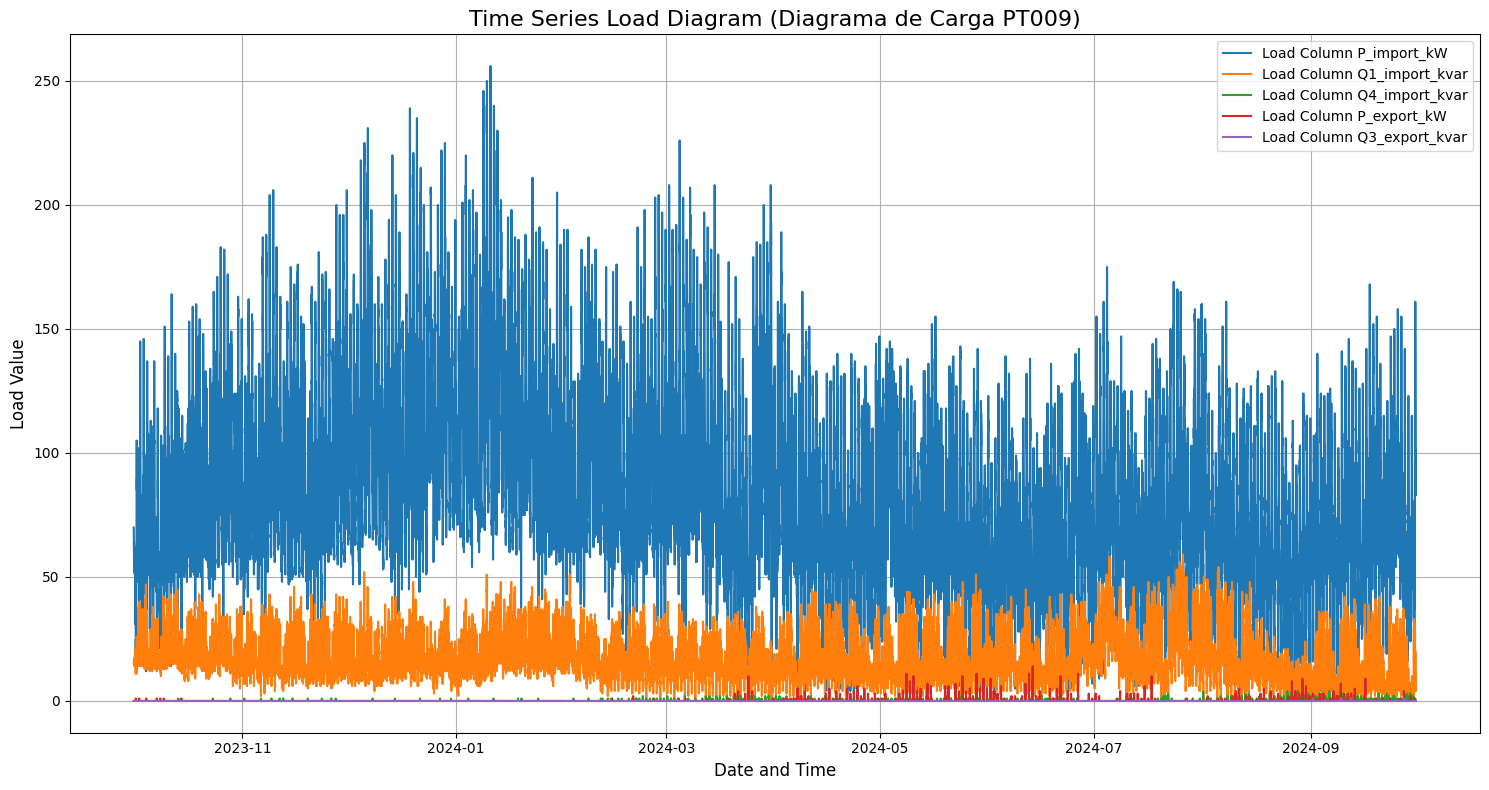

In [80]:
    load_diagram_df.set_index('Data', inplace=True)

    plt.figure(figsize=(15, 8))
    columns_to_plot = load_diagram_df.columns[0:5]
    for col in columns_to_plot:
        plt.plot(load_diagram_df.index, load_diagram_df[col], label=f'Load Column {col}')

    plt.title('Time Series Load Diagram (Diagrama de Carga PT009)', fontsize=16)
    plt.xlabel('Date and Time', fontsize=12)
    plt.ylabel('Load Value', fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [81]:
first_date = load_diagram_df.index.min()
last_date = load_diagram_df.index.max()

print(f"Data starts on: {first_date}")
print(f"Data ends on:   {last_date}")

Data starts on: 2023-10-01 00:00:00
Data ends on:   2024-09-30 23:45:00


# Metering profiles
CEVE_Data
import os
/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Datadata_piloto1 (Unzipped Files)

In [ ]:
import os
import pandas as pd

folder_path = "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/data_piloto1 (Unzipped Files)/Participants"

try:
    file_list = os.listdir(folder_path)
    print(f"Found {len(file_list)} files in the directory:")
    print(file_list)
    print("-" * 30)

    all_data = {}

    for filename in file_list:

        if filename.endswith(".xlsx"):
            print(f"Processing {filename}...")

            file_path = os.path.join(folder_path, filename)
            try:
                df = pd.read_excel(file_path)
                all_data[filename] = df

                print(f"Successfully read {filename}. It has {len(df)} rows.")
                print(df.head())
                print("-" * 30)

            except Exception as e:
                print(f"Could not read {filename}. Error: {e}")

        else:
            print(f"Skipping {filename} (not an .xlsx file)")

except FileNotFoundError:
    print(f" Error: Directory not found at the path:")
    print(folder_path)
    print("Please double-check the folder name and path.")
except Exception as e:
    print(f"An error occurred: {e}")

Found 29 files in the directory:
['C6.xlsx', 'C7.xlsx', 'C8.xlsx', 'C9.xlsx', 'C10.xlsx', 'C11.xlsx', 'C12.xlsx', 'C14.xlsx', 'C15.xlsx', 'C16.xlsx', 'C19.xlsx', 'C20.xlsx', 'C21.xlsx', 'C23.xlsx', 'C26.xlsx', 'C3.xlsx', 'C13.xlsx', 'C17.xlsx', 'C22.xlsx', 'C2.xlsx', 'C4.xlsx', 'C18.xlsx', 'C24.xlsx', 'C25.xlsx', 'C1.xlsx', 'C27.xlsx', 'C5.xlsx', 'C28.xlsx', 'desktop.ini']
------------------------------
Processing C6.xlsx...
Successfully read C6.xlsx. It has 29212 rows.
          reading_time  Consumption [kWh]  Injection [kWh]
0  2023-01-01 00:00:00              0.103                0
1  2023-01-01 00:15:00              0.100                0
2  2023-01-01 00:30:00              0.122                0
3  2023-01-01 00:45:00              0.112                0
4  2023-01-01 01:00:00              0.086                0
------------------------------
Processing C7.xlsx...
Successfully read C7.xlsx. It has 29239 rows.
          reading_time  Consumption [kWh]  Injection [kWh]
0  2023-01-01

In [ ]:
all_data['C6.xlsx']['Consumption [kWh]']
all_data['C6.xlsx']

,reading_time,Consumption [kWh],Injection [kWh]
0,2023-01-01 00:00:00,0.103,0
1,2023-01-01 00:15:00,0.100,0
2,2023-01-01 00:30:00,0.122,0
3,2023-01-01 00:45:00,0.112,0
4,2023-01-01 01:00:00,0.086,0
...,...,...,...
29207,2023-12-31 22:45:00,0.110,0
29208,2023-12-31 23:00:00,0.115,0
29209,2023-12-31 23:15:00,0.089,0
29210,2023-12-31 23:30:00,0.096,0


In [ ]:
import os
import pandas as pd

folder_path = "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/data_piloto1 (Unzipped Files)/Participants"

try:
    file_list = os.listdir(folder_path)
    print(f"Found {len(file_list)} files in the directory:")
    print(file_list)
    print("-" * 30)

    all_data = {}
    for filename in file_list:

        if filename.endswith(".xlsx"):
            print(f"Processing {filename}...")

            file_path = os.path.join(folder_path, filename)

            try:

                df = pd.read_excel(file_path)

                # Check if 'reading_time' column exists before setting it as index
                if 'reading_time' in df.columns:
                    df = df.set_index('reading_time')
                    print(f"Successfully set 'reading_time' as index.")
                else:
                    print(f"Warning: 'reading_time' column not found in {filename}. Index not set.")

                # Store the (now possibly indexed) DataFrame in the dictionary
                all_data[filename] = df

                print(f"Successfully read {filename}. It has {len(df)} rows.")
                print(df.head())
                print("-" * 30)

            except Exception as e:
                print(f"Could not read {filename}. Error: {e}")

        else:
            print(f"Skipping {filename} (not an .xlsx file)")

except FileNotFoundError:
    print(f" Error: Directory not found at the path:")
    print(folder_path)
    print("Please double-check the folder name and path.")
except Exception as e:
    print(f"An error occurred: {e}")

print("\n--- All files processed. ---")

Found 29 files in the directory:
['C6.xlsx', 'C7.xlsx', 'C8.xlsx', 'C9.xlsx', 'C10.xlsx', 'C11.xlsx', 'C12.xlsx', 'C14.xlsx', 'C15.xlsx', 'C16.xlsx', 'C19.xlsx', 'C20.xlsx', 'C21.xlsx', 'C23.xlsx', 'C26.xlsx', 'C3.xlsx', 'C13.xlsx', 'C17.xlsx', 'C22.xlsx', 'C2.xlsx', 'C4.xlsx', 'C18.xlsx', 'C24.xlsx', 'C25.xlsx', 'C1.xlsx', 'C27.xlsx', 'C5.xlsx', 'C28.xlsx', 'desktop.ini']
------------------------------
Processing C6.xlsx...
Successfully set 'reading_time' as index.
Successfully read C6.xlsx. It has 29212 rows.
                     Consumption [kWh]  Injection [kWh]
reading_time                                           
2023-01-01 00:00:00              0.103                0
2023-01-01 00:15:00              0.100                0
2023-01-01 00:30:00              0.122                0
2023-01-01 00:45:00              0.112                0
2023-01-01 01:00:00              0.086                0
------------------------------
Processing C7.xlsx...
Successfully set 'reading_time' as ind

In [ ]:
import pandas as pd

all_data['C6.xlsx']['reading_time'] = pd.to_datetime(all_data['C6.xlsx']['reading_time'])

#. Set the 'reading_time' column as the index

all_data['C6.xlsx'] = all_data['C6.xlsx'].set_index('reading_time')

print(f"DataFrame for {'C6.xlsx'} is now a time series.")
print(all_data['C6.xlsx'].head())
print("\nIndex type:")
print(type(all_data['C6.xlsx'].index))

KeyError: 'reading_time'

In [ ]:
df.columns

Index(['Consumption [kWh]', 'Injection [kWh]'], dtype='object')

<Axes: xlabel='reading_time'>

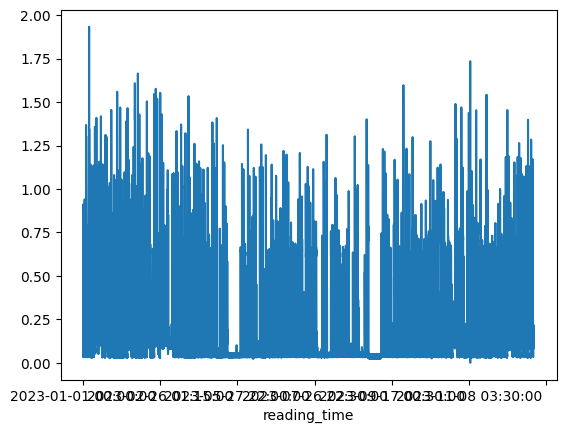

In [ ]:
all_data['C6.xlsx']['Consumption [kWh]'].plot()

Found 29 files in the directory.
------------------------------
Processing C6.xlsx...
Set 'reading_time' as datetime index.
Successfully read C6.xlsx.
Processing C7.xlsx...
Set 'reading_time' as datetime index.
Successfully read C7.xlsx.
Processing C8.xlsx...
Set 'reading_time' as datetime index.
Successfully read C8.xlsx.
Processing C9.xlsx...
Set 'reading_time' as datetime index.
Successfully read C9.xlsx.
Processing C10.xlsx...
Set 'reading_time' as datetime index.
Successfully read C10.xlsx.
Processing C11.xlsx...
Set 'reading_time' as datetime index.
Successfully read C11.xlsx.
Processing C12.xlsx...
Set 'reading_time' as datetime index.
Successfully read C12.xlsx.
Processing C14.xlsx...
Set 'reading_time' as datetime index.
Successfully read C14.xlsx.
Processing C15.xlsx...
Set 'reading_time' as datetime index.
Successfully read C15.xlsx.
Processing C16.xlsx...
Set 'reading_time' as datetime index.
Successfully read C16.xlsx.
Processing C19.xlsx...
Set 'reading_time' as datetime 

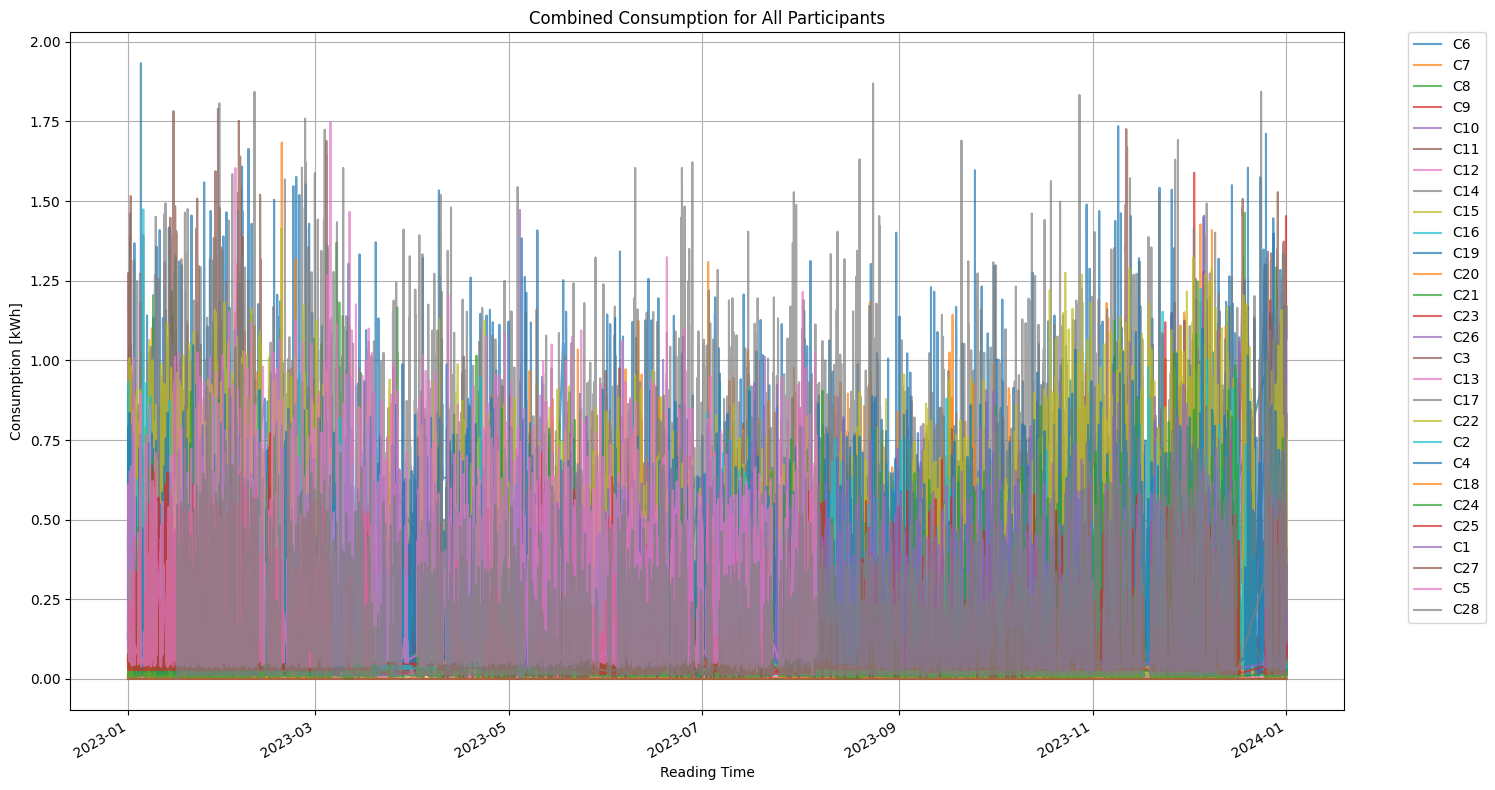

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- 1. Data Loading ---

folder_path = "/content/drive/MyDrive/Diana Vieira Fernandes - Work folder/CEVE_Data/data_piloto1 (Unzipped Files)/Participants"

all_data = {}
try:
    file_list = os.listdir(folder_path)
    print(f"Found {len(file_list)} files in the directory.")
    print("-" * 30)

    for filename in file_list:
        if filename.endswith(".xlsx"):
            print(f"Processing {filename}...")
            file_path = os.path.join(folder_path, filename)

            try:
                df = pd.read_excel(file_path)

                if 'reading_time' in df.columns:
                    # Convert to datetime AND set as index
                    df['reading_time'] = pd.to_datetime(df['reading_time'])
                    df = df.set_index('reading_time')
                    print("Set 'reading_time' as datetime index.")
                else:
                    print(f"Warning: 'reading_time' column not found in {filename}.")

                all_data[filename] = df
                print(f"Successfully read {filename}.")

            except Exception as e:
                print(f"Could not read {filename}. Error: {e}")
        else:
             print(f"Skipping {filename} (not an .xlsx file)")

    print("-" * 30)
    print("--- All files processed. ---")

except FileNotFoundError:
    print(f"---  ERROR: DIRECTORY NOT FOUND ---")
    print(f"Path: {folder_path}")
    print("Please double-check the folder name and path.")
except Exception as e:
    print(f"An error occurred during loading: {e}")

# --- 2. Plotting All Data on One Graph ---

if not all_data:
    print("No data was loaded. Cannot plot.")
else:
    print("\n--- Generating combined consumption plot ---")

    # Create a figure and a single axes
    fig, ax = plt.subplots(figsize=(15, 8))

    plotted_count = 0

    # Loop through each item (filename, dataframe) in the dictionary
    for filename, df in all_data.items():

        # Check if the required column exists
        if 'Consumption [kWh]' in df.columns:
            try:
                # Plot on the *same* axes (ax=ax)
                # Label the line with the filename (without .xlsx)
                label_name = filename.replace('.xlsx', '')
                df['Consumption [kWh]'].plot(ax=ax, label=label_name, alpha=0.7) # Added alpha for better visibility
                plotted_count += 1
            except Exception as e:
                print(f"Could not plot {filename}. Error: {e}")
        else:
            print(f"Skipping {filename} (no 'Consumption [kWh]' column).")

    # --- 3. Customize the combined plot ---
    if plotted_count > 0:
        print(f"Successfully plotted {plotted_count} files.")
        ax.set_title('Combined Consumption for All Participants')
        ax.set_ylabel('Consumption [kWh]')
        ax.set_xlabel('Reading Time')
        ax.grid(True)

        # Add a legend. It might be crowded, so we place it outside the plot.
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

        fig.tight_layout() # Adjust layout to prevent labels from overlapping

        # Save the figure
        plt.savefig('combined_consumption.png', bbox_inches='tight') # bbox_inches ensures legend is saved
        print("Successfully saved 'combined_consumption.png'")

    else:
        print("No files with 'Consumption [kWh]' were found to plot.")

# Optimization Problem
This is the core of "placement."

## Decision Variables:

The location of the flexibility asset (which bus index).

The size of the asset (e.g., the power rating in kW and energy capacity in kWh for a battery).

## Objective Function:

To fix voltage: Minimize the sum of all voltage deviations below 0.95 p.u. across all time steps.

To fix congestion: Minimize the amount of line loading that exceeds 100%.

For cost: Minimize the total investment cost (e.g., cost per kWh of the battery).

## Constraints:

Physics: The power flow equations must always be respected.

Operational Limits: Voltages must stay within a safe band (e.g., 0.95 to 1.05 p.u.). Line loading must not exceed 100%.

Asset Limits: A battery cannot be charged and discharged at the same time. Its state of charge must be between 0% and 100%.


1. Initial "Best Guess" Allocation:

Calculate an allocation factor for each customer based on their nominal (contracted) power. This determines each customer's "share" of the total load.

Distribute the total power measured at the substation for a given time step to all customers according to their share. This first guess ignores power losses in the grid.

2. Run the First Power Flow (BFS):

With these initial load estimates, run the Backward/Forward Sweep algorithm (pp.runpp(net)).

This simulation calculates the grid's state, most importantly, the total power lost as heat in the wires.

3. Refine the Customer Load Total:

The power the customers actually consumed is the substation measurement minus the calculated losses.

Calculate a new, more accurate total for customer consumption: New Customer Total = Substation Power - Calculated Losses.

4. Re-Allocate and Re-Run:

Distribute this new, refined customer total among all loads using the same allocation factors from Step 1.

Run the BFS power flow again with these more accurate load values.

5. Repeat Until Converged:

Repeat steps 2-4. After a few iterations, the calculated losses will stabilize.

The final result is a highly accurate estimate of the power being consumed at every individual bus in the network.

# State estimation


## Hybrid Iterative Allocation & State Estimation

This approach resolves the unobservability of distribution grids by combining a physics-based power flow loop with a statistical state estimator.

## 1. Iterative Physics Allocation ("Prior")
We first generate pseudo-measurements for all loads by distributing the measured substation power ($P_{sub}^{meas}$) while strictly accounting for non-linear grid losses ($P_{loss}$). Since losses depend on the load, this is solved iteratively:

\begin{equation}
    P_{load, i}^{(k)} = \left( P_{sub}^{meas} - P_{loss}^{(k-1)} \right) \cdot \alpha_i
\end{equation}

Where $\alpha_i$ is the fixed allocation factor for customer $i$, derived from nominal capacity.

## 2. Observability Constraints (Virtual Measurements)
To prevent singularity in the estimator matrix, we identify all transit nodes (buses without load or generation) and apply high-confidence virtual measurements:

\begin{equation}
    P_{inj, j} = 0, \quad Q_{inj, j} = 0 \quad \forall j \in {N}_{transit}
\end{equation}

## 3. Weighted Least Squares (WLS) Estimation
Finally, we determine the state vector $\mathbf{x}$ (voltage magnitudes and angles) that minimizes the weighted squared residual error $J(\mathbf{x})$. The solver balances the high-confidence substation data against the lower-confidence load estimates:

\begin{equation}
    J(\mathbf{x}) = \sum_{i=1}^{m} w_i \left( z_i - h_i(\mathbf{x}) \right)^2
\end{equation}

Where:

* $z_i$: The measurement vector (Real Substation data + Allocated Pseudo-loads).
* $h_i(\mathbf{x})$: The power flow equations relating state $\mathbf{x}$ to measurement $i$.
* $w_i$: The weight (inverse variance $\sigma^{-2}$), where $w_{sub} \gg w_{load}$.


In [1]:
import pandapower as pp
import pandapower.networks as nw
import pandapower.estimation as est
import numpy as np
import pandas as pd

# --- PART 1: ALLOCATION FUNCTION ---
def allocate_load_by_substation(net, substation_p_mw, tolerance_mw=1e-5):
    """
    Distributes substation power to loads based on allocation factors.
    Respects network physics (losses).
    """
    # 1. DEFINE ALLOCATION FACTORS
    total_nominal_load = net.load.p_mw.sum()
    if total_nominal_load == 0:
        return False

    net.load['allocation_factor'] = net.load.p_mw / total_nominal_load

    # 2. ITERATIVE SOLVER
    current_losses = 0.0
    print(f"--- 1. Running Load Allocation (Target: {substation_p_mw} MW) ---")

    for i in range(20):
        # A. Calculate total power available for customers
        total_load_target = substation_p_mw - current_losses

        # B. Distribute this target
        net.load['p_mw'] = total_load_target * net.load['allocation_factor']

        # Keep Q proportional (Constant Power Factor assumption)
        net.load['q_mvar'] = net.load['p_mw'] * 0.3 # Simplified

        # C. Run Power Flow
        try:
            pp.runpp(net)
        except pp.LoadflowNotConverged:
            return False

        # D. Calculate New Losses
        new_losses = net.res_line.pl_mw.sum() + net.res_trafo.pl_mw.sum()

        # E. Check Convergence
        if abs(new_losses - current_losses) < tolerance_mw:
            print(f"   Converged in {i+1} steps.")
            print(f"   Calculated Grid Losses: {new_losses:.6f} MW")
            return True

        current_losses = new_losses
    return False

# --- PART 2: MAIN WORKFLOW ---

# 1. Setup Network

#net = nw.simple_four_bus_system()

# 2. Run the Allocation
# Assume we measured 0.250 MW at the substation
SUBSTATION_MEAS_P = 0.250
allocate_load_by_substation(net, substation_p_mw=SUBSTATION_MEAS_P)

# --- PART 3: PREPARE MEASUREMENTS ---
print("\n--- 2. Building Measurement Set ---")

# Clear old measurements
net.measurement.drop(net.measurement.index, inplace=True)

# A. Real Measurement (Substation) - High Confidence (Low std_dev)
# We assume we measured V=1.0 p.u. and P=0.250 MW
pp.create_measurement(net, "v", "bus", value=1.0, std_dev=0.001, element=0)
pp.create_measurement(net, "p", "line", value=SUBSTATION_MEAS_P, std_dev=0.001, element=0, side="from")

# B. Pseudo-Measurements (Allocated Loads) - Lower Confidence

for idx, row in net.load.iterrows():
    pp.create_measurement(net, "p", "bus", value=row.p_mw, std_dev=row.p_mw*0.1, element=row.bus)
    pp.create_measurement(net, "q", "bus", value=row.q_mvar, std_dev=row.q_mvar*0.1, element=row.bus)

# C. Virtual Measurements ("Observability")
# Find buses that are NOT loads and NOT the substation (Transit Nodes)
load_buses = set(net.load.bus.values)
gen_buses = set(net.ext_grid.bus.values)
all_buses = set(net.bus.index.values)

# Transit buses are ones that aren't loads or generators
transit_buses = all_buses - load_buses - gen_buses

print(f"   Adding 'Zero-Injection' to {len(transit_buses)} transit buses to fix observability.")

for bus_idx in transit_buses:
    # Virtual measurement: P=0, Q=0 with very high confidence
    pp.create_measurement(net, "p", "bus", value=0.0, std_dev=0.001, element=bus_idx)
    pp.create_measurement(net, "q", "bus", value=0.0, std_dev=0.001, element=bus_idx)


# --- PART 4: RUN STATE ESTIMATION ---
print("\n--- 3. Running State Estimation Solver ---")
success = est.estimate(net, init="flat", calculate_voltage_angles=True)

if success:
    print(" State Estimation Converged!")

# --- PART 5: FINAL RESULTS & LOSSES (FIXED) ---

    # 1. Estimated Voltages
    print("\n[State Estimation Results: Voltages]")
    print(net.res_bus_est[['vm_pu', 'va_degree']].head())

    # 2. Estimated Losses
    # We sum the losses on lines and transformers from the estimation tables
    se_losses_p = net.res_line_est['pl_mw'].sum() + net.res_trafo_est['pl_mw'].sum()

    print("\n[Final System Balance]")
    print(f"   Substation Input (Meas): {SUBSTATION_MEAS_P:.6f} MW")
    print(f"   Estimated Grid Losses:   {se_losses_p:.6f} MW")

    # 3. Verification: Check the flow on the Line connected to Substation
    # We placed the measurement on Line 0, side 'from'.
    # Let's check what the estimator calculated for that specific spot.
    est_sub_p = net.res_line_est.at[0, 'p_from_mw']

    print(f"   Estimated Substation P:  {est_sub_p:.6f} MW")

    # Check the difference (Residual)
    diff = abs(est_sub_p - SUBSTATION_MEAS_P)
    print(f"   Difference (Residual):   {diff:.6f} MW")

else:
    print(" Estimation Failed.")

# --- STEP 1: LOAD ALLOCATION ---
def iterative_load_allocation(net, substation_power_kw, max_iter=10, tolerance_kw=0.1):
    """
    Distributes substation power to loads, accounting for losses iteratively.
    """
    # 1. Calculate Allocation Factors
    total_nominal_p = net.load['p_mw'].sum()
    if total_nominal_p == 0:
        return False

    net.load['allocation_factor'] = net.load['p_mw'] / total_nominal_p

    # Convert kW to MW (Standard Pandapower unit is MW)
    P_sub_mw = substation_power_kw / 1000.0

    calculated_losses_mw = 0.0

    for i in range(max_iter):
        # Refine Customer Load Total: (Substation Meas - Losses)
        P_total_loads = P_sub_mw - calculated_losses_mw

        # Re-Allocate based on factors
        net.load['p_mw'] = P_total_loads * net.load['allocation_factor']

        try:
            pp.runpp(net)
        except pp.LoadflowNotConverged:
            print("Power flow failed to converge during allocation.")
            return False

        # Calculate new losses (Line + Transformer)
        new_losses_mw = net.res_line['pl_mw'].sum()
        if not net.trafo.empty:
            new_losses_mw += net.res_trafo['pl_mw'].sum()

        # Check Convergence
        loss_diff = abs(new_losses_mw - calculated_losses_mw)
        calculated_losses_mw = new_losses_mw

        if loss_diff * 1000 < tolerance_kw:
            print(f"  -> Converged after {i+1} iterations. Grid Losses: {calculated_losses_mw*1000:.2f} kW")
            return True

    print("Max iterations reached without full convergence.")
    return True


ModuleNotFoundError: No module named 'pandapower'

# Planning

In [82]:
import pandas as pd
import numpy as np
import pandapower as pp

def allocate_power_by_contracts(net, matches_gdf, substation_power_kw, max_iter=10, tolerance_kw=0.1):
    """
    1. Maps matches_gdf (contracts) to net.load.
    2. Calculates allocation factors based on 'contract_potencia_valor'.
    3. Iteratively distributes substation_power_kw to loads accounting for losses.
    """

    # --- 1. PREPARE MAPPINGS ---
    print("Mapping Contracts to Network Loads...")

    # Clean up net.load names to match meter_ids if necessary
    cleaned_ids = net.load['name'].astype(str).str.replace('Load_', '', regex=False).str.strip()
    load_id_map = pd.Series(net.load.index, index=cleaned_ids).to_dict()

    # Map bus info for validation (as per your snippet)
    bus_map = net.load['bus']

    # --- 2. PREPARE DATA (User's Logic) ---
    # Ensure numeric
    matches_gdf['contract_potencia_valor'] = pd.to_numeric(
        matches_gdf['contract_potencia_valor'], errors='coerce'
    )

    # Map IDs
    matches_gdf['load_idx'] = matches_gdf['meter_id'].astype(str).map(load_id_map)
    matches_gdf['bus_idx'] = matches_gdf['load_idx'].map(bus_map)

    # Apply the specific filter you requested
    valid = matches_gdf.dropna(subset=['bus_idx', 'contract_potencia_valor']).copy()
    valid['bus_idx'] = valid['bus_idx'].astype(int)

    print(f"Found {len(valid)} valid contracts to use for allocation weights.")

    if valid.empty:
        print("Error: No valid contracts found. Cannot calculate allocation factors.")
        return False

    # --- 3. CALCULATE ALLOCATION FACTORS ---
    # Filter for Consumption only
    CONSUMO_TYPE = 'Consumo'
    consumo_contracts = valid[valid['contract_type'] == CONSUMO_TYPE]

    # Initialize a temporary column for contract power sums in the net
    net.load['contract_sum_kw'] = 0.0

    # Group contracts by load_idx and sum the power
    # This handles cases where multiple contracts exist on one load point
    agg_kw = consumo_contracts.groupby('load_idx')['contract_potencia_valor'].sum()

    # Map these sums to the network
    net.load.loc[agg_kw.index, 'contract_sum_kw'] = agg_kw.values

    # Calculate Total Contract Power in the Grid
    total_contract_power = net.load['contract_sum_kw'].sum()

    if total_contract_power == 0:
        print("Total contract power is 0. Cannot allocate.")
        return False

    # Define Factors: This load's share of the total contracted power
    net.load['allocation_factor'] = net.load['contract_sum_kw'] / total_contract_power

    print("Allocation factors calculated based on contracts.")

    # --- 4. ITERATIVE LOAD ALLOCATION (From Snippet 1) ---
    print(f"Distributing Substation Power: {substation_power_kw} kW...")

    # Convert kW to MW
    P_sub_mw = substation_power_kw / 1000.0
    calculated_losses_mw = 0.0

    # Store original Power Factor (tan_phi) to update Q later
    # Assuming PF is constant per load or using a global PF
    LOAD_PF = 0.95
    tan_phi = np.tan(np.arccos(LOAD_PF))

    for i in range(max_iter):
        # Refine Customer Load Total: (Substation Meas - Losses)
        P_total_loads = P_sub_mw - calculated_losses_mw

        # Re-Allocate based on the CONTRACT factors
        net.load['p_mw'] = P_total_loads * net.load['allocation_factor']

        # Update Reactive Power (Q) based on new P and PF
        net.load['q_mvar'] = net.load['p_mw'] * tan_phi

        try:
            pp.runpp(net)
        except pp.LoadflowNotConverged:
            print("Power flow failed to converge during allocation.")
            return False

        # Calculate new losses (Line + Transformer)
        new_losses_mw = net.res_line['pl_mw'].sum()
        if not net.trafo.empty:
            new_losses_mw += net.res_trafo['pl_mw'].sum()

        # Check Convergence
        loss_diff = abs(new_losses_mw - calculated_losses_mw)
        calculated_losses_mw = new_losses_mw

        if loss_diff * 1000 < tolerance_kw:
            print(f"  -> Converged after {i+1} iterations.")
            print(f"  -> Total Grid Losses: {calculated_losses_mw*1000:.2f} kW")
            print(f"  -> Total Load Allocated: {(net.load['p_mw'].sum())*1000:.2f} kW")
            return True

    print("Max iterations reached without full convergence.")
    return True

In [83]:
success = allocate_power_by_contracts(net, matches_gdf, substation_power_kw=250.0)

Mapping Contracts to Network Loads...
Found 140 valid contracts to use for allocation weights.
Allocation factors calculated based on contracts.
Distributing Substation Power: 250.0 kW...
  -> Converged after 6 iterations.
  -> Total Grid Losses: 23.92 kW
  -> Total Load Allocated: 226.04 kW


Network created. Buses: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 

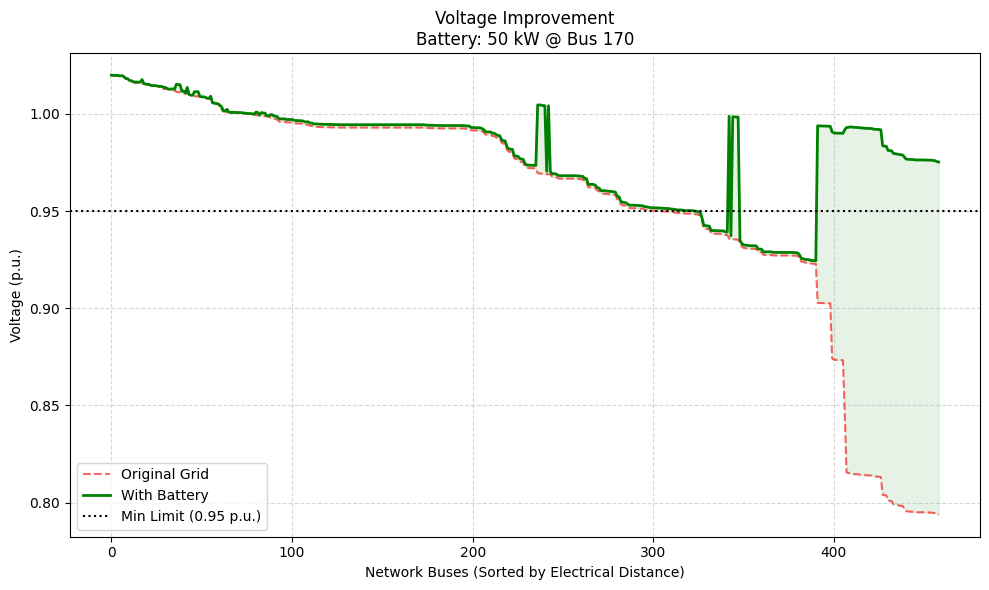

In [84]:
import pandapower as pp
import pandapower.networks as nw
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --- OBJECTIVE FUNCTION ---
def objective_function(net, storage_index, cost_per_kw=500, penalty_v=1e5, penalty_i=1e5):
    """
    Calculates the cost + penalties for the current network state.
    """
    # 1. Investment Cost
    size_mw = net.storage.at[storage_index, 'p_mw']
    storage_cost = abs(size_mw) * 1000 * cost_per_kw

    # 2. Voltage Violations (Under 0.95 pu)
    v_violations = net.res_bus.loc[net.res_bus['vm_pu'] < 0.95, 'vm_pu']
    v_penalty = sum((0.95 - v) for v in v_violations) * penalty_v

    # 3. Congestion Violations (Over 100%)
    l_violations = net.res_line.loc[net.res_line['loading_percent'] > 100, 'loading_percent']
    l_penalty = sum((l - 100) for l in l_violations) * penalty_i

    total_score = storage_cost + v_penalty + l_penalty
    return total_score, v_penalty, l_penalty

# --- OPTIMIZATION ---
def optimize_placement(net, candidate_buses, battery_sizes_kw):
    best_score = float('inf')
    best_plan = None

    # Pre-create a single storage element to move around
    sid = pp.create_storage(net, bus=candidate_buses[0], p_mw=0, max_e_mwh=0)

    total_checks = len(candidate_buses) * len(battery_sizes_kw)
    counter = 0

    print(f"Starting optimization scan ({total_checks} scenarios)...")

    for bus in candidate_buses:
        # Progress check
        if counter % 50 == 0 and counter > 0:
            print(f"  ...scanned {counter} / {total_checks} scenarios...")

        for size_kw in battery_sizes_kw:
            counter += 1

            # Update Decision Variables
            net.storage.at[sid, 'bus'] = bus
            net.storage.at[sid, 'p_mw'] = -1 * (size_kw / 1000.0)
            net.storage.at[sid, 'max_e_mwh'] = (size_kw / 1000.0) * 2

            try:
                pp.runpp(net)
                score, v_pen, l_pen = objective_function(net, sid)

                if score < best_score:
                    best_score = score
                    best_plan = {
                        'bus_id': bus,
                        'bus_name': net.bus.at[bus, 'name'] if 'name' in net.bus.columns else str(bus),
                        'size_kw': size_kw,
                        'total_score': score,
                        'v_penalty': v_pen,
                        'l_penalty': l_pen,
                        'min_voltage': net.res_bus['vm_pu'].min()
                    }

            except pp.LoadflowNotConverged:
                pass

    # Clean up
    net.storage.drop(sid, inplace=True)
    return best_plan

# --- STEP 4: VISUALIZATION  ---
def plot_voltage_improvement(net, best_result):
    """
    Plots the voltage profile of the network before and after optimization.
    """
    print("\nGenerating Voltage Profile Plot...")

    # 1. Get Baseline (No Battery)
    # Ensure storage is empty for baseline
    if not net.storage.empty:
        temp_storage = net.storage.copy()
        net.storage.drop(net.storage.index, inplace=True)
    else:
        temp_storage = None

    try:
        pp.runpp(net)
        results_before = net.res_bus['vm_pu'].copy()
    except:
        print("Error running baseline power flow.")
        return

    # 2. Get Optimized State (With Battery)
    if best_result:
        sid = pp.create_storage(net,
                                bus=best_result['bus_id'],
                                p_mw=-1 * (best_result['size_kw']/1000.0),
                                max_e_mwh=best_result['size_kw']/1000.0 * 2)
        try:
            pp.runpp(net)
            results_after = net.res_bus['vm_pu'].copy()
        except:
            results_after = results_before

        # Clean up temp battery
        net.storage.drop(sid, inplace=True)
    else:
        results_after = results_before

    # 3. Plotting
    # Sort by 'Before' voltage (Highest to Lowest) to create a clean feeder curve

    df_plot = pd.DataFrame({
        'Before': results_before,
        'After': results_after
    })
    df_plot = df_plot.sort_values(by='Before', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 6))

    # Plot curves
    plt.plot(df_plot.index, df_plot['Before'], label='Original Grid', color='red', linestyle='--', alpha=0.6)
    plt.plot(df_plot.index, df_plot['After'], label='With Battery', color='green', linewidth=2)

    # Plot Limit Lines
    plt.axhline(0.95, color='black', linestyle=':', label='Min Limit (0.95 p.u.)')

    # Fill improvement area
    plt.fill_between(df_plot.index, df_plot['Before'], df_plot['After'], color='green', alpha=0.1)

    plt.title(f"Voltage Improvement\nBattery: {best_result['size_kw']} kW @ Bus {best_result['bus_id']}")
    plt.ylabel("Voltage (p.u.)")
    plt.xlabel("Network Buses (Sorted by Electrical Distance)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# --- MAIN EXECUTION ---
if __name__ == "__main__":

    # net = pp.networks.mv_oberrhein()
    # net = create_demo_network()

    print("Network created. Buses:", net.bus.index.tolist())

    # 2. INPUT: Measured Power at Substation
    measured_substation_power_kw = 250

    # 3. RUN STEP 1: Iterative Load Allocation
    print(f"\n--- STEP 1: Allocating {measured_substation_power_kw} kW to loads ---")
    success = allocate_power_by_contracts(
            net=net,
            matches_gdf=matches_gdf,
            substation_power_kw=measured_substation_power_kw
        )

    if success:
        # Check current state before optimization
        min_v = net.res_bus['vm_pu'].min()
        print(f"Current System Min Voltage: {min_v:.4f} p.u.")

        if min_v < 0.95:
            print(">> Voltage violation detected! Optimization required.")
        else:
            print(">> System is healthy, but we will optimize anyway.")

        # 4. SETUP OPTIMIZATION
        # Candidates: All buses except the Slack bus (index 0)
        candidate_buses = net.bus.index[net.bus.index != 0]
        battery_sizes_to_test = [50, 100, 250, 500, 800]

        # 5. RUN OPTIMIZATION
        print(f"\n--- STEP 2: Scanning {len(candidate_buses)} locations x {len(battery_sizes_to_test)} sizes ---")
        best_result = optimize_placement(net, candidate_buses, battery_sizes_to_test)

        print("\n" + "="*30)
        print("OPTIMAL PLACEMENT RESULT")
        print("="*30)
        if best_result:
            print(f"Location          : Bus {best_result['bus_id']} ({best_result['bus_name']})")
            print(f"Battery Size      : {best_result['size_kw']} kW")
            print(f"Resulting Min V   : {best_result['min_voltage']:.4f} p.u.")
            print(f"Voltage Penalty   : {best_result['v_penalty']:.4f}")
            print(f"Total Objective   : {best_result['total_score']:.2f}")


            plot_voltage_improvement(net, best_result)

        else:
            print("No suitable placement found.")

    else:
        print("ERROR: Load allocation did not converge.")

Plotting network (Lite Mode) with highlight on Bus 170...


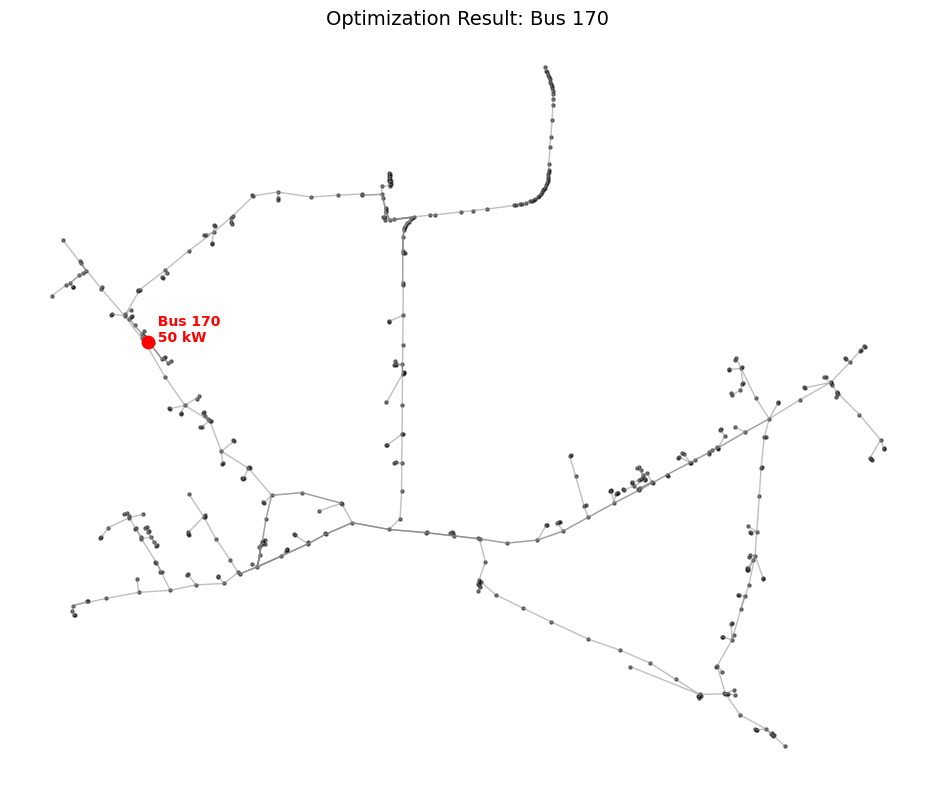

In [86]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import gc # Garbage collector

def visualize_placement_lite(net, best_result):
    """
    A low-memory alternative to pandapower.plotting.
    Draws lines and buses using raw coordinates to save RAM.
    """
    # 1. CLEANUP MEMORY FIRST
    plt.close('all')
    gc.collect()

    print(f"Plotting network (Lite Mode) with highlight on Bus {best_result['bus_id']}...")

    # 2. Extract Data (Fast & Light)
    # Get Bus Coordinates
    if len(net.bus_geodata) == 0:
        print("No geodata found. Cannot plot.")
        return

    xs = net.bus_geodata['x'].values
    ys = net.bus_geodata['y'].values

    # Get Line Segments
    segments = []
    # Create a fast lookup for bus coordinates
    bus_geo = net.bus_geodata[['x', 'y']].to_dict('index')

    for _, row in net.line.iterrows():
        fb = row['from_bus']
        tb = row['to_bus']
        if fb in bus_geo and tb in bus_geo:
            p1 = (bus_geo[fb]['x'], bus_geo[fb]['y'])
            p2 = (bus_geo[tb]['x'], bus_geo[tb]['y'])
            segments.append([p1, p2])

    # 3. Plotting
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot Lines (One single collection object = Very low RAM)
    lc = LineCollection(segments, colors='grey', linewidths=1, alpha=0.5)
    ax.add_collection(lc)

    # Plot All Buses (One scatter object)
    ax.scatter(xs, ys, s=5, c='black', alpha=0.5, zorder=1)

    # 4. Highlight the Best Bus
    target_id = best_result['bus_id']
    tx = net.bus_geodata.at[target_id, 'x']
    ty = net.bus_geodata.at[target_id, 'y']

    ax.scatter([tx], [ty], s=80, c='red', marker='o', zorder=2)

    # Annotation
    ax.text(tx, ty,
            f"  Bus {target_id}\n  {best_result['size_kw']} kW",
            color='red', fontweight='bold', fontsize=10)

    # 5. Final Adjustments
    ax.set_title(f"Optimization Result: Bus {target_id}", fontsize=14)
    ax.autoscale()
    ax.set_aspect('equal')
    ax.axis('off') # Hide axes to save rendering time

    plt.tight_layout()
    plt.show()

    # 6. FORCE CLEANUP AFTER SHOW
    # This ensures RAM is freed immediately after closing the window
    plt.close(fig)
    gc.collect()

# --- USAGE ---
if 'best_result' in locals() and best_result is not None:
    visualize_placement_lite(net, best_result)

# Estimation-Based Volt-Var Control (Operations)


Measure: It reads local Voltage ($V$) and Current ($I$).

Estimate (Partial SE): It runs a recursive algorithm (RLS) to estimate the Thevenin Impedance ($Z_{th}$) of the grid at that specific point. It asks: "How stiff is the grid right now?"

Act: It calculates exactly how much Reactive Power ($Q$) is needed to push the voltage back to the target, based on the estimated impedance.

Initializing Ancillary Services on 459 bus network...
Selected Critical Node: Bus 308
Initial Voltage: 0.7937 p.u.
>> Grid critical. Activating pre-charge (1.0 MVar)...
Starting Simulation (25 steps)...


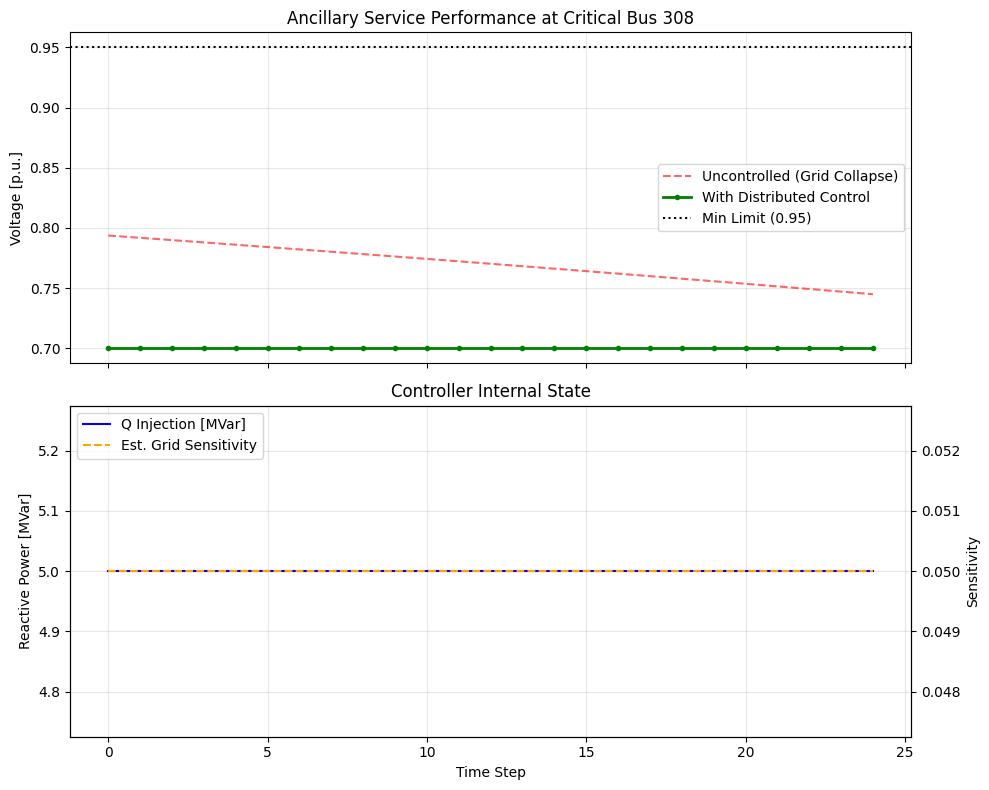

In [87]:
import pandapower as pp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. ESTIMATOR  ---
class AdaptiveVoltVarController:
    def __init__(self, target_v=0.96, max_q_mvar=5.0): # Increased capacity
        self.target_v = target_v
        self.max_q = max_q_mvar
        self.est_sensitivity = 0.05
        self.learning_rate = 0.3
        self.prev_v = None
        self.prev_q = 0.0
        self.last_applied_q_change = 0.0

    def update_and_decide(self, v_meas_pu):
        if self.prev_v is not None:
            dv = v_meas_pu - self.prev_v
            dq = self.prev_q - self.last_applied_q_change
            if abs(dq) > 0.001:
                measured_sensitivity = dv / dq
                if measured_sensitivity > 0.0001:
                    self.est_sensitivity = (1 - self.learning_rate) * self.est_sensitivity + \
                                           (self.learning_rate) * measured_sensitivity

        v_err = self.target_v - v_meas_pu
        q_change = v_err / self.est_sensitivity
        new_q = np.clip(self.prev_q + q_change, -self.max_q, self.max_q)

        self.prev_v = v_meas_pu
        self.last_applied_q_change = new_q - self.prev_q
        self.prev_q = new_q
        return new_q

# --- 2. ROBUST SIMULATION RUNNER ---
def run_ancillary_services_demo(net):
    print(f"Initializing Ancillary Services on {len(net.bus)} bus network...")

    # 1. SETUP & FIND CRITICAL NODE
    try:
        pp.runpp(net)
    except:
        print("CRITICAL ERROR: Base network topology is invalid (diverged at start).")
        return pd.DataFrame(), 0

    critical_bus = net.res_bus['vm_pu'].idxmin()
    initial_v = net.res_bus.at[critical_bus, 'vm_pu']
    print(f"Selected Critical Node: Bus {critical_bus}")
    print(f"Initial Voltage: {initial_v:.4f} p.u.")

    # 2. INSTALL INVERTER (Larger size for this weak grid)
    net.sgen.drop(net.sgen[net.sgen.bus == critical_bus].index, inplace=True)
    inverter_id = pp.create_sgen(net, bus=critical_bus, p_mw=0, q_mvar=0, sn_mva=5.0, name="Ancillary_Unit")

    # 3. CONTROLLER
    controller = AdaptiveVoltVarController(target_v=0.96, max_q_mvar=5.0)

    # 4. LOAD PROFILE (Gentle Ramp)
    load_scalers = np.linspace(1.0, 1.15, 25)

    # 5. PRE-CHARGE LOGIC (Crucial for low voltage start)
    # If starting < 0.92, inject immediately. Don't wait for loop.
    current_q_setpoint = 0.0
    if initial_v < 0.92:
        print(">> Grid critical. Activating pre-charge (1.0 MVar)...")
        current_q_setpoint = 1.0

    original_p = net.load['p_mw'].copy()
    original_q = net.load['q_mvar'].copy()
    logs = {'time': [], 'v_raw': [], 'v_controlled': [], 'q_inj': [], 'est_sens': []}

    print(f"Starting Simulation ({len(load_scalers)} steps)...")

    # --- THE "NO-QUIT" LOOP ---
    for t, scale in enumerate(load_scalers):
        net.load['p_mw'] = original_p * scale
        net.load['q_mvar'] = original_q * scale

        # --- A. UNCONTROLLED (RED LINE) ---
        net.sgen.at[inverter_id, 'q_mvar'] = 0
        try:
            pp.runpp(net)
            v_base = net.res_bus.at[critical_bus, 'vm_pu']
        except pp.LoadflowNotConverged:
            # FORCE GRAPH TO DROP TO SHOW COLLAPSE
            v_base = 0.70

        # --- B. CONTROLLED (GREEN LINE) ---
        # Apply Injection (Negative Q = Capacitive/Boost)
        net.sgen.at[inverter_id, 'q_mvar'] = -current_q_setpoint
        try:
            pp.runpp(net)
            v_ctrl = net.res_bus.at[critical_bus, 'vm_pu']

            # Update Controller Logic normally
            next_q = controller.update_and_decide(v_ctrl)
            current_q_setpoint = next_q

        except pp.LoadflowNotConverged:
            v_ctrl = 0.70  # Even battery failed
            # EMERGENCY LOGIC: If we crashed, max out the battery for next time
            current_q_setpoint = 5.0

        # Log Data
        logs['time'].append(t)
        logs['v_raw'].append(v_base)
        logs['v_controlled'].append(v_ctrl)
        logs['q_inj'].append(current_q_setpoint)
        logs['est_sens'].append(controller.est_sensitivity)

    # Cleanup
    net.load['p_mw'] = original_p
    net.load['q_mvar'] = original_q
    net.sgen.drop(inverter_id, inplace=True)

    return pd.DataFrame(logs), critical_bus

# --- 3. VISUALIZATION ---
def plot_ancillary_results(df, bus_id):
    if df.empty: return

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Plot 1: Voltage Stability
    ax1.set_title(f"Ancillary Service Performance at Critical Bus {bus_id}")
    ax1.plot(df['time'], df['v_raw'], 'r--', label='Uncontrolled (Grid Collapse)', alpha=0.6)
    ax1.plot(df['time'], df['v_controlled'], 'g.-', label='With Distributed Control', linewidth=2)
    ax1.axhline(0.95, color='black', linestyle=':', label='Min Limit (0.95)')
    ax1.set_ylabel("Voltage [p.u.]")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Controller Action
    ax2.set_title("Controller Internal State")
    ax2.plot(df['time'], df['q_inj'], 'b-', label='Q Injection [MVar]')

    ax3 = ax2.twinx()
    ax3.plot(df['time'], df['est_sens'], 'orange', linestyle='--', label='Est. Grid Sensitivity')
    ax3.set_ylabel("Sensitivity")

    ax2.set_ylabel("Reactive Power [MVar]")
    ax2.set_xlabel("Time Step")

    lines, labels = ax2.get_legend_handles_labels()
    lines2, labels2 = ax3.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc='upper left')

    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
if __name__ == "__main__":
    df_results, target_bus = run_ancillary_services_demo(net)
    plot_ancillary_results(df_results, target_bus)

# VPP

<Axes: >

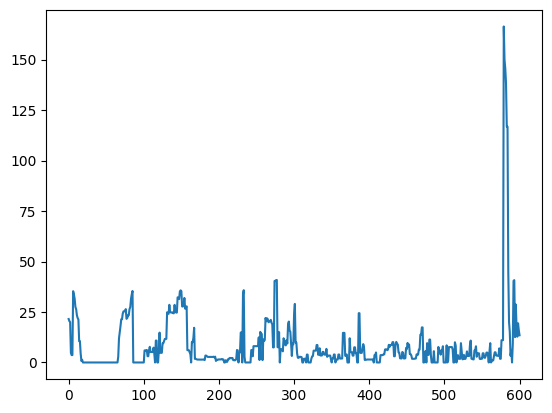

In [101]:
net.res_line['loading_percent'].plot()

Network has no storage! Creating dummy storage fleet...
Initializing VPP with 10 assets from grid model...
Starting Simulation Loop...


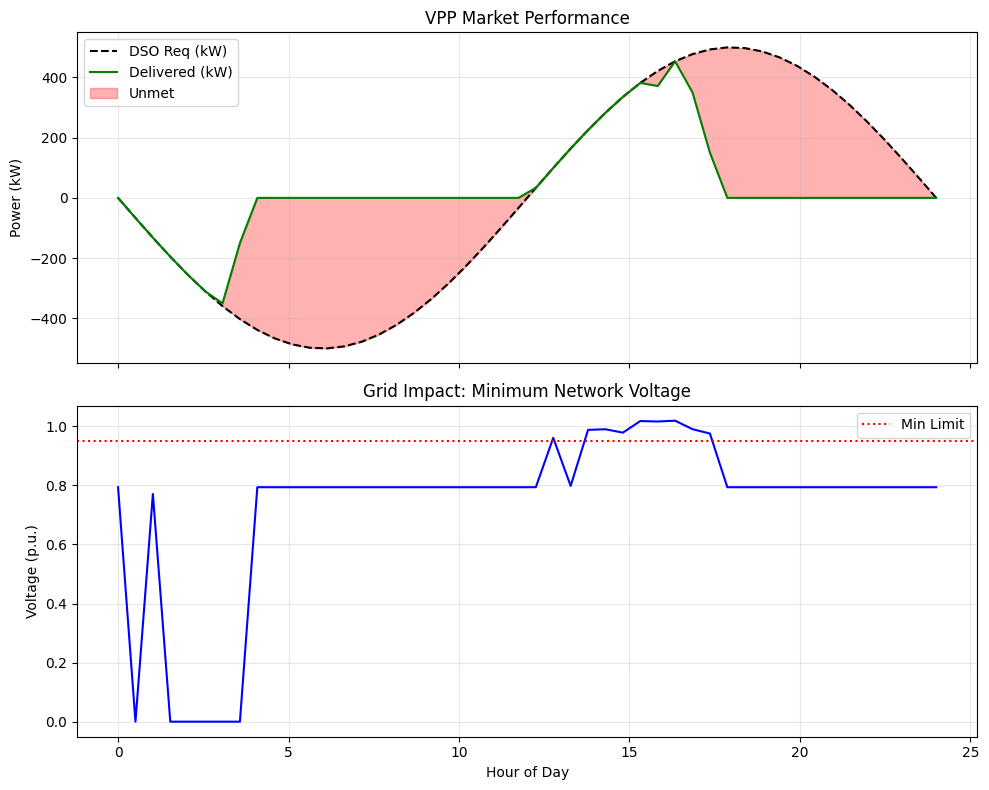

In [95]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandapower as pp


# LAYER 1: THE ASSET (Physics + Comms)

class FlexibleAsset:
    def __init__(self, pp_element_index, p_nom_kw, capacity_kwh, bus_id):
        self.id = pp_element_index    # Link to net.storage index
        self.bus_id = bus_id          # Link to net.bus index
        self.p_nom = p_nom_kw         # Max Power (kW)
        self.capacity = capacity_kwh  # Energy Capacity (kWh)
        self.soc = 0.5                # Initial SOC
        self.reliability = 0.98       # PLC success probability

    def measure_state(self):
        """Returns noisy SOC measurement to Aggregator."""
        noise = np.random.normal(0, 0.02)
        return np.clip(self.soc + noise, 0, 1)

    def update_physics(self, p_setpoint_kw, dt_hours=0.25):
        """
        Updates internal battery chemistry (SOC).
        Returns the ACTUAL power delivered (accounting for failures).
        """
        # 1. Comms Failure Check
        if np.random.random() > self.reliability:
            return 0.0

        # 2. Physical Limits Check
        if p_setpoint_kw > 0 and self.soc <= 0.05: p_setpoint_kw = 0 # Empty
        if p_setpoint_kw < 0 and self.soc >= 0.95: p_setpoint_kw = 0 # Full

        # 3. Update SOC
        energy_change = p_setpoint_kw * dt_hours
        self.soc -= energy_change / self.capacity
        self.soc = np.clip(self.soc, 0, 1)

        return p_setpoint_kw

# LAYER 2: THE AGGREGATOR (Logic)

class RobustAggregator:
    def __init__(self, asset_list):
        self.assets = asset_list # List of FlexibleAsset objects
        self.uncertainty_margin = 0.10

    def solve_robust_dispatch(self, dso_request_kw):
        """
        Allocates DSO request to individual assets based on SOC.
        """
        dispatch_orders = {}
        target = dso_request_kw

        # Strategy:
        # Target > 0 (Discharge/Up): Prioritize High SOC
        # Target < 0 (Charge/Down): Prioritize Low SOC
        reverse_sort = True if target > 0 else False
        mode = 1 if target > 0 else -1

        # Sort assets by reported SOC
        sorted_assets = sorted(self.assets, key=lambda x: x.measure_state(), reverse=reverse_sort)

        remaining = abs(target)

        for asset in sorted_assets:
            if remaining <= 0.1: break

            # Check availability
            soc = asset.measure_state()
            available = 0
            if mode == 1 and soc > 0.15: available = asset.p_nom
            elif mode == -1 and soc < 0.85: available = asset.p_nom

            # Assign
            power = min(available, remaining)
            actual_cmd = power * mode

            dispatch_orders[asset.id] = actual_cmd
            remaining -= power

        return dispatch_orders


# LAYER 3: GRID SIMULATION (Pandapower)

def run_grid_aware_simulation(net):

    # 1. INITIALIZATION: Map net.storage to FlexibleAssets
    if net.storage.empty:
        print("Network has no storage! Creating dummy storage fleet...")
        # Create random storage at 5 random buses
        import random
        candidates = net.bus.index.tolist()
        for i in range(10):
            bus = random.choice(candidates)
            pp.create_storage(net, bus=bus, p_mw=0, max_e_mwh=0.05, name=f"VPP_Asset_{i}")

    fleet = []
    print(f"Initializing VPP with {len(net.storage)} assets from grid model...")

    for idx, row in net.storage.iterrows():
        # Conversion: MW -> kW for logic, but we write MW back to net later
        # We assume the 'p_mw' in net is the rated power
        rated_p_kw = 50.0 # Assigning a default 50kW rating per unit for simulation
        capacity_kwh = 150.0

        asset = FlexibleAsset(pp_element_index=idx,
                              p_nom_kw=rated_p_kw,
                              capacity_kwh=capacity_kwh,
                              bus_id=row['bus'])
        fleet.append(asset)

    aggregator = RobustAggregator(fleet)

    # 2. SCENARIO GENERATION
    steps = 48 # 24 hours @ 30 mins
    time_axis = np.linspace(0, 24, steps)

    # Imbalance Profile (The DSO Request)
    # + = Grid needs power (Discharge), - = Grid has excess (Charge)
    imbalance_req = -500 * np.sin(np.pi * time_axis / 12)

    # 3. TIME LOOP
    results = {'req': [], 'delivered': [], 'min_voltage': [], 'max_line_load': []}

    print("Starting Simulation Loop...")

    for t, req_kw in enumerate(imbalance_req):

        # A. Aggregator Logic
        commands = aggregator.solve_robust_dispatch(req_kw)

        # B. Physical Actuation & Grid Update
        total_delivered_kw = 0

        for asset in fleet:
            cmd_kw = commands.get(asset.id, 0.0)

            # 1. Update Asset Physics (SOC)
            actual_kw = asset.update_physics(cmd_kw, dt_hours=0.5)
            total_delivered_kw += actual_kw

            # 2. Update Pandapower Grid Object
            # Note: Pandapower Storage: p_mw < 0 is Generation (Discharge), p_mw > 0 is Load (Charge)
            # Our Logic: +kw is Discharge. So we must invert sign for Pandapower.
            pp_value_mw = -1 * (actual_kw / 1000.0)
            net.storage.at[asset.id, 'p_mw'] = pp_value_mw

        # C. Run Power Flow (The "Digital Twin" Check)
        try:
            pp.runpp(net)
            min_vm = net.res_bus['vm_pu'].min()
            max_ll = net.res_line['loading_percent'].max()
        except pp.LoadflowNotConverged:
            min_vm = 0.0
            max_ll = 999.0

        # D. Log
        results['req'].append(req_kw)
        results['delivered'].append(total_delivered_kw)
        results['min_voltage'].append(min_vm)
        results['max_line_load'].append(max_ll)

    return pd.DataFrame(results, index=time_axis)


# VISUALIZATION

def plot_results(df):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Plot 1: Market Performance
    ax1.set_title("VPP Market Performance")
    ax1.plot(df.index, df['req'], 'k--', label='DSO Req (kW)')
    ax1.plot(df.index, df['delivered'], 'g-', label='Delivered (kW)')
    ax1.fill_between(df.index, df['req'], df['delivered'], color='red', alpha=0.3, label='Unmet')
    ax1.legend()
    ax1.set_ylabel("Power (kW)")
    ax1.grid(True, alpha=0.3)

    # Plot 2: Grid Impact (Voltage)
    ax2.set_title("Grid Impact: Minimum Network Voltage")
    ax2.plot(df.index, df['min_voltage'], 'b-')
    ax2.axhline(0.95, color='r', linestyle=':', label='Min Limit')
    ax2.set_ylabel("Voltage (p.u.)")
    ax2.set_xlabel("Hour of Day")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- RUNNER ---
if __name__ == "__main__":
    # If not, create a dummy one:
    if 'net' not in locals():
        net = pp.create_empty_network()
        b0 = pp.create_bus(net, vn_kv=20)
        pp.create_ext_grid(net, bus=b0)
        # Create a feeder
        for i in range(5):
            b = pp.create_bus(net, vn_kv=20)
            pp.create_line(net, from_bus=b0 if i==0 else b-1, to_bus=b, length_km=1, std_type="NA2XS2Y 1x150 RM/25 12/20 kV")
            # Add existing load
            pp.create_load(net, bus=b, p_mw=0.2)

    df_res = run_grid_aware_simulation(net)
    plot_results(df_res)

VPP Initialized: 100 assets.
Total Theoretical Power: 500 kW
Starting Day-Ahead Ancillary Services Operation...


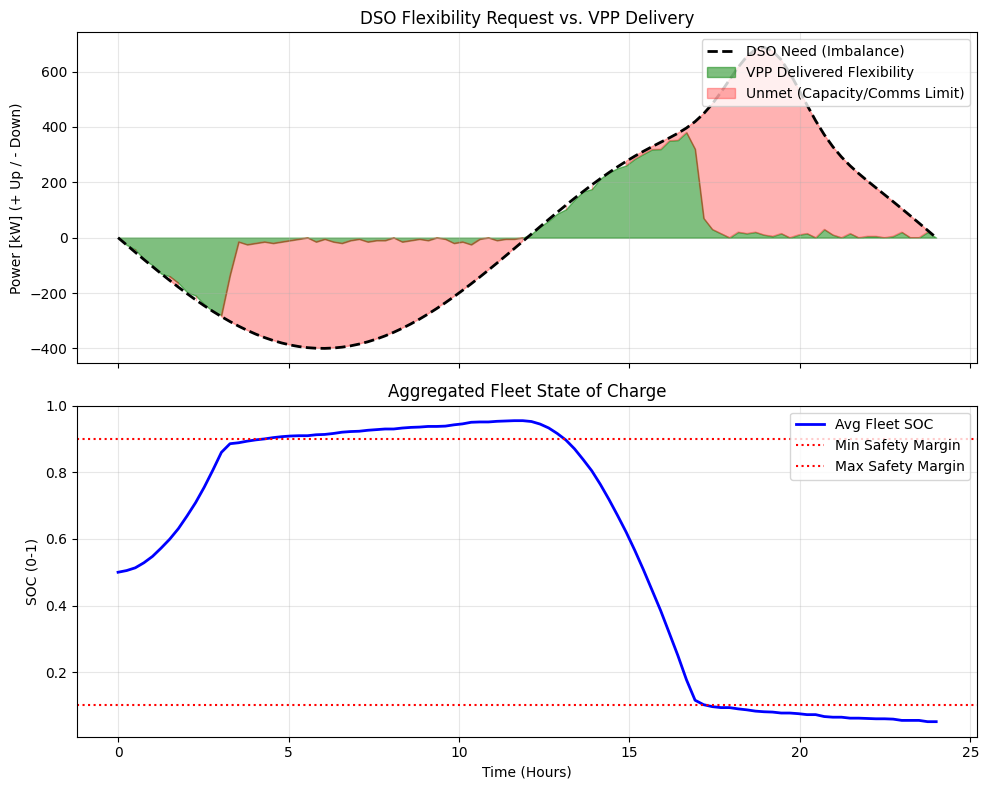

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog


# LAYER 1: THE ASSET (Physics + Comms)

class FlexibleAsset:
    def __init__(self, uid, p_nom_kw, capacity_kwh, reliability_score=0.98):
        self.id = uid
        self.p_nom = p_nom_kw       # Max Power
        self.capacity = capacity_kwh # Energy Capacity
        self.soc = 0.5              # State of Charge (0.0 - 1.0)
        self.reliability = reliability_score # Simulates PLC success rate

    def measure_state(self):
        """
        Partial State Estimation:
        Returns noisy measurement of SOC to the Aggregator.
        """
        noise = np.random.normal(0, 0.02) # 2% measurement error
        reported_soc = np.clip(self.soc + noise, 0, 1)
        return reported_soc

    def execute_dispatch(self, p_setpoint_kw, dt_hours=0.25):
        """
        Actuate the device.
        Includes Communication Reliability check (PLC Packet Loss).
        """
        # 1. Simulating Communication Failure
        if np.random.random() > self.reliability:
            return 0.0 # Packet lost, asset did nothing

        # 2. Physical Limits Check
        # Check if full or empty
        if p_setpoint_kw > 0 and self.soc <= 0.05: p_setpoint_kw = 0
        if p_setpoint_kw < 0 and self.soc >= 0.95: p_setpoint_kw = 0

        # 3. Apply Physics
        energy_change = p_setpoint_kw * dt_hours
        self.soc -= energy_change / self.capacity
        self.soc = np.clip(self.soc, 0, 1)

        return p_setpoint_kw # Return actual power delivered


# LAYER 2: THE AGGREGATOR (Optimization)

class RobustAggregator:
    def __init__(self, asset_list):
        self.assets = asset_list
        self.uncertainty_margin = 0.10 # Reserve 10% capacity for robustness

    def calculate_aggregate_capability(self):
        """
        Aggregates individual assets into a total VPP curve.
        """
        total_p_charge = 0
        total_p_discharge = 0

        for a in self.assets:
            # We use reported SOC (with noise)
            est_soc = a.measure_state()

            # Can we discharge? (Only if SOC > 10% + Margin)
            if est_soc > (0.05 + self.uncertainty_margin):
                total_p_discharge += a.p_nom

            # Can we charge? (Only if SOC < 90% - Margin)
            if est_soc < (0.95 - self.uncertainty_margin):
                total_p_charge += a.p_nom

        return total_p_discharge, total_p_charge

    def solve_robust_dispatch(self, dso_request_kw):
        """
        OPTIMIZATION ENGINE:
        Allocates the DSO request across assets.
        Uses a Robust Heuristic (Weighted dispatch based on SOC).
        """
        # 1. Identify Available Assets
        dispatch_orders = {}
        target = dso_request_kw
        total_delivered_plan = 0

        # Strategy:
        # If Request > 0 (Up/Injection): Prioritize High SOC assets
        # If Request < 0 (Down/Absorption): Prioritize Low SOC assets

        if target > 0:
            # Sort descending by SOC
            sorted_assets = sorted(self.assets, key=lambda x: x.measure_state(), reverse=True)
            mode = 1
        else:
            # Sort ascending by SOC
            sorted_assets = sorted(self.assets, key=lambda x: x.measure_state(), reverse=False)
            mode = -1

        remaining = abs(target)

        for asset in sorted_assets:
            if remaining <= 0.1: break

            # Robust Capacity Check
            soc = asset.measure_state()

            # Determine max capability of this specific asset right now
            if mode == 1: # Discharge
                available = asset.p_nom if soc > 0.15 else 0
            else: # Charge
                available = asset.p_nom if soc < 0.85 else 0

            # Assign
            power = min(available, remaining)
            actual_cmd = power * mode # Apply sign

            dispatch_orders[asset.id] = actual_cmd
            remaining -= power
            total_delivered_plan += actual_cmd

        return dispatch_orders, total_delivered_plan

# LAYER 3: THE DSO (Grid Simulation)

def run_ancillary_market_simulation():
    # 1. Initialize Fleet (The VPP)
    # 100 small residential batteries (5kW / 13kWh)
    # Reliability 95% (simulating PLC noise)
    fleet = [FlexibleAsset(i, 5, 13, 0.95) for i in range(100)]
    aggregator = RobustAggregator(fleet)

    print(f"VPP Initialized: {len(fleet)} assets.")
    print(f"Total Theoretical Power: {len(fleet)*5} kW")

    # 2. Define DSO Scenario (24 Hours)
    # The DSO calculates 'Imbalance' based on forecast vs actual.
    # Positive = Grid needs Power (Up)
    # Negative = Grid has excess Power (Down)
    steps = 96 # 15-minute intervals
    time_axis = np.linspace(0, 24, steps)

    # Create a synthetic imbalance signal (Solar curve inverted + Evening Peak)
    imbalance_forecast = -400 * np.sin(np.pi * time_axis / 12) # Solar excess at noon
    imbalance_forecast += 300 * np.exp(-0.5 * (time_axis - 19)**2) # Evening peak

    # 3. Run Simulation Loop
    results = {'req': [], 'delivered': [], 'reliability': [], 'avg_soc': []}

    print("Starting Day-Ahead Ancillary Services Operation...")

    for t, req_kw in enumerate(imbalance_forecast):

        # A. Aggregator Optimization
        # The aggregator calculates the best dispatch to meet req_kw
        commands, planned_total = aggregator.solve_robust_dispatch(req_kw)

        # B. Real-Time Execution (Communication & Physics)
        realized_power = 0
        soc_list = []

        for asset in fleet:
            cmd = commands.get(asset.id, 0.0)

            # Asset attempts to execute (may fail due to PLC error or SOC limits)
            p_actual = asset.execute_dispatch(cmd, dt_hours=0.25)

            realized_power += p_actual
            soc_list.append(asset.soc)

        # C. Metric Calculation
        # Did we meet the DSO request?
        performance = 0
        if abs(req_kw) > 1:
            performance = realized_power / req_kw * 100
        else:
            performance = 100 # No request, perfect performance

        # Log
        results['req'].append(req_kw)
        results['delivered'].append(realized_power)
        results['reliability'].append(performance)
        results['avg_soc'].append(np.mean(soc_list))

    return pd.DataFrame(results, index=time_axis)


# VISUALIZATION

def plot_vpp_performance(df):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # 1. Ancillary Service Delivery

    ax1.set_title("DSO Flexibility Request vs. VPP Delivery")
    ax1.plot(df.index, df['req'], 'k--', label='DSO Need (Imbalance)', linewidth=2)
    ax1.fill_between(df.index, 0, df['delivered'], color='green', alpha=0.5, label='VPP Delivered Flexibility')

    # Highlight Failure areas
    deficit = df['req'] - df['delivered']
    ax1.fill_between(df.index, df['delivered'], df['req'], where=abs(deficit)>5, color='red', alpha=0.3, label='Unmet (Capacity/Comms Limit)')

    ax1.set_ylabel("Power [kW] (+ Up / - Down)")
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)

    # 2. Fleet Status (Robustness)
    ax2.set_title("Aggregated Fleet State of Charge")
    ax2.plot(df.index, df['avg_soc'], 'b-', linewidth=2, label='Avg Fleet SOC')
    ax2.axhline(0.1, color='r', linestyle=':', label='Min Safety Margin')
    ax2.axhline(0.9, color='r', linestyle=':', label='Max Safety Margin')
    ax2.set_ylabel("SOC (0-1)")
    ax2.set_xlabel("Time (Hours)")
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    df_results = run_ancillary_market_simulation()
    plot_vpp_performance(df_results)

#FDIR Agent

Base Network Created.


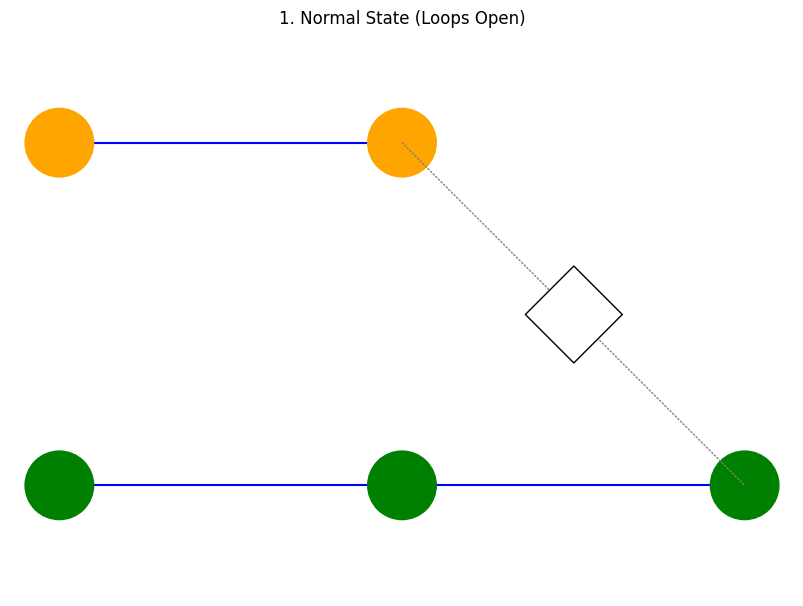


[FDIR] Phase 1: Detection & Isolation analyzing...
  -> OVERCURRENT DETECTED on Line 0: 99.00 kA
  -> ISOLATING Line 0 (Opening Breakers)...


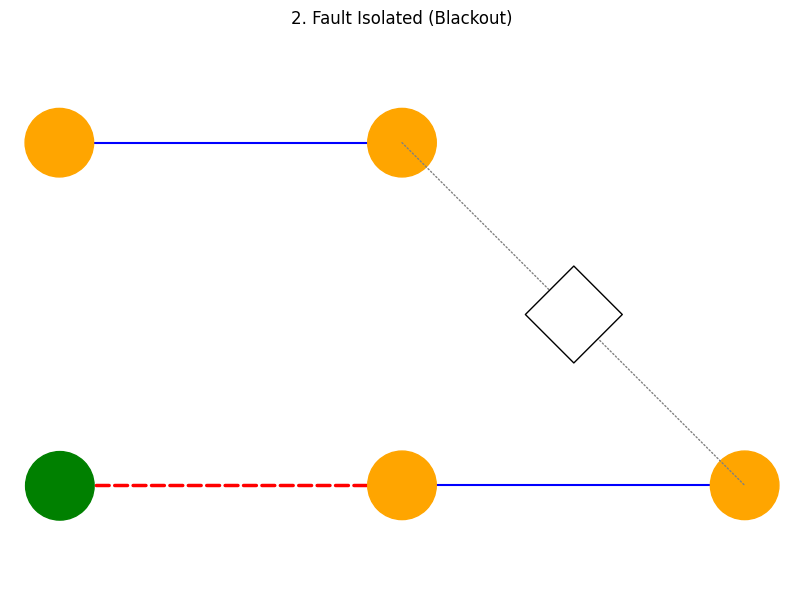


[FDIR] Phase 2: Recovery Planning...
  -> 4 buses are in Blackout: [1, 2, 3, 4]
  -> Found 0 candidate Tie-Switches.


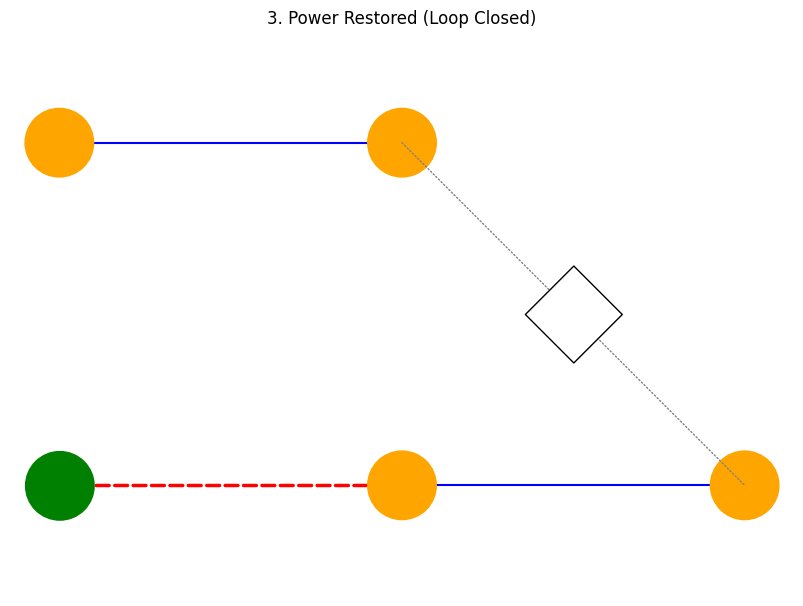

In [89]:
import pandapower as pp
import pandapower.topology as top
import pandapower.plotting as pplot
import matplotlib.pyplot as plt
import networkx as nx

# --- 1. VISUALIZATION FUNCTION ---
def plot_fdir_status(net, title="Network Status"):
    """
    Plots the network state safely.
    """

    if "bus_geodata" not in net or net.bus_geodata.empty:
        try:
            pplot.create_generic_coordinates(net, overwrite=True)
        except Exception as e:
            print(f"Warning: Could not generate coordinates: {e}")

    # Determine Topology (Energized vs Dead)
    energized_buses = []
    if len(net.ext_grid) > 0:
        try:
            slack_bus = net.ext_grid.bus.iloc[0]
            energized_buses = top.calc_distance_to_bus(net, slack_bus).index
        except:
            pass

    dead_buses = list(set(net.bus.index) - set(energized_buses))

    # Build Plot Layers
    collections = []

    # Layer A: Healthy Lines (Blue)
    healthy_lines = net.line[net.line.in_service == True].index
    if len(healthy_lines) > 0:
        collections.append(pplot.create_line_collection(net, lines=healthy_lines, color="blue", linewidth=1.5))

    # Layer B: Faulted Lines (Red Dashed)
    faulty_lines = net.line[net.line.in_service == False].index
    if len(faulty_lines) > 0:
        collections.append(pplot.create_line_collection(net, lines=faulty_lines, color="red", linewidth=2.5, linestyle="--"))

    # Layer C: Energized Buses (Green)
    if len(energized_buses) > 0:
        collections.append(pplot.create_bus_collection(net, buses=energized_buses, size=0.1, color="green", zorder=2))

    # Layer D: Blackout Buses (Orange)
    if len(dead_buses) > 0:
        collections.append(pplot.create_bus_collection(net, buses=dead_buses, size=0.1, color="orange", zorder=2))

    # Layer E: Switches
    collections.append(pplot.create_bus_bus_switch_collection(net, size=0.2, color="black", zorder=3))

    # Draw
    try:
        pplot.draw_collections(collections, figsize=(8,6))
        plt.title(title)
        plt.show()
    except Exception as e:
        print(f"Plotting failed: {e}")

# --- 2. FDIR AGENT ---
class FDIR_Agent:
    def __init__(self, net):
        self.net = net
        self.mg = top.create_nxgraph(net, include_lines=True, include_trafos=True)

    def detect_and_locate(self, i_measurements_ka):
        print("\n[FDIR] Phase 1: Detection & Isolation analyzing...")
        faulty_lines = []

        # Detection Loop
        for line_idx in self.net.line.index:
            i_flow = i_measurements_ka.get(line_idx, 0.0)
            i_max = self.net.line.at[line_idx, 'max_i_ka']

            if i_flow > 2.0 * i_max:
                print(f"  -> OVERCURRENT DETECTED on Line {line_idx}: {i_flow:.2f} kA")
                faulty_lines.append(line_idx)

        if not faulty_lines: return None

        # Isolation Logic
        target_line = faulty_lines[0]
        print(f"  -> ISOLATING Line {target_line} (Opening Breakers)...")
        self.net.line.at[target_line, 'in_service'] = False
        return target_line

    def plan_recovery(self):
        print("\n[FDIR] Phase 2: Recovery Planning...")

        # Identify Dead Zones
        slack_bus = self.net.ext_grid.bus.iloc[0]
        try:
            supplied_buses = top.calc_distance_to_bus(self.net, slack_bus).index
        except:
            supplied_buses = []

        dead_buses = list(set(self.net.bus.index) - set(supplied_buses))

        if not dead_buses:
            print("  -> No outage zones found.")
            return

        print(f"  -> {len(dead_buses)} buses are in Blackout: {dead_buses}")

        # Find Candidates
        candidates = []
        for idx, sw in self.net.switch.iterrows():
            if not sw['closed'] and sw['et'] == 'b':
                b_from = sw['bus']
                b_to = sw['element']

                # Check if switch bridges Live <-> Dead
                connected_to_dead = (b_from in dead_buses) or (b_to in dead_buses)
                connected_to_live = (b_from in supplied_buses) or (b_to in supplied_buses)

                if connected_to_dead and connected_to_live:
                    candidates.append(idx)

        print(f"  -> Found {len(candidates)} candidate Tie-Switches.")

        # Simulate Closing
        for sw_idx in candidates:
            print(f"  -> Testing Tie-Switch {sw_idx}...")
            self.net.switch.at[sw_idx, 'closed'] = True # Close

            try:
                pp.runpp(self.net)
                print(f"     SUCCESS! Power Restored.")
                return
            except pp.LoadflowNotConverged:
                print("     FAILED. Grid collapse.")
                self.net.switch.at[sw_idx, 'closed'] = False # Re-open

# --- 3. SCENARIO RUNNER ---
def run_fdir_simulation():
    # Setup Network
    net = pp.create_empty_network()

    # Grid A
    b_sub1 = pp.create_bus(net, vn_kv=20, name="Sub A")
    pp.create_ext_grid(net, b_sub1)
    b1 = pp.create_bus(net, vn_kv=20, name="Feed A1")
    b2 = pp.create_bus(net, vn_kv=20, name="Feed A2")

    # Grid B (Backup)
    b_sub2 = pp.create_bus(net, vn_kv=20, name="Sub B")
    pp.create_ext_grid(net, b_sub2)
    b3 = pp.create_bus(net, vn_kv=20, name="Feed B1")

    # Lines
    l0 = pp.create_line(net, b_sub1, b1, length_km=2, std_type="NA2XS2Y 1x150 RM/25 12/20 kV")
    l1 = pp.create_line(net, b1, b2, length_km=2, std_type="NA2XS2Y 1x150 RM/25 12/20 kV")
    l2 = pp.create_line(net, b_sub2, b3, length_km=2, std_type="NA2XS2Y 1x150 RM/25 12/20 kV")

    # Loads
    pp.create_load(net, b1, p_mw=2.0)
    pp.create_load(net, b2, p_mw=2.0)
    pp.create_load(net, b3, p_mw=1.0)

    # Tie Switch
    pp.create_switch(net, bus=b3, element=b2, et='b', closed=False, type='LBS')

    print("Base Network Created.")

    # PLOT 1: Normal
    plot_fdir_status(net, "1. Normal State (Loops Open)")

    # Fault Simulation
    simulated_currents = {l0: 99.0}

    # FDIR Execution
    fdir = FDIR_Agent(net)
    faulty_line = fdir.detect_and_locate(simulated_currents)

    # PLOT 2: Isolated
    if faulty_line is not None:
        plot_fdir_status(net, "2. Fault Isolated (Blackout)")

        fdir.plan_recovery()

        # PLOT 3: Restored
        plot_fdir_status(net, "3. Power Restored (Loop Closed)")

if __name__ == "__main__":
    run_fdir_simulation()

In [90]:
net

This pandapower network includes the following parameter tables:
   - bus (459 elements)
   - load (145 elements)
   - ext_grid (1 element)
   - line (601 elements)
   - bus_geodata (459 elements)
   - line_geodata (601 elements)
 and the following results tables:
   - res_bus (459 elements)
   - res_line (601 elements)
   - res_ext_grid (1 element)
   - res_load (145 elements)
   - res_sgen (1 element)

# Stuff

(Nexans/Eurocabos BT) Tabela 1A – Cabos Isolados com PVC 70 ºC.
Eurocabos https://www.eurocabos.com.br/files/cabos/nexans-ficap/cabos-baixa-tensao/nexans-bt.pdf

Usas a parte: “Cabo Tripolar e Tetrapolar – Sistema Trifásico” (coluna da direita da tabela).

{Fórmula para obter $R$ e $X$ a partir da queda de tensão unitária}

Na Tabela 1A (pág. 42 do catálogo Nexans/Eurocabos), para cabos PVC a $70\,^{\circ}\mathrm{C}$, em:

    * sistema trifásico,
    * cabo tripolar/tetrapolar,
    * com duas colunas para fatores de potência $\mathrm{F.P} = 0{,}80$ e $\mathrm{F.P} = 0{,}92$,
    * valores em $\mathrm{V/(A\cdot km)}$ para cada secção (1{,}5 -- 500 mm\textsuperscript{2}),

pretende-se determinar a resistência $R$ e a reatância $X$ em $\Omega/\mathrm{km}$.

Para um circuito trifásico, a queda de tensão é
\begin{equation}
    \Delta V = \sqrt{3}\, I \bigl(R\cos\varphi + X\sin\varphi\bigr) L.
\end{equation}

Logo, a queda de tensão unitária (por A e por km) é
\begin{equation}
    d(\varphi)
    = \frac{\Delta V}{I\,L}
    = \sqrt{3}\,\bigl(R\cos\varphi + X\sin\varphi\bigr).
\end{equation}

A tabela fornece dois valores para a mesma secção, com dois fatores de potência:
\begin{align}
    d_{0,8}   &\quad\text{(coluna F.P $= 0{,}80$)},\\
    d_{0,92}  &\quad\text{(coluna F.P $= 0{,}92$)}.
\end{align}

Fica-se então com o sistema
\begin{equation}
\begin{cases}
    d_{0,8}  = \sqrt{3}\,\bigl(R\cdot 0{,}8 + X\cdot \sin\varphi_{0,8}\bigr),\\[4pt]
    d_{0,92} = \sqrt{3}\,\bigl(R\cdot 0{,}92 + X\cdot \sin\varphi_{0,92}\bigr),
\end{cases}
\end{equation}
onde
\begin{align}
    \sin\varphi_{0,8}   &= \sqrt{1 - 0{,}8^{2}},\\
    \sin\varphi_{0,92}  &= \sqrt{1 - 0{,}92^{2}}.
\end{align}

Dividindo ambos os lados por $\sqrt{3}$, define-se
\begin{align}
    d_1' &= \frac{d_{0,8}}{\sqrt{3}},\\
    d_2' &= \frac{d_{0,92}}{\sqrt{3}},
\end{align}
e o sistema escreve-se como
\begin{equation}
\begin{cases}
    d_1' = R\cos\varphi_{1} + X\sin\varphi_{1},\\[4pt]
    d_2' = R\cos\varphi_{2} + X\sin\varphi_{2},
\end{cases}
\end{equation}
com $\varphi_{1} = \varphi_{0,8}$ e $\varphi_{2} = \varphi_{0,92}$.

Resolvendo o sistema linear, obtém-se
\begin{equation}
    R =
    \frac{
        d_1'\,\sin\varphi_{2} - d_2'\,\sin\varphi_{1}
    }{
        \cos\varphi_{1}\,\sin\varphi_{2} - \cos\varphi_{2}\,\sin\varphi_{1}
    },
\end{equation}
\begin{equation}
    X =
    \frac{
        d_2'\,\cos\varphi_{1} - d_1'\,\cos\varphi_{2}
    }{
        \cos\varphi_{1}\,\sin\varphi_{2} - \cos\varphi_{2}\,\sin\varphi_{1}
    }.
\end{equation}

As unidades são:

   * $d$ em $\mathrm{V/(A\cdot km)}$,
   * $R$ e $X$ resultam em $\Omega/\mathrm{km}$.



In [ ]:
import math

def rx_from_voltage_drop(d_fp08, d_fp092, fp1=0.80, fp2=0.92):
    """
    d_fp08, d_fp092 em V/(A·km) para cabo tripolar/tetrapolar trifásico
    devolve R e X em ohm/km
    """
    k = math.sqrt(3.0)

    cos1, cos2 = fp1, fp2
    sin1 = math.sqrt(1.0 - cos1**2)
    sin2 = math.sqrt(1.0 - cos2**2)

    d1 = d_fp08 / k
    d2 = d_fp092 / k

    denom = cos1 * sin2 - cos2 * sin1
    R = (d1 * sin2 - d2 * sin1) / denom
    X = (d2 * cos1 - d1 * cos2) / denom

    return R, X

cable_rx = {}
for name, d in drops.items():
    R, X = rx_from_voltage_drop(d["d08"], d["d092"])
    cable_rx[name] = {"r_ohm_per_km": R, "x_ohm_per_km": X}


#Nexans/Eurocabos BT catálogo, tabela de queda de tensão unitária em V/(A·km) (Tabela 1B – cabos com termofixos 90 °C, linha “Trifásico”).
# d08 e d092 em V/(A·km), TRIFÁSICO, Tabela 1B FICAP 90 °C

drops = {
    "VV 4x2.5":        {"d08": 14.30, "d092": 16.34},  # secção 2,5 mm²
    "VV 4x4":          {"d08":  8.96, "d092": 10.20},  # 4 mm²
    "VAV 4x6":         {"d08":  6.03, "d092":  6.84},  # 6 mm²
    "VAV 4x10":        {"d08":  3.57, "d092":  4.01},  # 10 mm²

    # secção 16 e 25 mm²
    "VAV 4x16":        {"d08":  2.33, "d092":  2.58},  # 16 mm²
    "VAV 3x16 + 10":   {"d08":  2.33, "d092":  2.58},  # usa secção 16 mm²

    "VAV 3x25 + 16":   {"d08":  1.56, "d092":  1.71},  # 25 mm²
    "VAV 3x35+16":     {"d08":  1.16, "d092":  1.24},  # 35 mm²
}

cable_rx = {
    "VV 4x2.5":      {"r_ohm_per_km": 10.1676, "x_ohm_per_km": 0.2034},
    "VV 4x4":        {"r_ohm_per_km":  6.3152, "x_ohm_per_km": 0.2014},
    "VAV 4x6":       {"r_ohm_per_km":  4.2145, "x_ohm_per_km": 0.1830},
    "VAV 4x10":      {"r_ohm_per_km":  2.4377, "x_ohm_per_km": 0.1850},


    "VAV 4x16":      {"r_ohm_per_km":  1.5370, "x_ohm_per_km": 0.1927},
    "VAV 3x16 + 10": {"r_ohm_per_km":  1.5370, "x_ohm_per_km": 0.1927},

    "VAV 3x25 + 16": {"r_ohm_per_km":  1.0038, "x_ohm_per_km": 0.1627},
    "VAV 3x35+16":   {"r_ohm_per_km":  0.7006, "x_ohm_per_km": 0.1821},
}


# === 1) calculadoras R/X a partir de d08, d092 ===

def rx_trifasico(d08, d092):
    """d08, d092 em V/(A·km); devolve R, X em ohm/km (sist. trifásico)"""
    k = math.sqrt(3.0)
    cos1, cos2 = 0.80, 0.92
    sin1, sin2 = math.sqrt(1-cos1**2), math.sqrt(1-cos2**2)
    d1, d2 = d08/k, d092/k
    denom = cos1*sin2 - cos2*sin1
    R = (d1*sin2 - d2*sin1) / denom
    X = (d2*cos1 - d1*cos2) / denom
    return R, X

def rx_monofasico(d08, d092):
    """d08, d092 em V/(A·km); devolve R, X em ohm/km (sist. monofásico)"""
    k = 2.0
    cos1, cos2 = 0.80, 0.92
    sin1, sin2 = math.sqrt(1-cos1**2), math.sqrt(1-cos2**2)
    d1, d2 = d08/k, d092/k
    denom = cos1*sin2 - cos2*sin1
    R = (d1*sin2 - d2*sin1) / denom
    X = (d2*cos1 - d1*cos2) / denom
    return R, X


def rx_monofasico(d08, d092, fp1=0.80, fp2=0.92):
    k = 2.0
    cos1, cos2 = fp1, fp2
    sin1, sin2 = math.sqrt(1-cos1**2), math.sqrt(1-cos2**2)
    d1, d2 = d08/k, d092/k
    denom = cos1*sin2 - cos2*sin1
    R = (d1*sin2 - d2*sin1) / denom
    X = (d2*cos1 - d1*cos2) / denom
    return R, X

R_XV_2x10, X_XV_2x10 = rx_monofasico(3.50, 3.96)
# R_XV_2x10 ≈ 2.106 ohm/km, X_XV_2x10 ≈ 0.109 ohm/km

#R_VV_2x4, X_VV_2x4 = rx_monofasico(d08_vv_2x4, d092_vv_2x4)

#R_V10, X_V10 = rx_monofasico(d08_V10, d092_V10)

# - VV 2x4 -> Tabela 1A, "Cabo Unipolar e Bipolar – Sistema Monofásico", secção 4 mm²
# - XV/VAV 4x6, 4x10 -> Tabela 1B, "Trifásico", secções 6 e 10 mm²
# - XV 2x10, V 10 -> Tabela 1B (ou 1A se for PVC), "Monofásico", secção 10 mm²
# - XS 2x6, XS 4x6 -> **não** vêm na Tabela 1A/1B; usa DIT-C14-100 (R, X diretos)
# - LSVAV 4x50 -> idem DIT-C14-100 (R, X diretos)

# (lidos da Tabela 1B, TRIFÁSICO; XLPE 90 °C):
drops_trif = {
    "VAV 4x6":   {"d08": 6.03, "d092": 6.80},   # 6 mm²
    "VAV 4x10":  {"d08": 3.57, "d092": 3.96},   # 10 mm²
    "XV  4x6":   {"d08": 6.03, "d092": 6.80},   # 6 mm²
    "XV  4x10":  {"d08": 3.57, "d092": 3.96},   # 10 mm²
}
# (Tabela 1B – blocos “Trifásico”, ver página 42 do PDF.)  #

# FALTA preencher a partir do PDF:
drops_mono = {
    # Tabela 1B, "Monofásico", XLPE 90 °C (ou Tabela 1A, PVC 70 °C, se aplicável):
    "XV  2x10": {"d08": None, "d092": None},    # 10 mm² (monofásico)
    "V 10":     {"d08": None, "d092": None},    # 10 mm² (monofásico)

    # Tabela 1A (PVC 70 °C), "Cabo Unipolar e Bipolar – Sistema Monofásico":
    "VV 2x4":   {"d08": None, "d092": None},    # 4 mm² (monofásico)
}

# === 3) Cálculo automático R/X para os que têm d08/d092 ===
cable_rx = {}
for name, d in drops_trif.items():
    R, X = rx_trifasico(d["d08"], d["d092"])
    cable_rx[name] = {"r_ohm_per_km": round(R, 4), "x_ohm_per_km": round(X, 4)}

for name, d in drops_mono.items():
    if d["d08"] is not None and d["d092"] is not None:
        R, X = rx_monofasico(d["d08"], d["d092"])
        cable_rx[name] = {"r_ohm_per_km": round(R, 4), "x_ohm_per_km": round(X, 4)}

# === 4) LXS / LSVAV / XS – usar valores normativos (R e X) da DIT-C14-100 ===
# (ex.: LXS 4x70, LXS 4x25+16, LSVAV 4x95, LSVAV 4x50, XS 2x6, XS 4x6)
# PDF da DIT-C14-100 (E-REDES), Quadros C1/C2, e copias R (Ω/km) e X (Ω/km).  #
cables_normativos = {
    "LXS 4x70 + 16": {"r_ohm_per_km": None, "x_ohm_per_km": None, "source": "E-REDES DIT-C14-100 (Quadro C1)"},
    "LXS 4x25+16":   {"r_ohm_per_km": None, "x_ohm_per_km": None, "source": "E-REDES DIT-C14-100 (Quadro C1)"},
    "LSVAV 4x95":    {"r_ohm_per_km": None, "x_ohm_per_km": None, "source": "E-REDES DIT-C14-100 (Quadro C2)"},
    "LSVAV 4x50":    {"r_ohm_per_km": None, "x_ohm_per_km": None, "source": "E-REDES DIT-C14-100 (Quadro C2)"},
    "XS 2x6":        {"r_ohm_per_km": None, "x_ohm_per_km": None, "source": "E-REDES DIT-C14-100 (ou documento técnico XS)"},
    "XS 4x6":        {"r_ohm_per_km": None, "x_ohm_per_km": None, "source": "E-REDES DIT-C14-100 (ou documento técnico XS)"},
}


In [ ]:
import geopandas as gpd
import plotly.graph_objects as go
import pandas as pd

# --- 2.1 Use the same color map ---
color_map = {
    'Apoios BT': 'gray',
    'Coluna IP': 'darkgray',
    'Braco IP': 'lightgray',
    'Ponto de Entrega de Energia_PEE': 'red',
    'Caixa_Armario': 'orange',
    'Posto de Transformacao_PT_PTS': 'purple',
    'Caixa de Visita': 'brown',
    'Troco BT PT09': 'blue'
}

# --- 2.2 Create an empty Plotly figure ---
fig = go.Figure()

print("--- Gerando mapa interativo Plotly com etiquetas nas linhas ---")

# --- 2.3 Loop through layers and add them as "traces" ---
all_lons = []
all_lats = []

# PLOT LINES FIRST
try:
    for name, gdf in all_geodata.items():
        if gdf.empty or not hasattr(gdf.geometry, 'geom_type') or 'LineString' not in gdf.geom_type.unique():
            continue

        color = color_map.get(name, 'black')
        gdf_4326 = gdf.to_crs("EPSG:4326")

        # Inicializar listas para coordenadas e para as etiquetas de hover
        lons, lats, hover_texts = [], [], []

        # Iterar sobre cada linha (row) para aceder à sua geometria e atributos
        for index, row in gdf_4326.iterrows():
            # Construir a etiqueta de hover específica para esta linha
            label_for_this_line = name  # Etiqueta padrão é o nome da camada
            if name == 'Troco BT PT09':
                # Tentar usar a coluna 'id' para uma etiqueta mais descritiva
                if 'id' in row and pd.notna(row['id']):
                    label_for_this_line = f"Troço ID: {row['id']}"
                else:
                    label_for_this_line = 'Troço BT (ID não disponível)'

            # Extrair as coordenadas da linha
            line = row.geometry
            x, y = line.xy

            # Adicionar as coordenadas às listas
            lons.extend(list(x))
            lats.extend(list(y))

            # Adicionar a etiqueta repetidamente para cada ponto da linha
            hover_texts.extend([label_for_this_line] * len(x))

            # Adicionar uma quebra (None) para separar as linhas no plot
            lons.append(None)
            lats.append(None)
            hover_texts.append(None)

        all_lons.extend(lons)
        all_lats.extend(lats)

        # CHANGE: Use go.Scattermapbox
        fig.add_trace(go.Scattermapbox(
            lat=lats,
            lon=lons,
            mode='lines',
            line=dict(width=2.5, color=color),
            name=name,
            hoverinfo='text',
            hovertext=hover_texts
        ))
except NameError:
    print("Error: 'all_geodata' is not defined. Cannot plot base map lines.")
except Exception as e:
    print(f"An error occurred plotting base lines: {e}")

# PLOT POINTS SECOND
try:
    for name, gdf in all_geodata.items():
        if gdf.empty or not hasattr(gdf.geometry, 'geom_type') or 'Point' not in gdf.geom_type.unique():
            continue

        color = color_map.get(name, 'black')
        gdf_4326 = gdf.to_crs("EPSG:4326")

        hover_label = name
        if 'Id' in gdf_4326.columns:
            hover_label = "ID: " + gdf_4326['Id'].astype(str)
        elif 'Código da instalação' in gdf_4326.columns:
            hover_label = "Código: " + gdf_4326['Código da instalação'].astype(str)
        elif 'Nº ID' in gdf_4326.columns:
            hover_label = "Nº ID: " + gdf_4326['Nº ID'].astype(str)

        all_lons.extend(gdf_4326.geometry.x)
        all_lats.extend(gdf_4326.geometry.y) # FIX: Was extending X, now extends Y

        # CHANGE: Use go.Scattermapbox
        fig.add_trace(go.Scattermapbox(
            lat=gdf_4326.geometry.y,
            lon=gdf_4326.geometry.x,
            mode='markers',
            marker=dict(size=9, color=color),
            name=name,
            hoverinfo='text',
            hovertext=hover_label
        ))
except NameError:
    print("Error: 'all_geodata' is not defined. Cannot plot base map points.")
except Exception as e:
    print(f"An error occurred plotting base points: {e}")

#
# --- Part 3: Overlay Contract (Consumo & Produção) Layers (Plotly) ---
#
print("Plotting contract layers...")
try:
    # --- Filter and plot 'Consumo' contracts ---
    consumo_gdf = matches_gdf[matches_gdf['contract_type'] == 'Consumo']
    if not consumo_gdf.empty:
        consumo_gdf_4326 = consumo_gdf.to_crs("EPSG:4326")

        try:
            hover_labels = "<b>Contract (Consumo)</b><br>" + \
                           "N: " + consumo_gdf_4326['contract_n'].astype(str) + "<br>" + \
                           "Meter ID: " + consumo_gdf_4326['meter_id'].astype(str)
        except KeyError:
            hover_labels = 'Contract (Consumo)'

        all_lons.extend(consumo_gdf_4326.geometry.x)
        all_lats.extend(consumo_gdf_4326.geometry.y) # FIX: Was extending X, now extends Y

        # CHANGE: Use go.Scattermapbox
        fig.add_trace(go.Scattermapbox(
            lat=consumo_gdf_4326.geometry.y,
            lon=consumo_gdf_4326.geometry.x,
            mode='markers',
            marker=dict(size=10, color='cyan', symbol='x'),
            name='Contract (Consumo)',
            hoverinfo='text',
            hovertext=hover_labels
        ))
        print(f"Plotted {len(consumo_gdf)} 'Consumo' contracts.")
    else:
        print("No 'Consumo' contracts found to plot.")

    # --- Filter and plot 'Produção' contracts ---
    producao_gdf = matches_gdf[matches_gdf['contract_type'] == 'Produção']
    if not producao_gdf.empty:
        producao_gdf_4326 = producao_gdf.to_crs("EPSG:4326")

        try:
            hover_labels = "<b>Contract (Produção)</b><br>" + \
                           "N: " + producao_gdf_4326['contract_n'].astype(str) + "<br>" + \
                           "Meter ID: " + producao_gdf_4326['meter_id'].astype(str)
        except KeyError:
            hover_labels = 'Contract (Produção)'

        all_lons.extend(producao_gdf_4326.geometry.x)
        all_lats.extend(producao_gdf_4326.geometry.y)


        fig.add_trace(go.Scattermapbox(
            lat=producao_gdf_4326.geometry.y,
            lon=producao_gdf_4326.geometry.x,
            mode='markers',
            marker=dict(size=12, color='lime', symbol='star'),
            name='Contract (Produção)',
            hoverinfo='text',
            hovertext=hover_labels
        ))
        print(f"Plotted {len(producao_gdf)} 'Produção' contracts.")
    else:
        print("No 'Produção' contracts found to plot.")

except NameError:
    print("Warning: 'matches_gdf' not defined. Skipping contract overlay plots.")
except KeyError:
    print("Warning: 'contract_type' column not in 'matches_gdf'. Skipping contract overlay plots.")
except Exception as e:
    print(f"An error occurred plotting contract layers: {e}")

# --- Part 4: Customize and Show the Final Map ---

# Remove None/NaN values before calculating mean
valid_lats = [l for l in all_lats if l is not None and pd.notna(l)]
valid_lons = [l for l in all_lons if l is not None and pd.notna(l)]

center_lat = pd.Series(valid_lats).mean()
center_lon = pd.Series(valid_lons).mean()

# CHANGE: Update layout to use 'mapbox' settings
fig.update_layout(
    title='Combined Infrastructure & Contract Interactive Map',

    mapbox=dict(
        # This is the "actual map" style. 'open-street-map' is free.
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=16 # Aumentei um pouco o zoom inicial
    ),
    legend_title_text='Layers',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    margin={"r":0,"t":40,"l":0,"b":0}
)


# --- 5. Show the interactive map ---
print("Displaying interactive map...")
fig.show()

In [1]:
import pandas as pd
import numpy as np
import pandapower as pp

# --- Configuration ---
LOAD_PF = 0.95  # Power factor for consumption loads
SGEN_PF = 1.0   # Power factor for generation (1.0 = only active power)


CONSUMO_TYPE = 'Consumo'
SGEN_TYPE = 'Produção'

# --- Calculations ---
load_tan_phi = np.tan(np.arccos(LOAD_PF))
sgen_tan_phi = np.tan(np.arccos(SGEN_PF))

print("Starting network update...")

# --- 1. Build Master Maps from net.load ---
# We need to map meter_id -> load_idx AND meter_id -> bus_idx

if 'net' not in locals() and 'net' not in globals():
    print("FATAL ERROR: 'net' (pandapower network) not found.")
else:
    # 1a. Map: Clean Meter ID -> pandapower load_idx
    cleaned_ids = net.load['name'].astype(str).str.replace('Load_', '', regex=False).str.strip()
    load_id_map = pd.Series(net.load.index, index=cleaned_ids).to_dict()

    # 1b. Map: pandapower load_idx -> pandapower bus_idx
    # This gets the bus index for every load
    bus_map = net.load['bus']

    # --- 2. Prepare 'matches_gdf' ---
    # Map all contracts to their corresponding load and bus index

    # Make sure power value is numeric
    matches_gdf['contract_potencia_valor'] = pd.to_numeric(
        matches_gdf['contract_potencia_valor'], errors='coerce'
    )

    # Map meter_id to the pandapower load_idx
    matches_gdf['load_idx'] = matches_gdf['meter_id'].astype(str).map(load_id_map)

    # Map the new load_idx to its corresponding bus_idx
    matches_gdf['bus_idx'] = matches_gdf['load_idx'].map(bus_map)

    # Keep only rows that successfully mapped to a bus
    valid = matches_gdf.dropna(subset=['bus_idx', 'contract_potencia_valor']).copy()
    valid['bus_idx'] = valid['bus_idx'].astype(int)

    print(f"Found {len(valid)} valid, mapped contracts with power values.")

    # --- 3. Update 'Consumo' (Consumption) Loads ---

    consumo_contracts = valid[valid['contract_type'] == CONSUMO_TYPE]

    if not consumo_contracts.empty:
        # Aggregate contracts PER LOAD (sum kW)
        agg_kw_consumo = consumo_contracts.groupby('load_idx')['contract_potencia_valor'].sum()

        # Compute p, q (MW / MVAr) for those indices
        p_mw_new = (agg_kw_consumo / 1000.0)  # kW -> MW
        q_mvar_new = p_mw_new * load_tan_phi

        # REPLACE ONLY those loads (overwrite)
        net.load.loc[p_mw_new.index, 'p_mw'] = p_mw_new.values
        net.load.loc[q_mvar_new.index, 'q_mvar'] = q_mvar_new.values

        print(f"Updated p_mw/q_mvar for {len(p_mw_new)} loads from '{CONSUMO_TYPE}' contracts.")
    else:
        print(f"No '{CONSUMO_TYPE}' contracts found to update loads.")

    # --- 4.  Add 'SGen' (Generation) ---

    sgen_contracts = valid[valid['contract_type'] == SGEN_TYPE]

    if not sgen_contracts.empty:
        # Aggregate generation PER BUS (sum kW)
        agg_kw_sgen = sgen_contracts.groupby('bus_idx')['contract_potencia_valor'].sum()

        # Compute p, q (MW / MVAr)
        p_mw_sgen = (agg_kw_sgen / 1000.0)  # kW -> MW
        q_mvar_sgen = p_mw_sgen * sgen_tan_phi

        created_sgen_count = 0
        for bus_idx, p_mw in p_mw_sgen.items():
            q_mvar = q_mvar_sgen.get(bus_idx, 0)

            # Create a new SGen entry for each bus
            # Note: This does not check for existing sgen. It adds new ones.
            pp.create_sgen(net,
                           bus=bus_idx,
                           p_mw=p_mw,
                           q_mvar=q_mvar,
                           name=f"SGen_Bus_{bus_idx}",
                           type='PV') # Assuming PV type
            created_sgen_count += 1

        print(f"Created {created_sgen_count} SGen entries from '{SGEN_TYPE}' contracts.")
    else:
        print(f"No '{SGEN_TYPE}' contracts found to create SGen.")

print("Network update complete.")

ModuleNotFoundError: No module named 'pandapower'

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import pandapower as pp
import json
from shapely.geometry import Point

# --- 1. SET CRS ---
# PT-TM06 (Portugal):
YOUR_CRS = "EPSG:3763"

# --- 2. Define Sgen Assumptions ---
SGEN_PF = 1.0   # Assumed power factor for "Produção" (1.0 = active power only)
sgen_tan_phi = np.tan(np.arccos(SGEN_PF))

# --- 3. Convert net.bus to GeoDataFrame ---
print("Converting net.bus to GeoDataFrame...")

# --- Filter out null/None values first ---
# Copy the bus data
bus_data = net.bus.copy()

# Find and report nulls
null_geo_count = bus_data['geo'].isnull().sum()
if null_geo_count > 0:
    print(f"Warning: Found {null_geo_count} buses with missing 'geo' data. They will be dropped.")

# Drop rows where 'geo' is null (this is the main fix)
bus_data = bus_data.dropna(subset=['geo'])

try:
    # Parse the JSON string in the 'geo' column (on the filtered data)
    coords = bus_data['geo'].apply(lambda x: json.loads(x)['coordinates'])

    # Create Shapely Point objects
    geometry = [Point(xy) for xy in coords]

    # Create the GeoDataFrame
    net_bus_gdf = gpd.GeoDataFrame(
        bus_data, # <-- Use the filtered bus_data
        geometry=geometry,
        crs=YOUR_CRS
    )

    # Keep only the essential 'bus' index (as 'bus_idx') and geometry
    # The index here is the *original* bus index, which is what we want.
    net_bus_gdf = net_bus_gdf[['geometry']].reset_index().rename(columns={'index': 'bus_idx'})

    print(f"Successfully created 'net_bus_gdf' with CRS: {net_bus_gdf.crs}")

except Exception as e:
    print(f"Error converting net.bus: {e}")
    # Stop execution if this fails
    raise

# --- 4. Check and Align CRS ---
if net_bus_gdf.crs != matches_gdf.crs:
    print(f"Warning: CRS mismatch. {matches_gdf.crs} vs {net_bus_gdf.crs}")
    print(f"Re-projecting 'matches_gdf' to match 'net_bus_gdf' CRS...")
    matches_gdf = matches_gdf.to_crs(net_bus_gdf.crs)

# --- 5. Filter for "Produção" Contracts ---
sgens_to_create_gdf = matches_gdf[matches_gdf['contract_type'] == 'Produção'].copy()

if sgens_to_create_gdf.empty:
    print("No 'Produção' contracts found in 'matches_gdf'. No sgens will be created.")
else:
    # --- 6. Find Closest Bus for Each Sgen ---
    print("Performing geospatial join ('Produção' contracts to nearest bus)...")
    geo_joined_sgens = gpd.sjoin_nearest(
        sgens_to_create_gdf,
        net_bus_gdf,
        how="left",
        distance_col="dist_to_bus_m"
    )

    # Rename the default spatial join index to 'bus_idx'
    if 'index_right' in geo_joined_sgens.columns:
        geo_joined_sgens = geo_joined_sgens.rename(columns={'index_right': 'bus_idx'})


    # Filter out any that didn't match (should not happen with 'left' join)
    valid_sgens = geo_joined_sgens.dropna(subset=['bus_idx'])
    valid_sgens['bus_idx'] = valid_sgens['bus_idx'].astype(int)

    # --- 7. Aggregate Power for Buses ---
    # This sums power for multiple contracts that are closest to the SAME bus
    print("Aggregating sgen power for each bus...")

    # We must group by 'bus_idx' and sum the power
    agg_power = valid_sgens.groupby('bus_idx')['contract_potencia_valor'].sum()

    # We also need a representative name for the sgen (e.g., first contract_n)
    agg_names = valid_sgens.groupby('bus_idx')['contract_type'].first()

    if agg_power.empty:
        print("Error: No 'Produção' contracts could be mapped to a bus.")
    else:
        # --- 8. Calculate Power Values ---
        p_mw = agg_power / 1000.0  # Convert kW to MW
        q_mvar = p_mw * sgen_tan_phi # Calculate reactive power

        # --- 9. Create Sgens in Pandapower ---
        print(f"Creating {len(agg_power)} new sgen elements...")

        pp.create_sgens(
            net,
            buses=agg_power.index.values, # The bus indices
            p_mw=p_mw.values,
            q_mvar=q_mvar.values,
            name=agg_names.values # Use the first contract_n as the name
        )

        print("Successfully created sgens in the network.")
        # print(net.sgen)

In [ ]:
import matplotlib.pyplot as plt

# ==========================================
# PART 6: OBJECTIVE FUNCTION (Optimization)
# ==========================================
def objective_function(net, storage_index, cost_per_kw=500, penalty_v=1e5, penalty_i=1e5):
    """
    Calculates penalties based on the POWER FLOW result (simulating the battery effect).
    """
    # 1. Investment Cost
    size_mw = abs(net.storage.at[storage_index, 'p_mw'])
    storage_cost = size_mw * 1000 * cost_per_kw

    # 2. Voltage Violations (Under 0.95 p.u.)
    # We run pp.runpp() inside the optimization loop to check the effect of the battery
    v_violations = net.res_bus.loc[net.res_bus['vm_pu'] < 0.95, 'vm_pu']
    v_penalty = sum((0.95 - v) for v in v_violations) * penalty_v if not v_violations.empty else 0.0

    # 3. Overload Violations
    l_violations = net.res_line.loc[net.res_line['loading_percent'] > 100, 'loading_percent']
    l_penalty = sum((l - 100) for l in l_violations) * penalty_i if not l_violations.empty else 0.0

    return storage_cost + v_penalty + l_penalty

# ==========================================
# PART 7: OPTIMIZATION LOOP
# ==========================================
def run_battery_optimization(net):
    print("\n--- 4. Running Battery Optimization ---")

    # 1. Check if Optimization is needed based on ESTIMATED state
    min_v_est = net.res_bus_est['vm_pu'].min()
    print(f"   Estimated Minimum Voltage: {min_v_est:.4f} p.u.")

    if min_v_est >= 0.95:
        print("   ✅ Grid is healthy based on estimation. No battery needed.")
        return None

    print("   ⚠️ Voltage violation detected! Starting search...")

    # 2. Setup Candidates
    candidate_buses = net.bus.index[net.bus.index != 0] # All except slack
    battery_sizes = [50, 100, 250, 500] # kW

    best_score = float('inf')
    best_plan = None

    # Create dummy storage for simulation
    sid = pp.create_storage(net, bus=candidate_buses[0], p_mw=0, max_e_mwh=1.0)

    # 3. Scan Scenarios
    for bus in candidate_buses:
        for size_kw in battery_sizes:

            # Apply Decision Variables
            net.storage.at[sid, 'bus'] = bus
            net.storage.at[sid, 'p_mw'] = -1 * (size_kw / 1000.0) # Discharging (Injection)

            try:
                # We use standard Power Flow (runpp) here to simulate the "What-If"
                # (The State Estimator gave us the starting load values, now we simulate the battery)
                pp.runpp(net)

                score = objective_function(net, sid)

                if score < best_score:
                    best_score = score
                    best_plan = {
                        'bus_id': bus,
                        'size_kw': size_kw,
                        'min_v': net.res_bus['vm_pu'].min()
                    }
            except:
                pass

    # Cleanup
    net.storage.drop(sid, inplace=True)
    return best_plan

# ==========================================
# PART 8: EXECUTE OPTIMIZATION
# ==========================================

# Only run if State Estimation was successful (variable 'success' from your code)
if 'success' in locals() and success:

    # We update the net.load values to match the ESTIMATED values
    # This ensures the optimization runs on the "True" state we just calculated
    # (Note: State Estimation changes res_bus_est, but doesn't overwrite net.load input automatically)
    # For a simple approach, we trust the Allocator inputs were close enough,
    # or we could update net.load['p_mw'] based on the estimator's results if we had bad data.

    best_result = run_battery_optimization(net)

    if best_result:
        print("\n" + "="*30)
        print("OPTIMAL SOLUTION FOUND")
        print("="*30)
        print(f"Location: Bus {best_result['bus_id']}")
        print(f"Size:     {best_result['size_kw']} kW")
        print(f"New Vmin: {best_result['min_v']:.4f} p.u.")

        # --- Visualization ---
        print("\nGenerating Plot...")
        # 1. Baseline (State Estimation Result)
        # We can map the res_bus_est directly for the "Before" curve
        v_before = net.res_bus_est['vm_pu']

        # 2. Optimized (Simulation)
        sid = pp.create_storage(net, bus=best_result['bus_id'], p_mw=-1*(best_result['size_kw']/1000.0), max_e_mwh=1.0)
        pp.runpp(net)
        v_after = net.res_bus['vm_pu']
        net.storage.drop(sid, inplace=True)

        # 3. Plot
        df_plot = pd.DataFrame({'Before': v_before, 'After': v_after})
        df_plot = df_plot.sort_values(by='Before', ascending=False).reset_index(drop=True)

        plt.figure(figsize=(10, 6))
        plt.plot(df_plot.index, df_plot['Before'], 'r--', label='Estimated State (Before)')
        plt.plot(df_plot.index, df_plot['After'], 'g-', label='With Optimal Battery')
        plt.axhline(0.95, color='k', linestyle=':')
        plt.legend()
        plt.title(f"Optimization Result: {best_result['size_kw']} kW @ Bus {best_result['bus_id']}")
        plt.xlabel("Bus Index (Sorted)")
        plt.ylabel("Voltage (p.u.)")
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("\nNo battery required or no solution found.")

In [ ]:
import numpy as np

if net.ext_grid.empty:
    print("Error: net.ext_grid is empty. Cannot set as slack.")
    print("You must create one first, e.g.:")
    print("pp.create_ext_grid(net, bus=0, vm_pu=1.0, name='Slack')")
else:
    # Set short-circuit power to infinite (np.inf)
    net.ext_grid.loc[:, 's_sc_max_mva'] = np.inf
    net.ext_grid.loc[:, 's_sc_min_mva'] = np.inf

    # Set R/X ratio to 0 (purely reactive impedance, which is 0)
    net.ext_grid.loc[:, 'rx_max'] = 0.0
    net.ext_grid.loc[:, 'rx_min'] = 0.0

    # Ensure it is in service to act as the slack bus
    net.ext_grid.loc[:, 'in_service'] = True

    print("net.ext_grid has been set as an infinite slack bus.")
    print(net.ext_grid[['s_sc_max_mva', 'rx_max', 'in_service']])

import pandapower.topology as top

# --- Check for isolated buses BEFORE running power flow ---
try:
    unsupplied = top.unsupplied_buses(net)

    if unsupplied:
        print(f"--- WARNING: Found unsupplied buses: {unsupplied} ---")
        print("--- These buses are not connected to an external grid. ---")
    else:
        print("--- Topology check passed: All buses are supplied. ---")

except Exception as e:
    print(f"An error occurred during topology check: {e}")


# --- Now, try the robust power flow calculation ---
try:
    pp.runpp(net, algorithm='nr', init="dc", max_iteration=30)

    print("--- Power flow calculated successfully! ---")
    results_available = True
except Exception as e:
    print(f"--- Power flow failed: {e} ---")
    results_available = False

In [ ]:
# --- 1. Test for Overload by Scaling Loads (Corrected) ---
print("--- Testing power flow with 10% load... ---")

# Create a deep copy to avoid changing your original 'net'
from copy import deepcopy
net_test = deepcopy(net)

try:
    # Use dictionary key-based access ['load']['p_mw']
    net_test['load']['p_mw'] *= 0.1
    net_test['load']['q_mvar'] *= 0.1

    pp.runpp(net_test, init="dc")
    print("\n--- SUCCESS: Power flow converged at 50% load! ---")
    print("This indicates your full network is overloaded or stressed.")
    print("Check your 'res_bus' results for low voltages:")
    print(net_test['res_bus'])

except Exception as e:
    print(f"\n--- FAILED: Still did not converge at 50% load: {e} ---")
    print("This suggests the problem might be bad data (Step 2).")

from copy import deepcopy

print("\n--- Redesigning network with 50% line impedance ---")
net_upgrade = deepcopy(net) # Start from the original

# This is the physical "upgrade"
# We cut resistance (r) and reactance (x) for all lines
net_upgrade['line']['r_ohm_per_km'] *= 0.5
net_upgrade['line']['x_ohm_per_km'] *= 0.5

# We still need to fix the 0.0 resistance (0.5 * 0 = 0)
net_upgrade['line']['r_ohm_per_km'] = net_upgrade['line']['r_ohm_per_km'].replace(0, 1e-5)

print("--- Retrying power flow on upgraded 'super-grid'... ---")
try:
    # We should only need the basic robust runpp
    pp.runpp(net_upgrade, init="dc", max_iteration=30)

    print("\n--- SUCCESS: Power flow converged on the upgraded grid! ---")
    print("Your original line impedance parameters are too high for your load.")

    print("\nCheck the voltages (they should be much better):")
    print(net_upgrade['res_bus'].loc[[456, 457]])

    results_available = True

except Exception as e:
    print(f"\n--- FAILED: Even a 'super-grid' failed: {e} ---")
    results_available = False

import pandapower as pp
import matplotlib.pyplot as plt
from copy import deepcopy

# --- 1. Create the Solvable "Upgraded" Network ---
# This network has 50% line impedance, which we proved will converge.
print("--- Creating 'net_upgrade' with 10% line impedance... ---")

try:
    net_upgrade = deepcopy(net) # Assumes 'net' exists in your environment
except NameError:
    print("--- ERROR: The original 'net' variable was not found. ---")
    print("--- Please load your network into a variable named 'net' first. ---")
    # We'll stop here if 'net' doesn't exist
    raise

# Apply the 1% impedance fix
net_upgrade['line']['r_ohm_per_km'] *= 0.1
net_upgrade['line']['x_ohm_per_km'] *= 0.1

# Fix any zero-resistance lines (0.5 * 0 = 0)
net_upgrade['line']['r_ohm_per_km'] = net_upgrade['line']['r_ohm_per_km'].replace(0, 1e-5)

# --- 2. Run the Power Flow on the Solvable Network ---
print("--- Running power flow on 'net_upgrade'... ---")
try:
    pp.runpp(net_upgrade, init="dc", max_iteration=30)
    print("--- Power flow successful. ---")

    # --- 3. Plot the Results ---
    print("--- Generating voltage histogram... ---")
    # Get the voltage magnitude data
    voltages = net_upgrade['res_bus']['vm_pu']

    plt.figure(figsize=(10, 6))
    # Plot the histogram
    plt.hist(voltages, bins=50, edgecolor='black', alpha=0.7)

    plt.title('Bus Voltage Distribution (Upgraded Grid @ 100% Load)', fontsize=16)
    plt.xlabel('Voltage (p.u.)', fontsize=12)
    plt.ylabel('Number of Buses', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Add a red line to show the "danger" threshold
    plt.axvline(x=0.9, color='red', linestyle='--', linewidth=2, label='Collapse Threshold (0.9 p.u.)')
    plt.legend()

    # Save the plot
    plt.savefig('voltage_collapse_histogram.png', bbox_inches='tight')
    print("\n--- SUCCESS: Histogram 'voltage_collapse_histogram.png' saved. ---")
    # Use plt.show() if in an interactive environment like Jupyter
    # plt.show()

except Exception as e:
    print(f"--- An error occurred during the process: {e} ---")
    print("--- The power flow may have failed even on the upgraded grid. ---")

import pandapower as pp
import pandapower.plotting.plotly as pplt
from copy import deepcopy

# --- 1. Re-create and Solve the 'net_upgrade' ---
print("--- Preparing 'net_upgrade' for plotting... ---")
try:
    net_upgrade = deepcopy(net) # Assumes 'net' is in memory

    # Apply the 5% impedance fix
    net_upgrade['line']['r_ohm_per_km'] *= 0.05
    net_upgrade['line']['x_ohm_per_km'] *= 0.05
    net_upgrade['line']['r_ohm_per_km'] = net_upgrade['line']['r_ohm_per_km'].replace(0, 1e-5)

    # --- 2. Run Power Flow ---
    print("--- Running power flow... ---")
    pp.runpp(net_upgrade, init="dc", max_iteration=30)
    print("--- Power flow successful. ---")

    # --- 3. Create the Interactive Plot (Minimalist) ---
    print("--- Generating interactive 'network_map.html'... ---")

    fig = pplt.pf_res_plotly(net_upgrade)

    # Save the figure as an HTML file
    fig.write_html("network_map.html")

    print("\n--- SUCCESS: 'network_map.html' saved! ---")

except NameError:
    print("--- ERROR: The original 'net' variable was not found. ---")
    print("--- Please load your network into a variable named 'net' first. ---")
except Exception as e:
    print(f"--- An error occurred: {e} ---")
 fig

In [ ]:
import matplotlib.pyplot as plt

# --- 1.Sort the index to make it monotonic ---
load_diagram_df.sort_index(inplace=True)
print("DataFrame index has been sorted chronologically.")

# --- 2. Slice the Time Series for a full day range ---
start_date = '2023-10-01 00:00:00'
end_date = '2023-10-01 23:59:59'

try:
    sliced_df = load_diagram_df[start_date:end_date]

    # --- 3. Plot the Sliced Data ---
    if sliced_df.empty:
        print(f"Warning: No data found for the selected range: {start_date} to {end_date}")
    else:
        plt.figure(figsize=(15, 8))
        for col in sliced_df.columns:
            plt.plot(sliced_df.index, sliced_df[col], label=col)

        plt.title(f'Load Diagram for {start_date.split(" ")[0]}', fontsize=16)
        plt.xlabel('Time of Day', fontsize=12)
        plt.ylabel('Power Value', fontsize=12)
        plt.legend(title='Measurements', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

import pandas as pd
import pandapower as pp


if len(net_upgrade.load) != (load_diagram_df.shape[1]):
    print(f"Warning: Mismatch between number of loads in network ({len(net_upgrade.load)}) "
          f"and number of load profiles ({load_diagram_df.shape[1]}).")
    num_loads_to_update = min(len(net_upgrade.load), load_diagram_df.shape[1])
else:
    num_loads_to_update = len(net_upgrade.load)

# --- ITERATION AND BFS ANALYSIS ---

# Select a specific time step to analyze (e.g., the first time step)
# To run for all, you would loop: for timestamp, row in load_diagram_df.iterrows():
timestamp, row = next(load_diagram_df.iterrows())

print(f"\n--- Running Backward/Forward Sweep for timestamp: {timestamp} ---")

# Update the loads in the pandapower network for this time step
for i in range(num_loads_to_update):
    # Get the column name for the current load
    load_col_name_p = f'P_import_kW' # This needs to be adapted based on your column naming scheme
    load_col_name_q = f'Q1_import_kvar' # Assuming Q1 for this example

    # Check if the column exists in the row
    if load_col_name_p in row.index:
        p_kw = row[load_col_name_p]
        q_kvar = row[load_col_name_q] # Use the appropriate Q column

        # Update the load in the 'net.load' table
        # Convert from kW/kvar to MW/Mvar for pandapower
        net_upgrade.load.at[i, 'p_mw'] = p_kw / 1000.0
        net_upgrade.load.at[i, 'q_mvar'] = q_kvar / 1000.0
    else:
        print(f"Warning: Column {load_col_name_p} not found for load {i}.")

print("\nUpdated net.load table with new values:")
print(net_upgrade.load.head())

# Run the power flow calculation (implements BFS or Newton-Raphson)
try:
    pp.runpp(net_upgrade)
    print("\n--- Power Flow Calculation Successful! ---")

    # --- Display Results ---
    print("\nBus Voltage Results (in per unit):")
    print(net_upgrade.res_bus[['vm_pu', 'va_degree']])

    print("\nLine Loading Results (%):")
    print(net_upgrade.res_line[['loading_percent']])

except Exception as e:
    print(f"\nPower flow calculation failed: {e}")
    print("This may be due to network overload, islands, or other convergence issues.")


results_bus_voltage = []
results_line_loading = []

for timestamp, row in load_diagram_df.iterrows():
    # Update all the loads in 'net.load' based on the 'row' data
    # (backward-forward sweep)

    try:
        pp.runpp(net_upgrade)
        results_bus_voltage.append(net_upgrade.res_bus.vm_pu)
        results_line_loading.append(net_upgrade.res_line.loading_percent)
    except:
        # Handle cases where the power flow might not converge
        pass

# Combine results #23 m to run
voltage_timeseries_df = pd.concat(results_bus_voltage, axis=1).T
loading_timeseries_df = pd.concat(results_line_loading, axis=1).T